In [1]:
import scipy.io
import pandas as pd
import anndata as ad
import numpy as np
import scanpy as sc
import decoupler as dc
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
import random

# Palettes

In [2]:
geno_palette = {
    '129S1J': '#DA9CC1',
    'AJ': '#F4C245',
    'B6J': '#C0BFBF',
    'CASTJ': '#55AF5B',
    'NODJ': '#4F6EAF',
    'NZOJ': '#52A5DB',
    'PWKJ': '#D83026',
    'WSBJ': '#683C91'
}

estrus_palette = {
    'NA': 'grey',
    'Diestrus':'#83007b',
    'Estrus':'#ff5d9f',
    'Metestrus':'#c00081',
    'Proestrus':'#ff9db6'
}


custom_colors = {
    'astrocyte': '#16ffce',
    'GABAergic interneuron': '#954b03',
    'Pvalb+ GABAergic cortical interneuron': '#e5bc9c',
    'Sst+ GABAergic cortical interneuron': '#603004',
    'Vip+ GABAergic cortical interneuron': '#bd997a',
    'Lamp5+ GABAergic cortical interneuron': '#3e1c01',
    'medium spiny neuron': '#3282fd',
    'neuroblast': '#fdb363',
    'glutamatergic neuron': '#a777f1',
    'hippocampal CA1-3 neuron': '#846a88',
    'oligodendrocyte precursor cell': '#f1f79c',
    'mature oligodendrocyte': '#e9bc00',
    'committed oligodendrocyte precursor': '#f2d77c',
    'microglial cell': '#f980bf',
    'macrophage': '#f980bf',
    'Kupffer cell': '#f980bf',
    'endothelial cell': '#2ca128',
    'smooth muscle cell': '#44aeac',
    'pericyte': '#ff7e00',
    'vascular leptomeningeal cell': '#e41b1d',
    'barrier cell': '#ed6357',
    'epithelial cell': '#1516a6',
    'ependymal cell': '#b10da1',
    'zona fasciculata': '#f8a001',
    'ventricular cardiac myocyte': '#f87a6c',
    'fibroblast': '#f7f500',
    'adipocyte': '#f7000f',
    'hepatocyte': '#a9794b',
    'type IIb myonucleus': '#263ed1'
}

genotype_order = ["AJ", "B6J", "129S1J", "NODJ", "NZOJ", "CASTJ", "PWKJ", "WSBJ"]


In [3]:
def stacked_barplot_proportions(
    obs, cluster_key, var_key, fsize=(5, 12), annotations=True,
    reverse_order=False, color_dict=None, cluster_order=None, ax=None, annotate_vals=None
):
    grouped_data = obs.groupby([cluster_key, var_key]).size().unstack(fill_value=0)
    proportions = grouped_data.div(grouped_data.sum(axis=1), axis=0)

    if cluster_order:
        proportions = proportions.loc[cluster_order]
    elif reverse_order:
        proportions = proportions.iloc[::-1]

    cluster_sizes = grouped_data.sum(axis=1)
    cluster_sizes = cluster_sizes.loc[proportions.index]

    unique_categories = grouped_data.columns.tolist()
    if color_dict:
        colors = [color_dict.get(cat, "gray") for cat in unique_categories]
    else:
        colors = sns.color_palette("husl", n_colors=len(unique_categories))

    if ax is None:
        fig, ax = plt.subplots(figsize=fsize)

    proportions.plot(kind="barh", stacked=True, color=colors, ax=ax, width=0.8, edgecolor=None)

    if annotations and annotate_vals is not None:
        for i, txt in enumerate(annotate_vals):
            ax.text(1.02, i, f"{txt:,}", fontsize=12, va="center", transform=ax.get_yaxis_transform())

    ax.set_xlim(0, 1)
    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12)
    ax.set_xlabel("Proportion", fontsize=14)
    ax.set_ylabel(cluster_key, fontsize=14)
    ax.set_title(f'{var_key}', fontsize=16)

    if annotations:
        ax.legend(title=var_key, bbox_to_anchor=(1.05, 1), loc="upper left")
    else:
        ax.get_legend().remove()

    ax.grid(False)
    return ax


def create_standalone_legend(color_dict, label, order, fname, counts=None, location='center left', ncol=1, figsize_per_item=0.3):
    """
    Create a standalone legend plot for many categories (e.g., cell types),
    optionally including number of nuclei in parentheses.
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches

    ordered_dict = {key: color_dict[key] for key in order if key in color_dict}
    legend_handles = [mpatches.Patch(color=color) for color in ordered_dict.values()]

    if counts is not None:
        # Format labels as "celltype (count)"
        legend_labels = [f"{key} ({counts.get(key, 0):,})" for key in ordered_dict.keys()]
    else:
        legend_labels = list(ordered_dict.keys())

    # Scale figure height to number of items
    n_items = len(legend_labels)
    fig_height = max(figsize_per_item * n_items / ncol, 1.5)

    fig, ax = plt.subplots(figsize=(3.5 * ncol, fig_height))
    legend = ax.legend(
        legend_handles, legend_labels,
        title=label,
        loc=location,
        fontsize=10,
        title_fontsize=12,
        ncol=ncol,
        frameon=False
    )
    legend.set_title(label, prop={'weight': 'bold'})
    ax.axis('off')
    fig.set_dpi(300)
    plt.savefig(f"../new_supp/{fname}.png", bbox_inches='tight', dpi=300, transparent=True)
    plt.show()



def create_standalone_legend_squish(color_dict, label, order, fname, counts=None, location='center left', ncol=1, figsize_per_item=0.25):
    """
    Create a vertically compact standalone legend plot with optional count annotations.
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches

    ordered_dict = {key: color_dict[key] for key in order if key in color_dict}
    legend_handles = [mpatches.Patch(color=color) for color in ordered_dict.values()]

    if counts is not None:
        legend_labels = [f"{key} ({counts.get(key, 0):,})" for key in ordered_dict.keys()]
    else:
        legend_labels = list(ordered_dict.keys())

    n_items = len(legend_labels)
    fig_height = max(figsize_per_item * n_items / ncol, 1.5)

    fig, ax = plt.subplots(figsize=(3.5 * ncol, fig_height))
    legend = ax.legend(
        legend_handles,
        legend_labels,
        title=label,
        loc=location,
        fontsize=10,
        title_fontsize=12,
        ncol=ncol,
        frameon=False,
        handletextpad=0.5,     # Space between handle and text
        labelspacing=0.2,      # Vertical space between labels
        borderaxespad=0.2,     # Padding between legend and axes edge
        columnspacing=0.8      # Horizontal space between columns
    )
    legend.set_title(label, prop={'weight': 'bold'})
    ax.axis('off')
    fig.set_dpi(300)
    plt.savefig(f"../new_supp/{fname}.png", bbox_inches='tight', dpi=300, transparent=True)
    plt.show()

def abbreviate(name, maxlen=25):
    return name if len(name) <= maxlen else name[:maxlen - 3] + "..."



# CortexHippocampus

/tmp/ipykernel_1504450/1738507274.py:3: DtypeWarning: Columns (31,33) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata = pd.read_csv(f'/share/crsp/lab/seyedam/share/igvf_pipeline/IGVF_analysis/cellbender_tissues/obs_tables/{tissue}_annotated_metadata.csv')
/tmp/ipykernel_1504450/1738507274.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_info.groupby(['leiden', 'Genotype']).size().rename('geno_total').reset_index()
/tmp/ipykernel_1504450/257901544.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = obs.groupby([cluster_key, var_key]).size().unstack(f

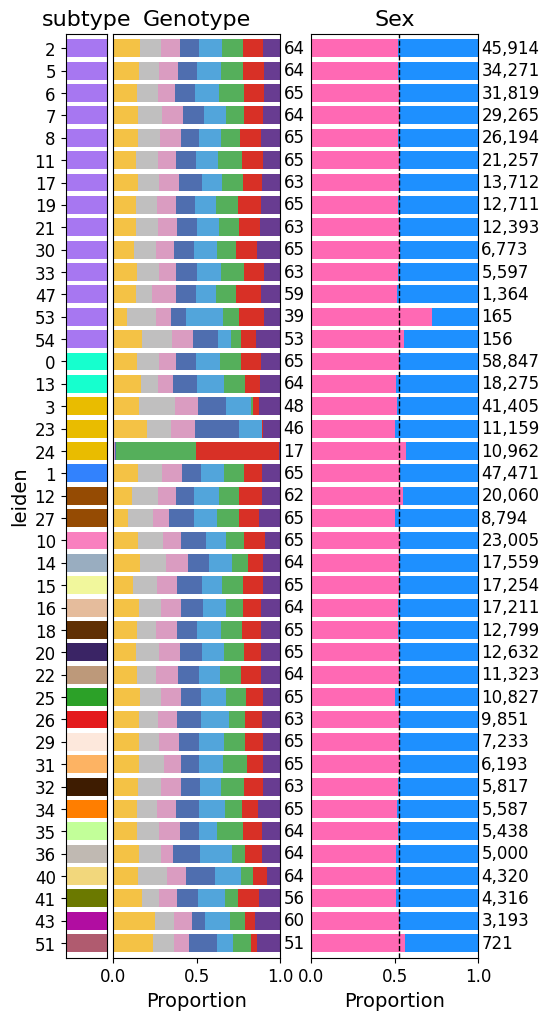

In [117]:
tissue = 'CortexHippocampus'

metadata = pd.read_csv(f'/share/crsp/lab/seyedam/share/igvf_pipeline/IGVF_analysis/cellbender_tissues/obs_tables/{tissue}_annotated_metadata.csv')
metadata = metadata[metadata['subtype'] != 'low quality']

metadata['Genotype'] = pd.Categorical(
    metadata['Genotype'],
    categories=genotype_order,
    ordered=True
)

# === Define palettes ===

# Celltype colors
all_celltypes = metadata['subtype'].unique()
default_palette = sc.pl.palettes.default_102
remaining_celltypes = [ct for ct in all_celltypes if ct not in custom_colors]
remaining_colors = default_palette[:len(remaining_celltypes)]
remaining_dict = dict(zip(remaining_celltypes, remaining_colors))
celltype_palette = {**custom_colors, **remaining_dict}

# Sex & genotype palettes
sex_palette = {'Male': 'dodgerblue', 'Female': 'hotpink'}
genotype_palette = dict(zip(metadata['Genotype'].unique(), sns.color_palette("tab20", n_colors=10)))

# === Cluster ordering by subtype then size ===

df = metadata[['leiden', 'subtype']]
celltype_sizes = df['subtype'].value_counts()
cluster_sizes = df['leiden'].value_counts()
cluster_to_celltype = df.set_index('leiden')['subtype'].to_dict()

from collections import defaultdict
celltype_to_clusters = defaultdict(list)
for cluster, celltype in cluster_to_celltype.items():
    celltype_to_clusters[celltype].append(cluster)

ordered_clusters = []
for celltype in celltype_sizes.index:
    clusters = celltype_to_clusters[celltype]
    clusters_sorted = sorted(clusters, key=lambda c: -cluster_sizes[c])
    ordered_clusters.extend(clusters_sorted)
ordered_clusters = ordered_clusters[::-1]

# === Filter for meaningful mouse contribution by genotype ===

cell_info = metadata[['leiden', 'lab_sample_id', 'Genotype']].copy()

# Cluster-level totals
cluster_totals = cell_info['leiden'].value_counts().rename("cluster_total").reset_index()
cluster_totals.columns = ['leiden', 'cluster_total']

# Genotype totals per cluster
geno_cluster_totals = (
    cell_info.groupby(['leiden', 'Genotype']).size().rename('geno_total').reset_index()
)
geno_cluster_totals = geno_cluster_totals.merge(cluster_totals, on='leiden')
geno_cluster_totals['geno_fraction'] = geno_cluster_totals['geno_total'] / geno_cluster_totals['cluster_total']
significant_genotypes = geno_cluster_totals[geno_cluster_totals['geno_fraction'] >= 0.05]

# Mouse contributions
mouse_counts = (
    cell_info.groupby(['leiden', 'lab_sample_id']).size().rename('mouse_count').reset_index()
)
lab_sample_to_geno = cell_info.drop_duplicates('lab_sample_id').set_index('lab_sample_id')['Genotype']
mouse_counts['Genotype'] = mouse_counts['lab_sample_id'].map(lab_sample_to_geno)

# Merge and compute proportion
merged = pd.merge(
    mouse_counts,
    significant_genotypes[['leiden', 'Genotype', 'geno_total']],
    on=['leiden', 'Genotype'],
    how='inner'
)
merged['proportion'] = merged['mouse_count'] / merged['geno_total']
meaningful = merged[merged['proportion'] >= 0.05]

# Final counts
n_mice_per_cluster = (
    meaningful.groupby('leiden')['lab_sample_id']
    .nunique().reindex(ordered_clusters).fillna(0).astype(int)
)
n_nuclei_per_cluster = metadata['leiden'].value_counts().reindex(ordered_clusters)

# === Plotting ===

fig = plt.figure(figsize=(5, 12))
gs = gridspec.GridSpec(1, 3, width_ratios=[0.5, 2, 2], wspace=0.05)
axs = [fig.add_subplot(gs[i]) for i in range(3)]

# Panel 1: Celltype identity
stacked_barplot_proportions(
    metadata,
    cluster_key="leiden",
    var_key="subtype",
    color_dict=celltype_palette,
    cluster_order=ordered_clusters,
    annotations=False,
    fsize=None,
    ax=axs[0]
)

# Panel 2: Genotype proportions with # mice
stacked_barplot_proportions(
    metadata,
    cluster_key="leiden",
    var_key="Genotype",
    color_dict=geno_palette,
    cluster_order=ordered_clusters,
    annotations=True,
    annotate_vals=n_mice_per_cluster,
    fsize=None,
    ax=axs[1]
)

# Panel 3: Sex proportions with # nuclei
stacked_barplot_proportions(
    metadata,
    cluster_key="leiden",
    var_key="Sex",
    color_dict=sex_palette,
    cluster_order=ordered_clusters,
    annotations=True,
    annotate_vals=n_nuclei_per_cluster,
    fsize=None,
    ax=axs[2]
)

# === Final formatting ===

axs[0].set_xlabel("")
axs[2].set_position([
    axs[2].get_position().x0 + 0.05,
    axs[2].get_position().y0,
    axs[2].get_position().width,
    axs[2].get_position().height
])
axs[0].tick_params(axis='x', bottom=False, labelbottom=False)
axs[1].tick_params(axis='y', length=0)
axs[2].tick_params(axis='y', length=0)
axs[1].set_yticklabels([])
axs[2].set_yticklabels([])
axs[1].set_ylabel("")
axs[2].set_ylabel("")

for ax in axs:
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

female_fraction = (metadata['Sex'] == 'Female').mean()
axs[2].axvline(female_fraction, linestyle='--', color='black', linewidth=1)

plt.tight_layout()
plt.savefig(f"../new_supp/{tissue}_cluster_annotations_barplots.png", dpi=300, bbox_inches='tight')
plt.show()


## Legends

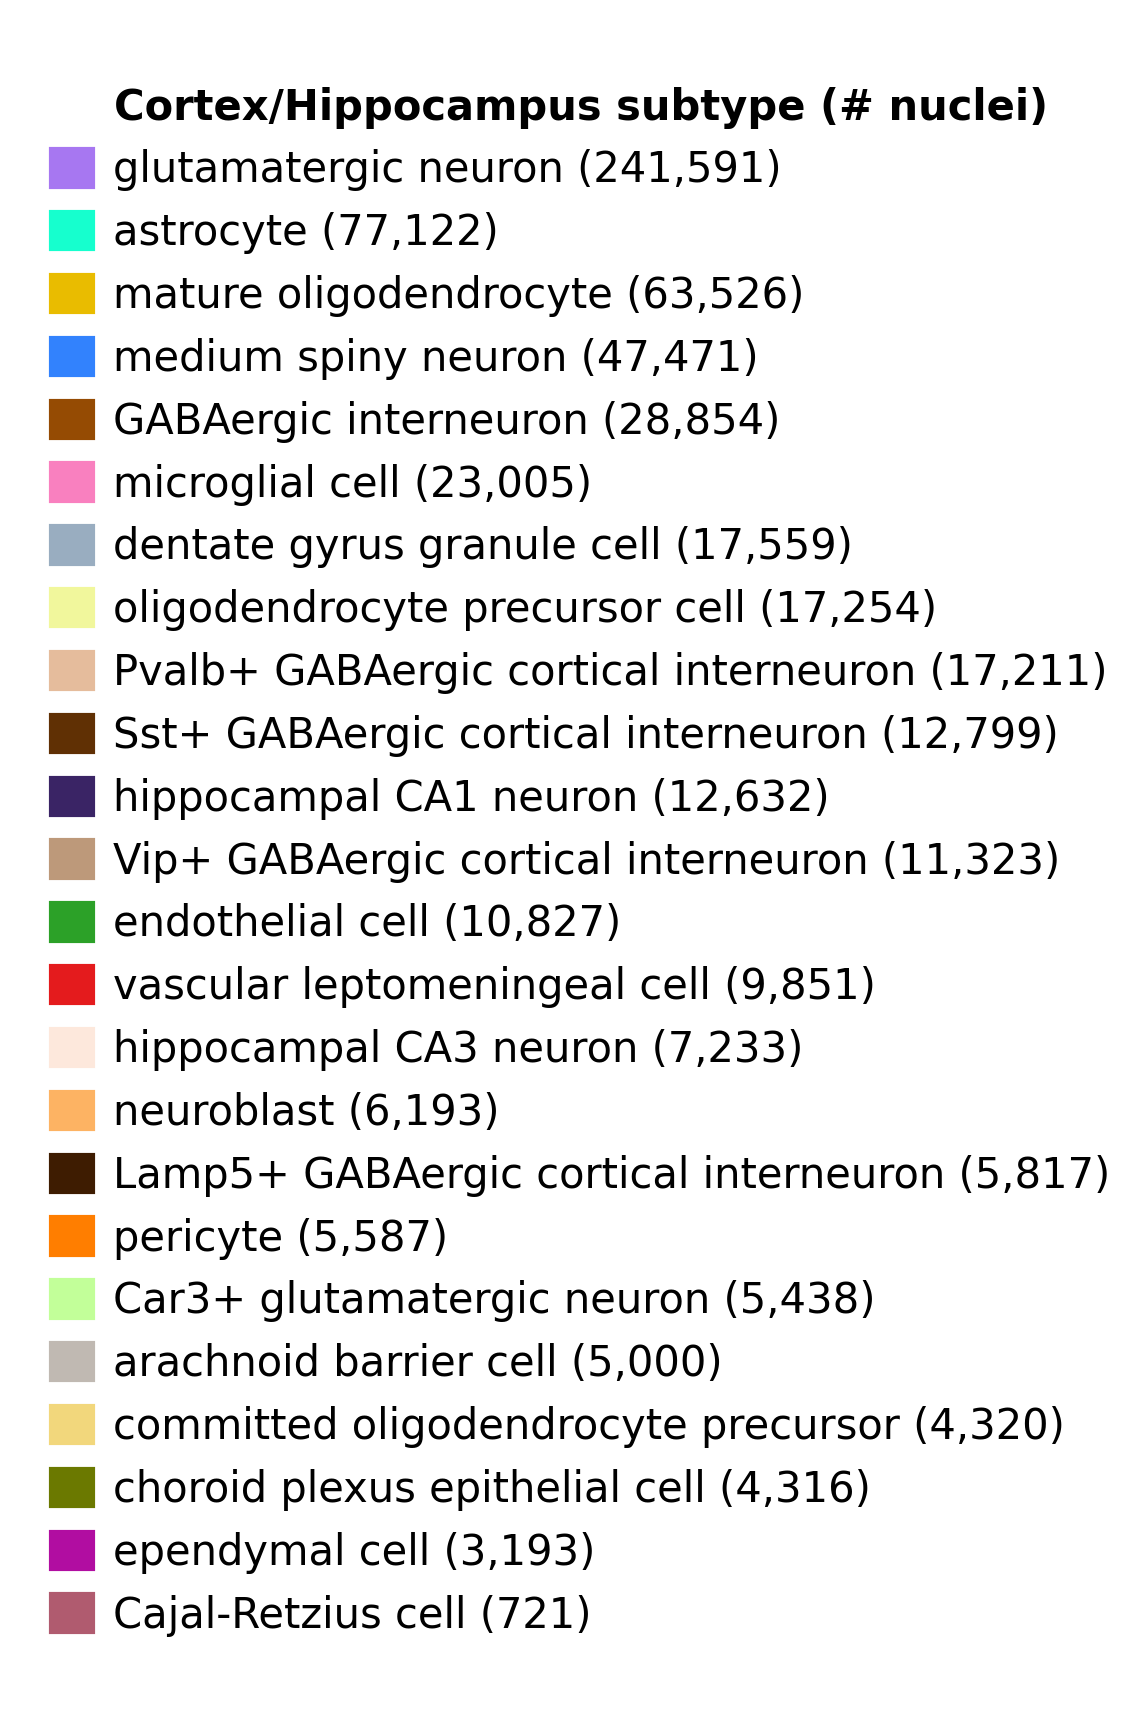

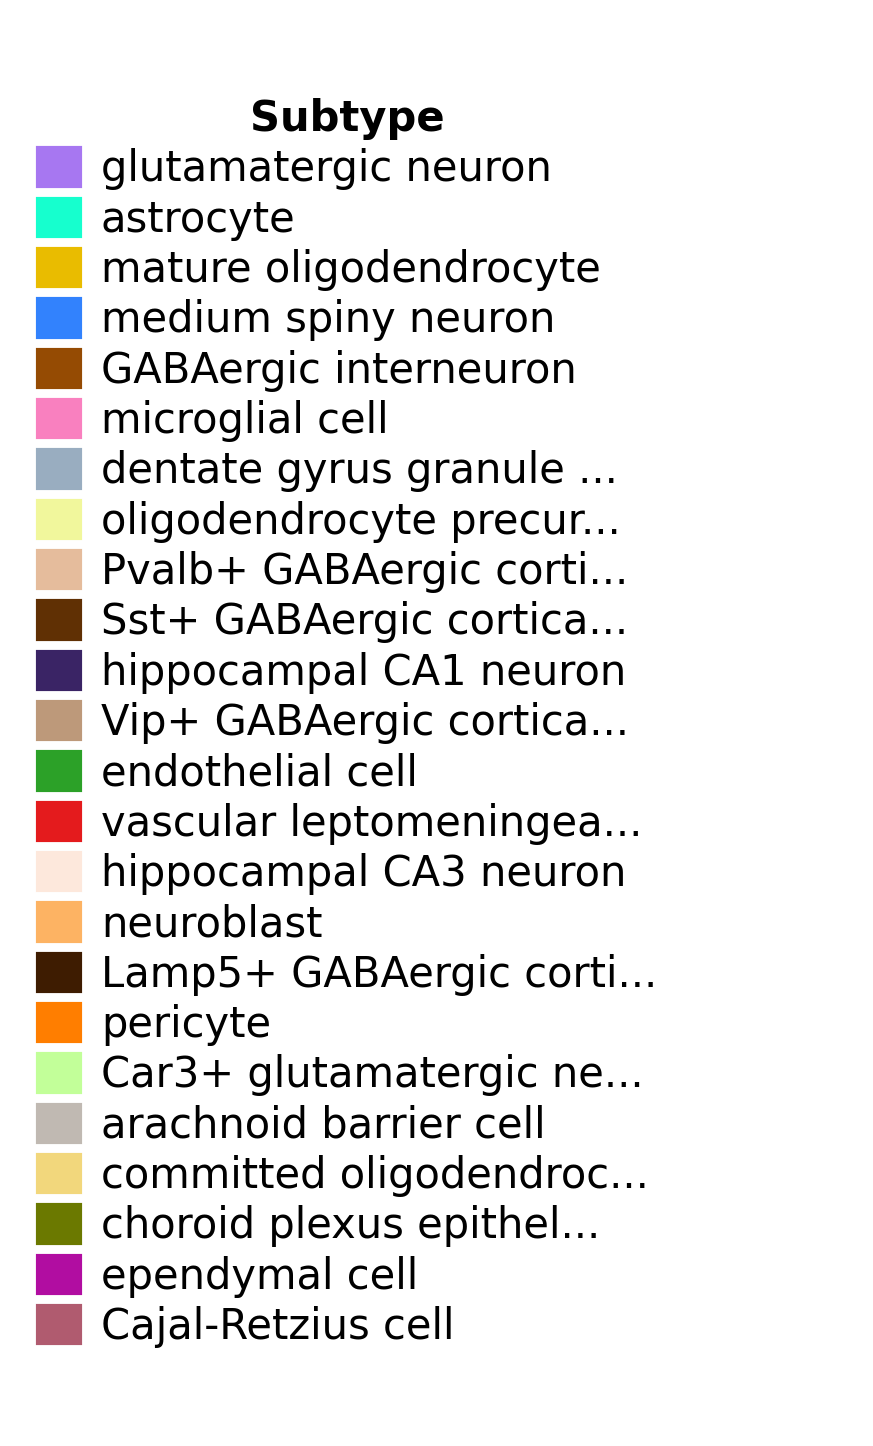

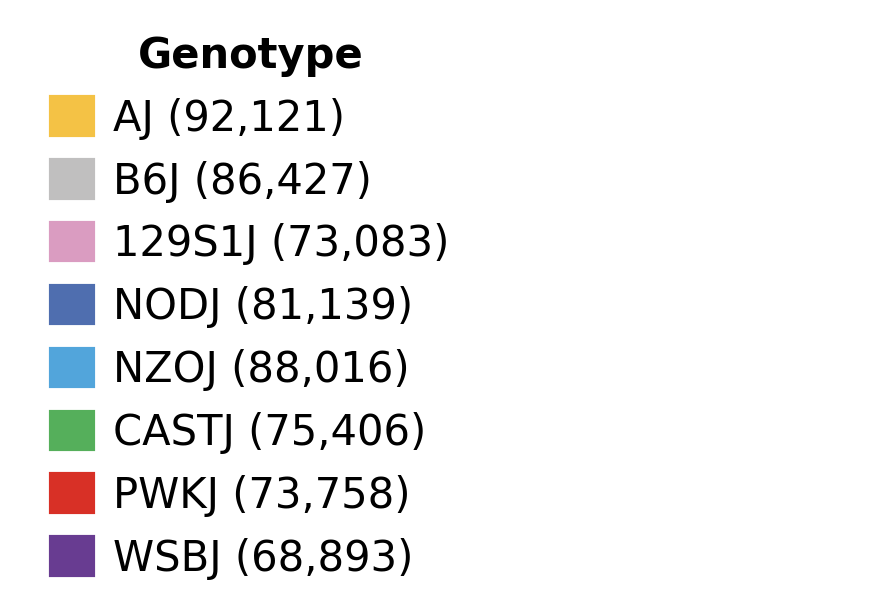

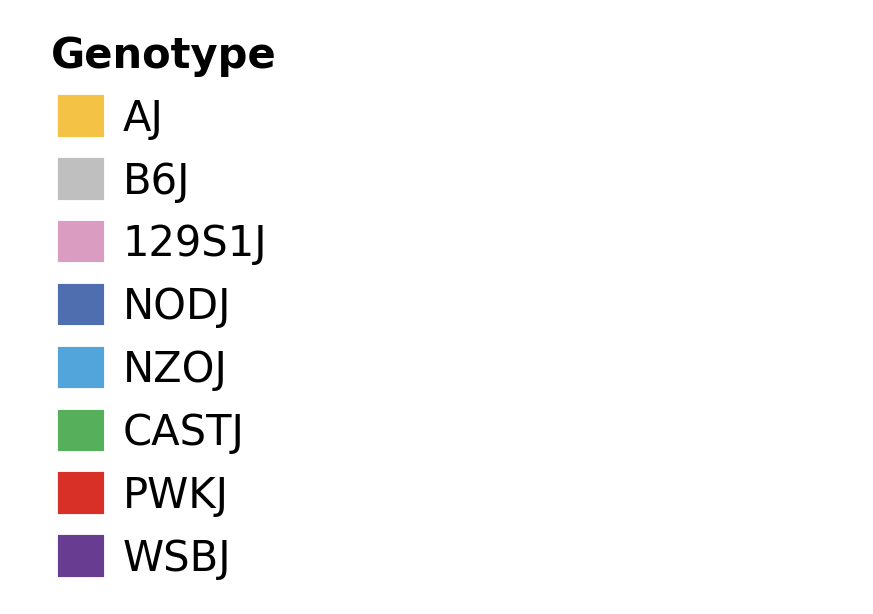

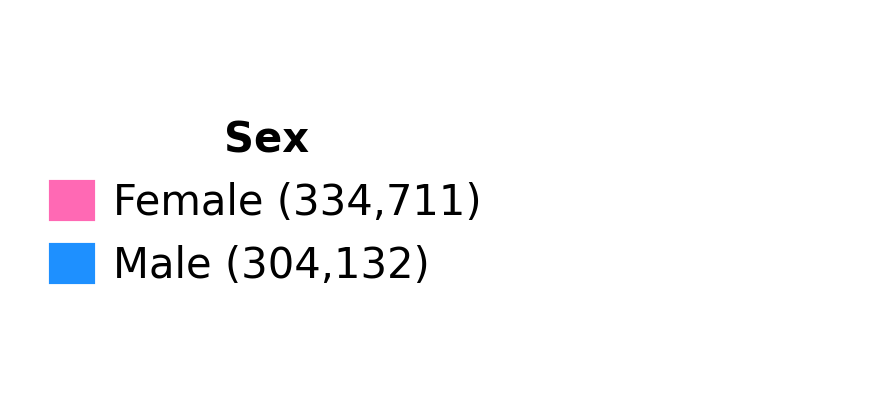

In [118]:
ordered_celltypes = metadata.set_index('leiden').loc[ordered_clusters]['subtype'].values
ordered_celltypes = list(dict.fromkeys(ordered_celltypes))  # remove duplicates, keep order
ordered_celltypes = ordered_celltypes[::-1]  # reverse it

from collections import Counter
celltype_counts = metadata['subtype'].value_counts()

tissue_label_map = {
    "CortexHippocampus": "Cortex/Hippocampus",
    "DiencephalonPituitary": "Diencephalon/Pituitary",
    "GonadsMale": "Male gonads",
    "GonadsFemale": "Female gonads"
}

# Fallback to original if not in map
pretty_tissue = tissue_label_map.get(tissue, tissue)


label = f"{pretty_tissue} subtype (# nuclei)"
fname = f"{tissue}_celltype_legend"

create_standalone_legend(
    color_dict=celltype_palette,
    label=label,
    order=ordered_celltypes,
    counts=celltype_counts,
    ncol=1,
    fname = fname
)


metadata["subtype_abbrev"] = metadata["subtype"].apply(abbreviate)

ordered_celltype_abbrev = [abbreviate(ct) for ct in ordered_celltypes]

celltype_counts = metadata['subtype_abbrev'].value_counts()

label = f"Subtype"
fname = f"{tissue}_simple_celltype_legend"

celltype_palette_abbrev = {
    abbreviate(ct): color for ct, color in celltype_palette.items()
    if abbreviate(ct) in set(ordered_celltype_abbrev)
}

create_standalone_legend_squish(
    color_dict=celltype_palette_abbrev,
    label=label,
    order=ordered_celltype_abbrev,
    ncol=1,
    fname = fname
)


geno_counts = metadata['Genotype'].value_counts()

label = f"Genotype"
fname = f"{tissue}_geno_legend"

create_standalone_legend(
    color_dict=geno_palette,
    label=label,
    order=genotype_order,
    counts=geno_counts,
    ncol=1,
    fname = fname
)


geno_counts = metadata['Genotype'].value_counts()

label = f"Genotype"
fname = f"{tissue}_simple_geno_legend"

create_standalone_legend(
    color_dict=geno_palette,
    label=label,
    order=genotype_order,
    ncol=1,
    fname = fname
)


sex_counts = metadata['Sex'].value_counts()

label = f"Sex"
fname = f"{tissue}_sex_legend"

create_standalone_legend(
    color_dict=sex_palette,
    label=label,
    order=['Female', 'Male'],
    counts=sex_counts,
    ncol=1,
    fname = fname
)

## Proportion of genotypes across celltypes

/tmp/ipykernel_1504450/257901544.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = obs.groupby([cluster_key, var_key]).size().unstack(fill_value=0)


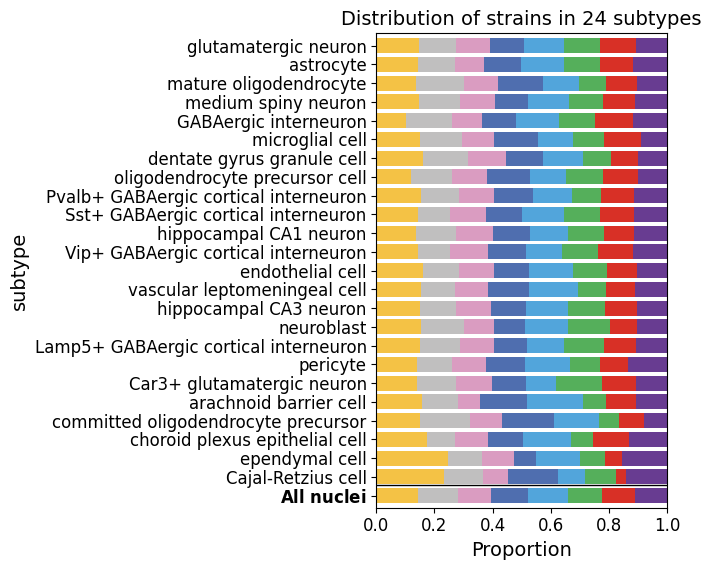

In [119]:
# Copy metadata and append summary row
plot_df = metadata.copy()

# Create a dummy celltype entry for all cells combined
summary_row = plot_df.copy()
summary_row['subtype'] = 'All nuclei'

# Append to the bottom of the dataframe
plot_df = pd.concat([plot_df, summary_row], axis=0)

# Add 'All cells' to the cluster order list (at the end)
ordered_celltypes2 =  ['All nuclei'] + ordered_celltypes[::-1] 

# Now plot!
fig = plt.figure(figsize=(7, 5.8))  # slightly taller
gs = gridspec.GridSpec(1, 1)
ax = fig.add_subplot(gs[0])

stacked_barplot_proportions(
    plot_df,
    cluster_key="subtype",
    var_key="Genotype",
    color_dict=geno_palette,
    cluster_order=ordered_celltypes2,
    annotations=False,
    fsize=None,
    ax=ax
)

ax.axhline(y=0.54, color='black', linestyle='-', linewidth=1)

# Get current y-axis tick labels
yticklabels = [label.get_text() for label in ax.get_yticklabels()]

# Rebuild the list with "All cells" in bold
new_labels = []
for label in yticklabels:
    if label == 'All nuclei':
        new_labels.append(r"$\bf{All\ nuclei}$")  # bold with math text
    else:
        new_labels.append(label)

# Apply new labels
ax.set_yticklabels(new_labels)

n_celltypes = len(ordered_celltypes)
ax.set_title(f"Distribution of strains in {n_celltypes} subtypes", fontsize=14)


plt.tight_layout()

plt.savefig(f"../new_supp/{tissue}_genotype_distribution_across_celltypes_bar.png", dpi=300, bbox_inches='tight', transparent = True)

plt.show()


## Proportion of celltypes across genotypes

/tmp/ipykernel_1504450/257901544.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = obs.groupby([cluster_key, var_key]).size().unstack(fill_value=0)


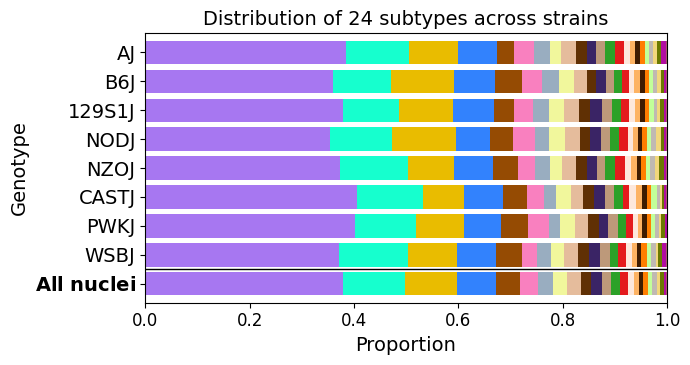

In [120]:
# Copy metadata and append summary row
plot_df = metadata.copy()

# Create a dummy genotype entry for all cells combined
summary_row = plot_df.copy()
summary_row['Genotype'] = 'All nuclei'

# Append to the bottom of the dataframe
plot_df = pd.concat([plot_df, summary_row], axis=0)

# Subtype category setup
plot_df['subtype'] = pd.Categorical(
    plot_df['subtype'],
    categories=ordered_celltypes,
    ordered=True
)

# Genotype category setup, include 'All nuclei' at the end
genotype_order = ["AJ", "B6J", "129S1J", "NODJ", "NZOJ", "CASTJ", "PWKJ", "WSBJ"]
genotype_order_reversed = ['All nuclei'] + genotype_order[::-1]

plot_df['Genotype'] = pd.Categorical(
    plot_df['Genotype'],
    categories=genotype_order_reversed,
    ordered=True
)

# Plot
fig = plt.figure(figsize=(7, 3.75))  # slightly taller
gs = gridspec.GridSpec(1, 1)
ax = fig.add_subplot(gs[0])

stacked_barplot_proportions(
    plot_df,
    cluster_key="Genotype",
    var_key="subtype",
    color_dict=celltype_palette,
    cluster_order=genotype_order_reversed,
    annotations=False,
    fsize=None,
    ax=ax
)

ax.tick_params(axis='y', labelsize=14)

ax.axhline(y=0.52, color='black', linestyle='-', linewidth=1)

# Get current y-axis tick labels
yticklabels = [label.get_text() for label in ax.get_yticklabels()]

# Rebuild the list with "All cells" in bold
new_labels = []
for label in yticklabels:
    if label == 'All nuclei':
        new_labels.append(r"$\bf{All\ nuclei}$")  # bold with math text
    else:
        new_labels.append(label)

# Apply new labels
ax.set_yticklabels(new_labels)


ax.set_title(f"Distribution of {len(ordered_celltypes)} subtypes across strains", fontsize=14)

plt.tight_layout()
plt.savefig(f"../new_supp/{tissue}_celltype_distribution_across_genotypes_bar.png", dpi=300, bbox_inches='tight', transparent = True)
plt.show()


# Kidney

/tmp/ipykernel_1504450/1430840388.py:4: DtypeWarning: Columns (24,25) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata = pd.read_csv(f'/share/crsp/lab/seyedam/share/igvf_pipeline/IGVF_analysis/cellbender_tissues/obs_tables/{tissue}_annotated_metadata.csv')
/tmp/ipykernel_1504450/1430840388.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_info.groupby(['leiden_R', 'Genotype']).size().rename('geno_total').reset_index()
/tmp/ipykernel_1504450/257901544.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = obs.groupby([cluster_key, var_key]).size().unstack

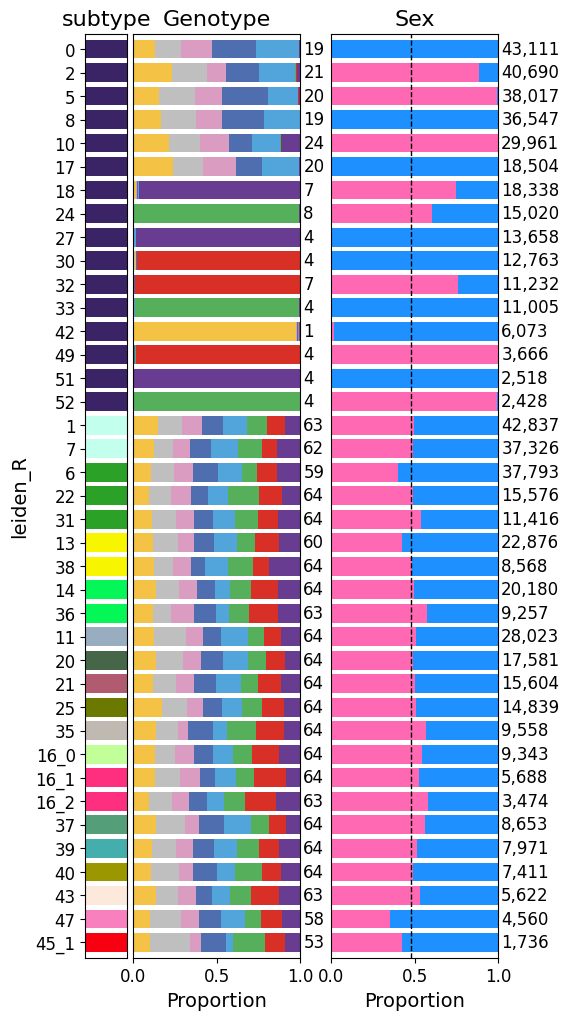

In [144]:
tissue = 'Kidney'
random.seed(42)

metadata = pd.read_csv(f'/share/crsp/lab/seyedam/share/igvf_pipeline/IGVF_analysis/cellbender_tissues/obs_tables/{tissue}_annotated_metadata.csv')
metadata = metadata[metadata['subtype'] != 'low quality']

metadata['Genotype'] = pd.Categorical(
    metadata['Genotype'],
    categories=genotype_order,
    ordered=True
)

# === Define palettes ===

# Celltype colors
all_celltypes = metadata['subtype'].unique()
default_palette = sc.pl.palettes.default_102

remaining_celltypes = [ct for ct in all_celltypes if ct not in custom_colors]
remaining_colors = default_palette[:len(remaining_celltypes)]
random.shuffle(remaining_colors)

remaining_dict = dict(zip(remaining_celltypes, remaining_colors))
celltype_palette = {**custom_colors, **remaining_dict}

# Sex & genotype palettes
sex_palette = {'Male': 'dodgerblue', 'Female': 'hotpink'}
genotype_palette = dict(zip(metadata['Genotype'].unique(), sns.color_palette("tab20", n_colors=10)))

# === Cluster ordering by subtype then size ===

df = metadata[['leiden_R', 'subtype']]
celltype_sizes = df['subtype'].value_counts()
cluster_sizes = df['leiden_R'].value_counts()
cluster_to_celltype = df.set_index('leiden_R')['subtype'].to_dict()

from collections import defaultdict
celltype_to_clusters = defaultdict(list)
for cluster, celltype in cluster_to_celltype.items():
    celltype_to_clusters[celltype].append(cluster)

ordered_clusters = []
for celltype in celltype_sizes.index:
    clusters = celltype_to_clusters[celltype]
    clusters_sorted = sorted(clusters, key=lambda c: -cluster_sizes[c])
    ordered_clusters.extend(clusters_sorted)
ordered_clusters = ordered_clusters[::-1]

# === Filter for meaningful mouse contribution by genotype ===

cell_info = metadata[['leiden_R', 'lab_sample_id', 'Genotype']].copy()

# Cluster-level totals
cluster_totals = cell_info['leiden_R'].value_counts().rename("cluster_total").reset_index()
cluster_totals.columns = ['leiden_R', 'cluster_total']

# Genotype totals per cluster
geno_cluster_totals = (
    cell_info.groupby(['leiden_R', 'Genotype']).size().rename('geno_total').reset_index()
)
geno_cluster_totals = geno_cluster_totals.merge(cluster_totals, on='leiden_R')
geno_cluster_totals['geno_fraction'] = geno_cluster_totals['geno_total'] / geno_cluster_totals['cluster_total']
significant_genotypes = geno_cluster_totals[geno_cluster_totals['geno_fraction'] >= 0.05]

# Mouse contributions
mouse_counts = (
    cell_info.groupby(['leiden_R', 'lab_sample_id']).size().rename('mouse_count').reset_index()
)
lab_sample_to_geno = cell_info.drop_duplicates('lab_sample_id').set_index('lab_sample_id')['Genotype']
mouse_counts['Genotype'] = mouse_counts['lab_sample_id'].map(lab_sample_to_geno)

# Merge and compute proportion
merged = pd.merge(
    mouse_counts,
    significant_genotypes[['leiden_R', 'Genotype', 'geno_total']],
    on=['leiden_R', 'Genotype'],
    how='inner'
)
merged['proportion'] = merged['mouse_count'] / merged['geno_total']
meaningful = merged[merged['proportion'] >= 0.05]

# Final counts
n_mice_per_cluster = (
    meaningful.groupby('leiden_R')['lab_sample_id']
    .nunique().reindex(ordered_clusters).fillna(0).astype(int)
)
n_nuclei_per_cluster = metadata['leiden_R'].value_counts().reindex(ordered_clusters)

# === Plotting ===

fig = plt.figure(figsize=(5, 12))
gs = gridspec.GridSpec(1, 3, width_ratios=[0.5, 2, 2], wspace=0.05)
axs = [fig.add_subplot(gs[i]) for i in range(3)]

# Panel 1: Celltype identity
stacked_barplot_proportions(
    metadata,
    cluster_key="leiden_R",
    var_key="subtype",
    color_dict=celltype_palette,
    cluster_order=ordered_clusters,
    annotations=False,
    fsize=None,
    ax=axs[0]
)

# Panel 2: Genotype proportions with # mice
stacked_barplot_proportions(
    metadata,
    cluster_key="leiden_R",
    var_key="Genotype",
    color_dict=geno_palette,
    cluster_order=ordered_clusters,
    annotations=True,
    annotate_vals=n_mice_per_cluster,
    fsize=None,
    ax=axs[1]
)

# Panel 3: Sex proportions with # nuclei
stacked_barplot_proportions(
    metadata,
    cluster_key="leiden_R",
    var_key="Sex",
    color_dict=sex_palette,
    cluster_order=ordered_clusters,
    annotations=True,
    annotate_vals=n_nuclei_per_cluster,
    fsize=None,
    ax=axs[2]
)

# === Final formatting ===

axs[0].set_xlabel("")
axs[2].set_position([
    axs[2].get_position().x0 + 0.05,
    axs[2].get_position().y0,
    axs[2].get_position().width,
    axs[2].get_position().height
])
axs[0].tick_params(axis='x', bottom=False, labelbottom=False)
axs[1].tick_params(axis='y', length=0)
axs[2].tick_params(axis='y', length=0)
axs[1].set_yticklabels([])
axs[2].set_yticklabels([])
axs[1].set_ylabel("")
axs[2].set_ylabel("")

for ax in axs:
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

female_fraction = (metadata['Sex'] == 'Female').mean()
axs[2].axvline(female_fraction, linestyle='--', color='black', linewidth=1)

plt.tight_layout()
plt.savefig(f"../new_supp/{tissue}_cluster_annotations_barplots.png", dpi=300, bbox_inches='tight', transparent = True)
plt.show()


In [145]:
metadata.shape

(649423, 57)

## Legends

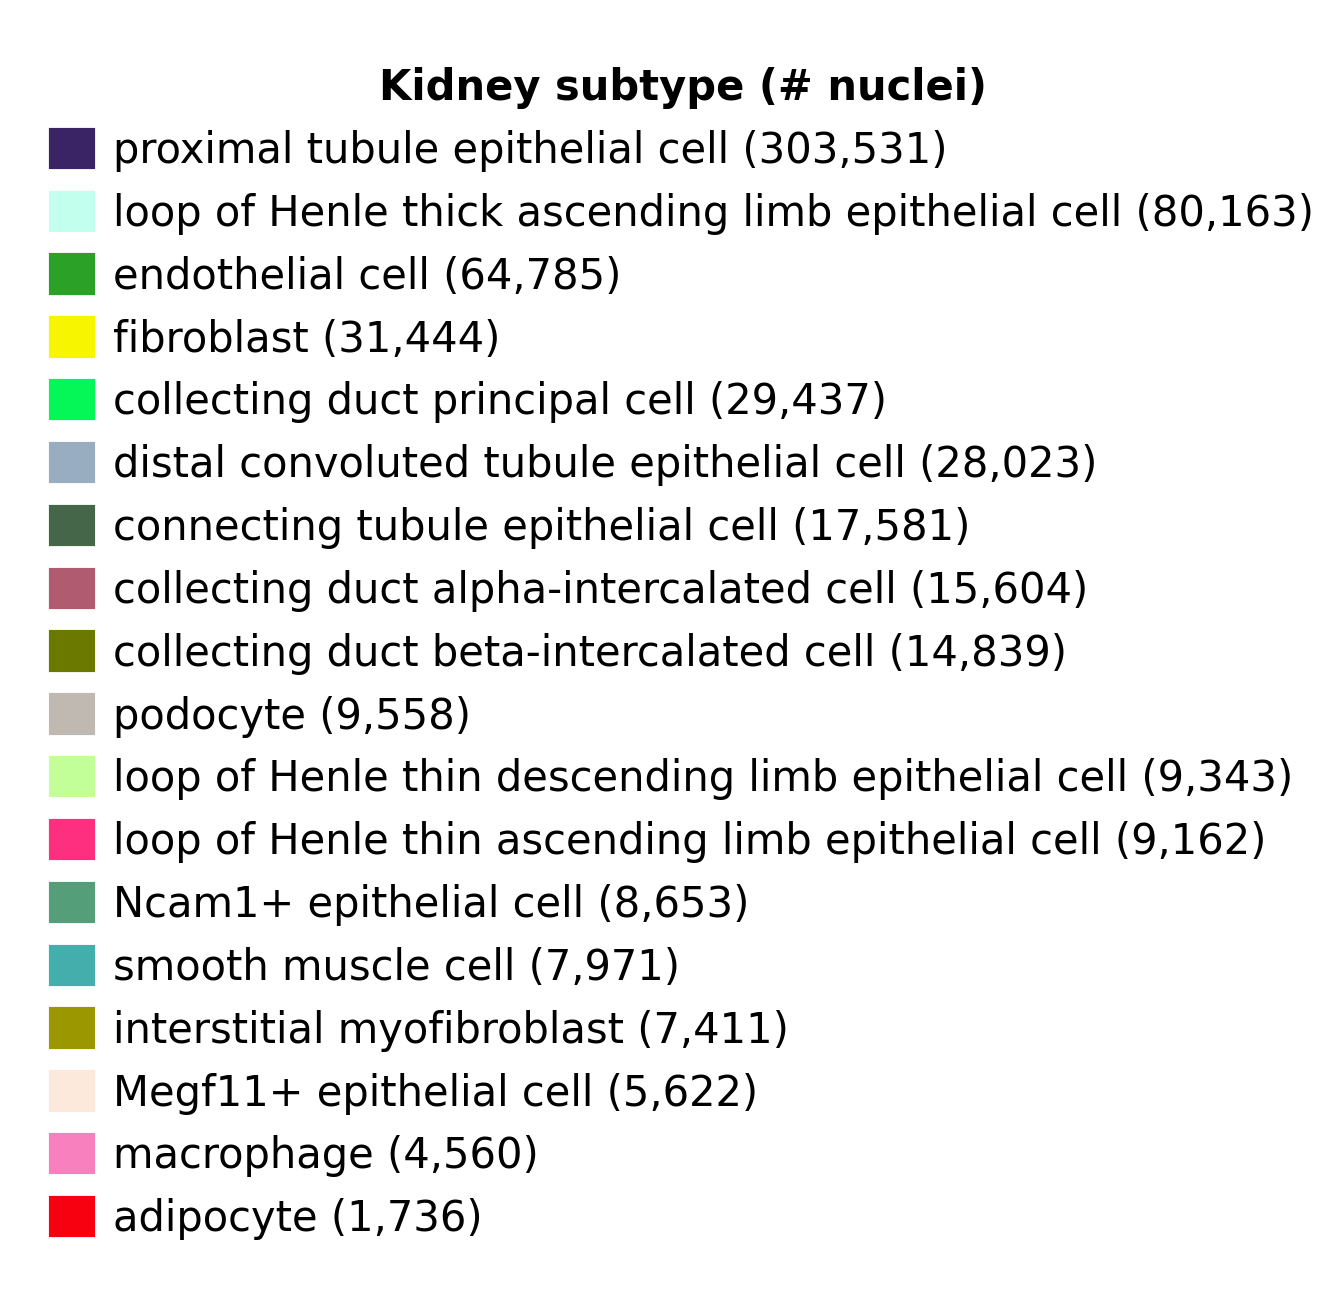

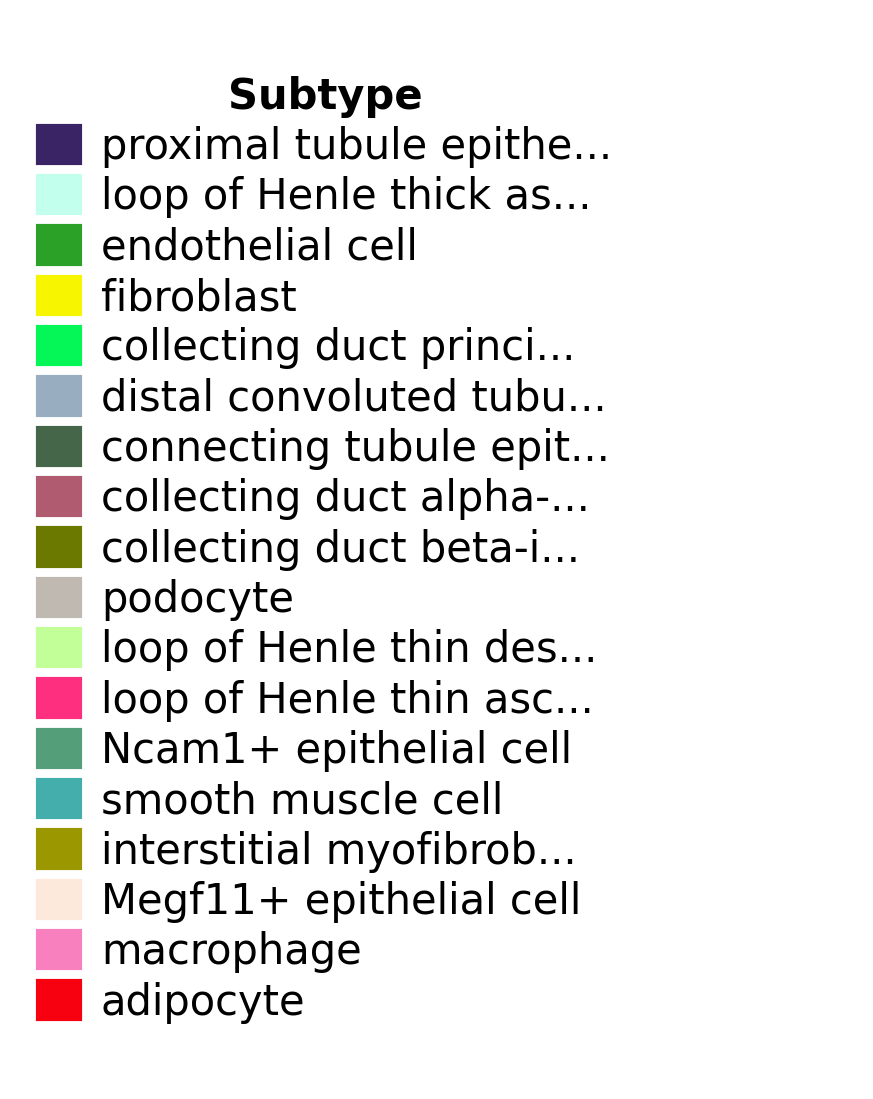

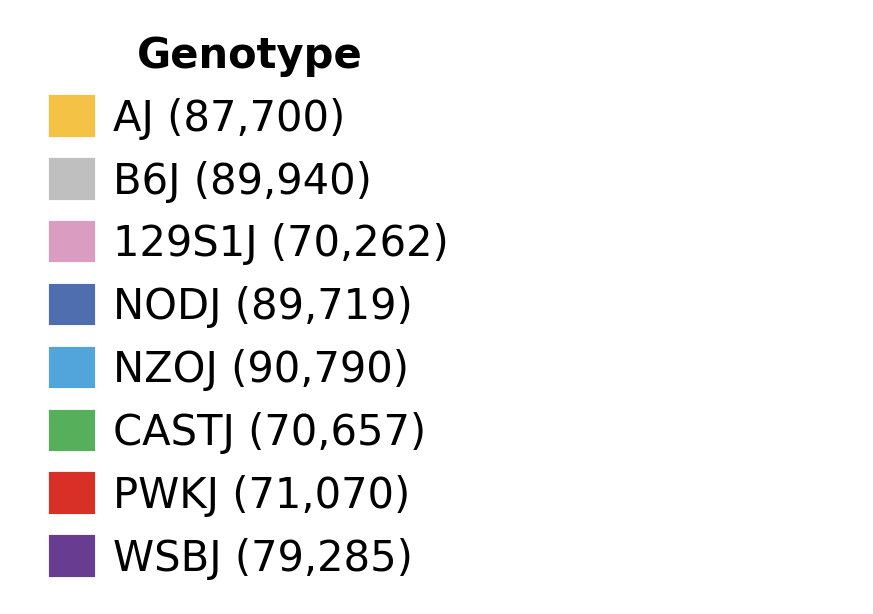

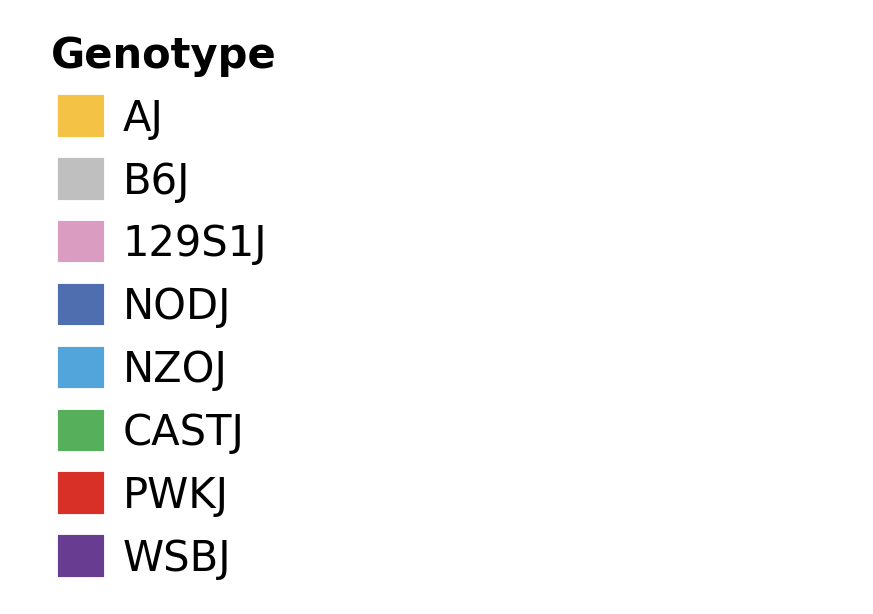

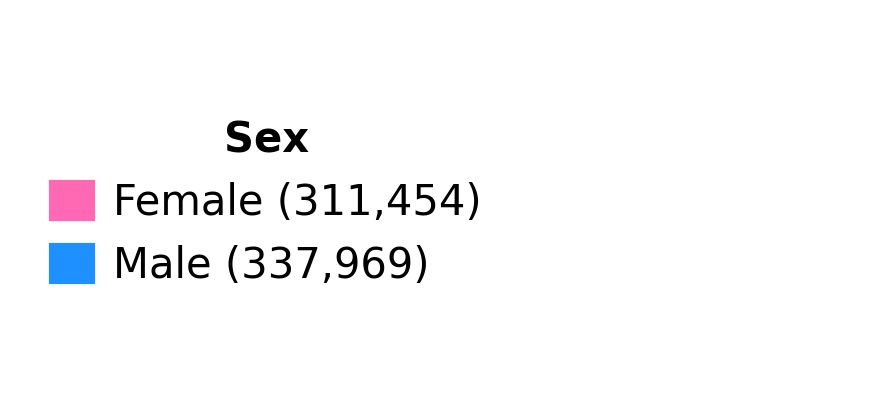

In [146]:
ordered_celltypes = metadata.set_index('leiden_R').loc[ordered_clusters]['subtype'].values
ordered_celltypes = list(dict.fromkeys(ordered_celltypes))  # remove duplicates, keep order
ordered_celltypes = ordered_celltypes[::-1]  # reverse it

from collections import Counter
celltype_counts = metadata['subtype'].value_counts()

tissue_label_map = {
    "CortexHippocampus": "Cortex/Hippocampus",
    "DiencephalonPituitary": "Diencephalon/Pituitary",
    "GonadsMale": "Male gonads",
    "GonadsFemale": "Female gonads"
}

# Fallback to original if not in map
pretty_tissue = tissue_label_map.get(tissue, tissue)


label = f"{pretty_tissue} subtype (# nuclei)"
fname = f"{tissue}_celltype_legend"

create_standalone_legend(
    color_dict=celltype_palette,
    label=label,
    order=ordered_celltypes,
    counts=celltype_counts,
    ncol=1,
    fname = fname
)


metadata["subtype_abbrev"] = metadata["subtype"].apply(abbreviate)

ordered_celltype_abbrev = [abbreviate(ct) for ct in ordered_celltypes]

celltype_counts = metadata['subtype_abbrev'].value_counts()

label = f"Subtype"
fname = f"{tissue}_simple_celltype_legend"

celltype_palette_abbrev = {
    abbreviate(ct): color for ct, color in celltype_palette.items()
    if abbreviate(ct) in set(ordered_celltype_abbrev)
}

create_standalone_legend_squish(
    color_dict=celltype_palette_abbrev,
    label=label,
    order=ordered_celltype_abbrev,
    ncol=1,
    fname = fname
)


geno_counts = metadata['Genotype'].value_counts()

label = f"Genotype"
fname = f"{tissue}_geno_legend"

create_standalone_legend(
    color_dict=geno_palette,
    label=label,
    order=genotype_order,
    counts=geno_counts,
    ncol=1,
    fname = fname
)


geno_counts = metadata['Genotype'].value_counts()

label = f"Genotype"
fname = f"{tissue}_simple_geno_legend"

create_standalone_legend(
    color_dict=geno_palette,
    label=label,
    order=genotype_order,
    ncol=1,
    fname = fname
)


sex_counts = metadata['Sex'].value_counts()

label = f"Sex"
fname = f"{tissue}_sex_legend"

create_standalone_legend(
    color_dict=sex_palette,
    label=label,
    order=['Female', 'Male'],
    counts=sex_counts,
    ncol=1,
    fname = fname
)

## Proportion of genotypes across celltypes

/tmp/ipykernel_1504450/257901544.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = obs.groupby([cluster_key, var_key]).size().unstack(fill_value=0)


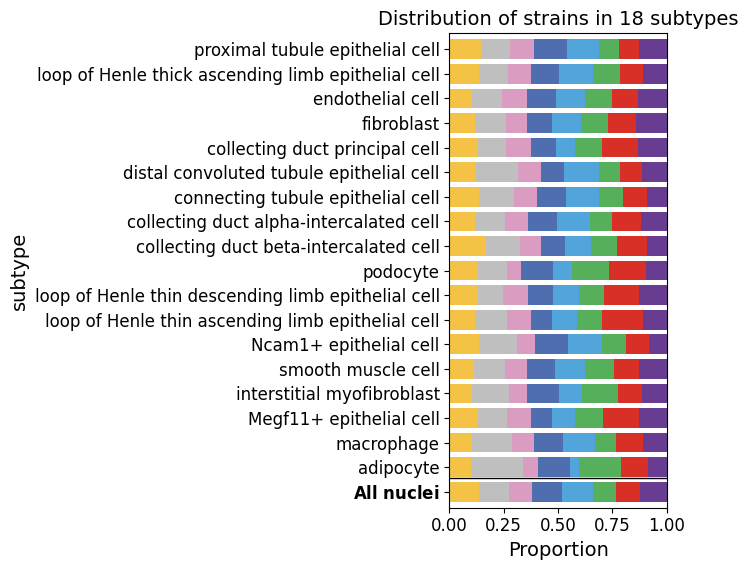

In [147]:
# Copy metadata and append summary row
plot_df = metadata.copy()

# Create a dummy celltype entry for all cells combined
summary_row = plot_df.copy()
summary_row['subtype'] = 'All nuclei'

# Append to the bottom of the dataframe
plot_df = pd.concat([plot_df, summary_row], axis=0)

# Add 'All cells' to the cluster order list (at the end)
ordered_celltypes2 =  ['All nuclei'] + ordered_celltypes[::-1] 

# Now plot!
fig = plt.figure(figsize=(7, 5.8))  # slightly taller
gs = gridspec.GridSpec(1, 1)
ax = fig.add_subplot(gs[0])

stacked_barplot_proportions(
    plot_df,
    cluster_key="subtype",
    var_key="Genotype",
    color_dict=geno_palette,
    cluster_order=ordered_celltypes2,
    annotations=False,
    fsize=None,
    ax=ax
)

ax.axhline(y=0.54, color='black', linestyle='-', linewidth=1)

# Get current y-axis tick labels
yticklabels = [label.get_text() for label in ax.get_yticklabels()]

# Rebuild the list with "All cells" in bold
new_labels = []
for label in yticklabels:
    if label == 'All nuclei':
        new_labels.append(r"$\bf{All\ nuclei}$")  # bold with math text
    else:
        new_labels.append(label)

# Apply new labels
ax.set_yticklabels(new_labels)

n_celltypes = len(ordered_celltypes)
ax.set_title(f"Distribution of strains in {n_celltypes} subtypes", fontsize=14)


plt.tight_layout()

plt.savefig(f"../new_supp/{tissue}_genotype_distribution_across_celltypes_bar.png", dpi=300, bbox_inches='tight', transparent = True)

plt.show()


## Proportion of celltypes across genotypes

/tmp/ipykernel_1504450/257901544.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = obs.groupby([cluster_key, var_key]).size().unstack(fill_value=0)


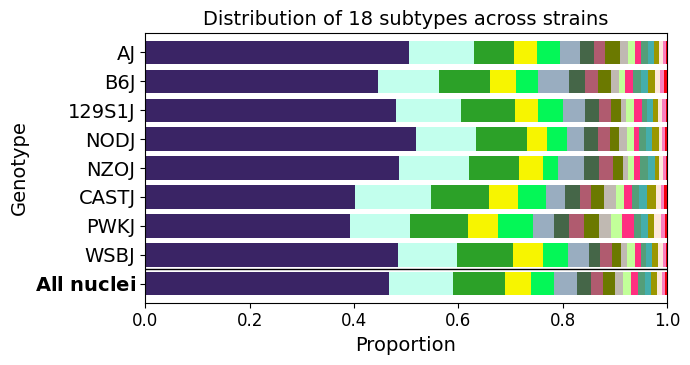

In [148]:
# Copy metadata and append summary row
plot_df = metadata.copy()

# Create a dummy genotype entry for all cells combined
summary_row = plot_df.copy()
summary_row['Genotype'] = 'All nuclei'

# Append to the bottom of the dataframe
plot_df = pd.concat([plot_df, summary_row], axis=0)

# Subtype category setup
plot_df['subtype'] = pd.Categorical(
    plot_df['subtype'],
    categories=ordered_celltypes,
    ordered=True
)

# Genotype category setup, include 'All nuclei' at the end
genotype_order = ["AJ", "B6J", "129S1J", "NODJ", "NZOJ", "CASTJ", "PWKJ", "WSBJ"]
genotype_order_reversed = ['All nuclei'] + genotype_order[::-1]

plot_df['Genotype'] = pd.Categorical(
    plot_df['Genotype'],
    categories=genotype_order_reversed,
    ordered=True
)

# Plot
fig = plt.figure(figsize=(7, 3.75))  # slightly taller
gs = gridspec.GridSpec(1, 1)
ax = fig.add_subplot(gs[0])

stacked_barplot_proportions(
    plot_df,
    cluster_key="Genotype",
    var_key="subtype",
    color_dict=celltype_palette,
    cluster_order=genotype_order_reversed,
    annotations=False,
    fsize=None,
    ax=ax
)

ax.tick_params(axis='y', labelsize=14)

ax.axhline(y=0.52, color='black', linestyle='-', linewidth=1)

# Get current y-axis tick labels
yticklabels = [label.get_text() for label in ax.get_yticklabels()]

# Rebuild the list with "All cells" in bold
new_labels = []
for label in yticklabels:
    if label == 'All nuclei':
        new_labels.append(r"$\bf{All\ nuclei}$")  # bold with math text
    else:
        new_labels.append(label)

# Apply new labels
ax.set_yticklabels(new_labels)


ax.set_title(f"Distribution of {len(ordered_celltypes)} subtypes across strains", fontsize=14)

plt.tight_layout()
plt.savefig(f"../new_supp/{tissue}_celltype_distribution_across_genotypes_bar.png", dpi=300, bbox_inches='tight', transparent = True)
plt.show()


# Heart

/tmp/ipykernel_1504450/160266727.py:4: DtypeWarning: Columns (27,33) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata = pd.read_csv(f'/share/crsp/lab/seyedam/share/igvf_pipeline/IGVF_analysis/cellbender_tissues/obs_tables/{tissue}_annotated_metadata.csv')
/tmp/ipykernel_1504450/160266727.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_info.groupby(['leiden', 'Genotype']).size().rename('geno_total').reset_index()
/tmp/ipykernel_1504450/257901544.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = obs.groupby([cluster_key, var_key]).size().unstack(fil

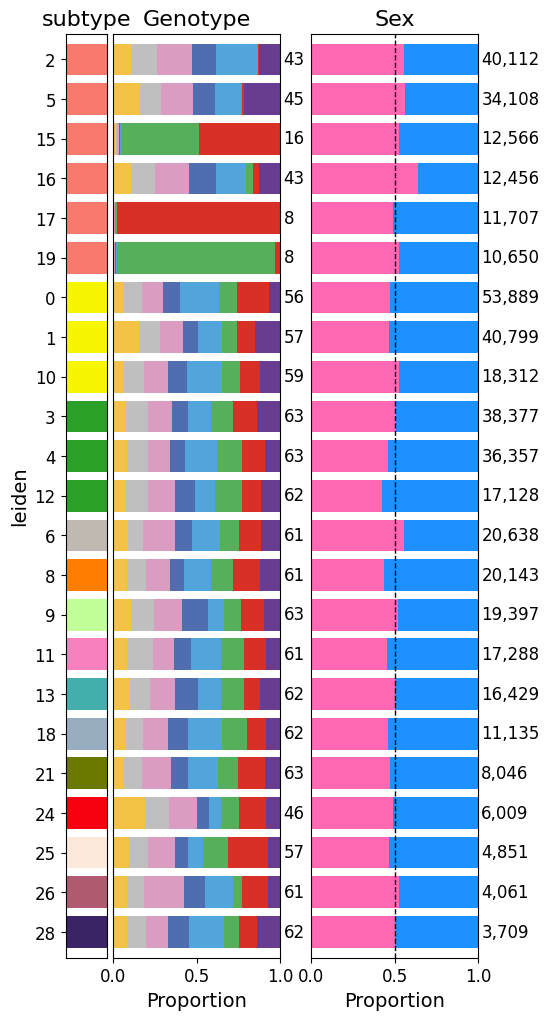

In [126]:
tissue = 'Heart'
random.seed(321) # 2

metadata = pd.read_csv(f'/share/crsp/lab/seyedam/share/igvf_pipeline/IGVF_analysis/cellbender_tissues/obs_tables/{tissue}_annotated_metadata.csv')
metadata = metadata[metadata['subtype'] != 'low quality']

metadata['Genotype'] = pd.Categorical(
    metadata['Genotype'],
    categories=genotype_order,
    ordered=True
)

# === Define palettes ===

# Celltype colors
all_celltypes = metadata['subtype'].unique()
default_palette = sc.pl.palettes.default_102

remaining_celltypes = [ct for ct in all_celltypes if ct not in custom_colors]
remaining_colors = default_palette[:len(remaining_celltypes)]
random.shuffle(remaining_colors)

remaining_dict = dict(zip(remaining_celltypes, remaining_colors))
celltype_palette = {**custom_colors, **remaining_dict}

# Sex & genotype palettes
sex_palette = {'Male': 'dodgerblue', 'Female': 'hotpink'}
genotype_palette = dict(zip(metadata['Genotype'].unique(), sns.color_palette("tab20", n_colors=10)))

# === Cluster ordering by subtype then size ===

df = metadata[['leiden', 'subtype']]
celltype_sizes = df['subtype'].value_counts()
cluster_sizes = df['leiden'].value_counts()
cluster_to_celltype = df.set_index('leiden')['subtype'].to_dict()

from collections import defaultdict
celltype_to_clusters = defaultdict(list)
for cluster, celltype in cluster_to_celltype.items():
    celltype_to_clusters[celltype].append(cluster)

ordered_clusters = []
for celltype in celltype_sizes.index:
    clusters = celltype_to_clusters[celltype]
    clusters_sorted = sorted(clusters, key=lambda c: -cluster_sizes[c])
    ordered_clusters.extend(clusters_sorted)
ordered_clusters = ordered_clusters[::-1]

# === Filter for meaningful mouse contribution by genotype ===

cell_info = metadata[['leiden', 'lab_sample_id', 'Genotype']].copy()

# Cluster-level totals
cluster_totals = cell_info['leiden'].value_counts().rename("cluster_total").reset_index()
cluster_totals.columns = ['leiden', 'cluster_total']

# Genotype totals per cluster
geno_cluster_totals = (
    cell_info.groupby(['leiden', 'Genotype']).size().rename('geno_total').reset_index()
)
geno_cluster_totals = geno_cluster_totals.merge(cluster_totals, on='leiden')
geno_cluster_totals['geno_fraction'] = geno_cluster_totals['geno_total'] / geno_cluster_totals['cluster_total']
significant_genotypes = geno_cluster_totals[geno_cluster_totals['geno_fraction'] >= 0.05]

# Mouse contributions
mouse_counts = (
    cell_info.groupby(['leiden', 'lab_sample_id']).size().rename('mouse_count').reset_index()
)
lab_sample_to_geno = cell_info.drop_duplicates('lab_sample_id').set_index('lab_sample_id')['Genotype']
mouse_counts['Genotype'] = mouse_counts['lab_sample_id'].map(lab_sample_to_geno)

# Merge and compute proportion
merged = pd.merge(
    mouse_counts,
    significant_genotypes[['leiden', 'Genotype', 'geno_total']],
    on=['leiden', 'Genotype'],
    how='inner'
)
merged['proportion'] = merged['mouse_count'] / merged['geno_total']
meaningful = merged[merged['proportion'] >= 0.05]

# Final counts
n_mice_per_cluster = (
    meaningful.groupby('leiden')['lab_sample_id']
    .nunique().reindex(ordered_clusters).fillna(0).astype(int)
)
n_nuclei_per_cluster = metadata['leiden'].value_counts().reindex(ordered_clusters)

# === Plotting ===

fig = plt.figure(figsize=(5, 12))
gs = gridspec.GridSpec(1, 3, width_ratios=[0.5, 2, 2], wspace=0.05)
axs = [fig.add_subplot(gs[i]) for i in range(3)]

# Panel 1: Celltype identity
stacked_barplot_proportions(
    metadata,
    cluster_key="leiden",
    var_key="subtype",
    color_dict=celltype_palette,
    cluster_order=ordered_clusters,
    annotations=False,
    fsize=None,
    ax=axs[0]
)

# Panel 2: Genotype proportions with # mice
stacked_barplot_proportions(
    metadata,
    cluster_key="leiden",
    var_key="Genotype",
    color_dict=geno_palette,
    cluster_order=ordered_clusters,
    annotations=True,
    annotate_vals=n_mice_per_cluster,
    fsize=None,
    ax=axs[1]
)

# Panel 3: Sex proportions with # nuclei
stacked_barplot_proportions(
    metadata,
    cluster_key="leiden",
    var_key="Sex",
    color_dict=sex_palette,
    cluster_order=ordered_clusters,
    annotations=True,
    annotate_vals=n_nuclei_per_cluster,
    fsize=None,
    ax=axs[2]
)

# === Final formatting ===

axs[0].set_xlabel("")
axs[2].set_position([
    axs[2].get_position().x0 + 0.05,
    axs[2].get_position().y0,
    axs[2].get_position().width,
    axs[2].get_position().height
])
axs[0].tick_params(axis='x', bottom=False, labelbottom=False)
axs[1].tick_params(axis='y', length=0)
axs[2].tick_params(axis='y', length=0)
axs[1].set_yticklabels([])
axs[2].set_yticklabels([])
axs[1].set_ylabel("")
axs[2].set_ylabel("")

for ax in axs:
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

female_fraction = (metadata['Sex'] == 'Female').mean()
axs[2].axvline(female_fraction, linestyle='--', color='black', linewidth=1)

plt.tight_layout()
plt.savefig(f"../new_supp/{tissue}_cluster_annotations_barplots.png", dpi=300, bbox_inches='tight')
plt.show()


## Legends

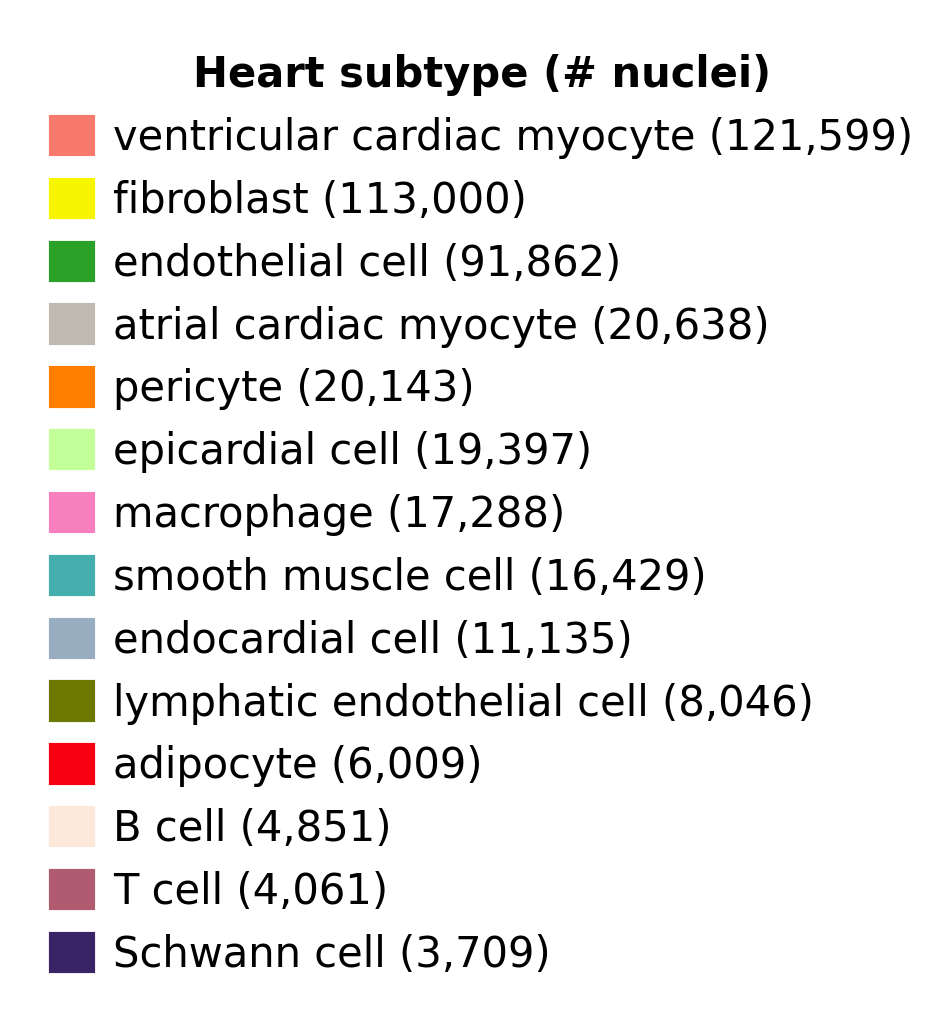

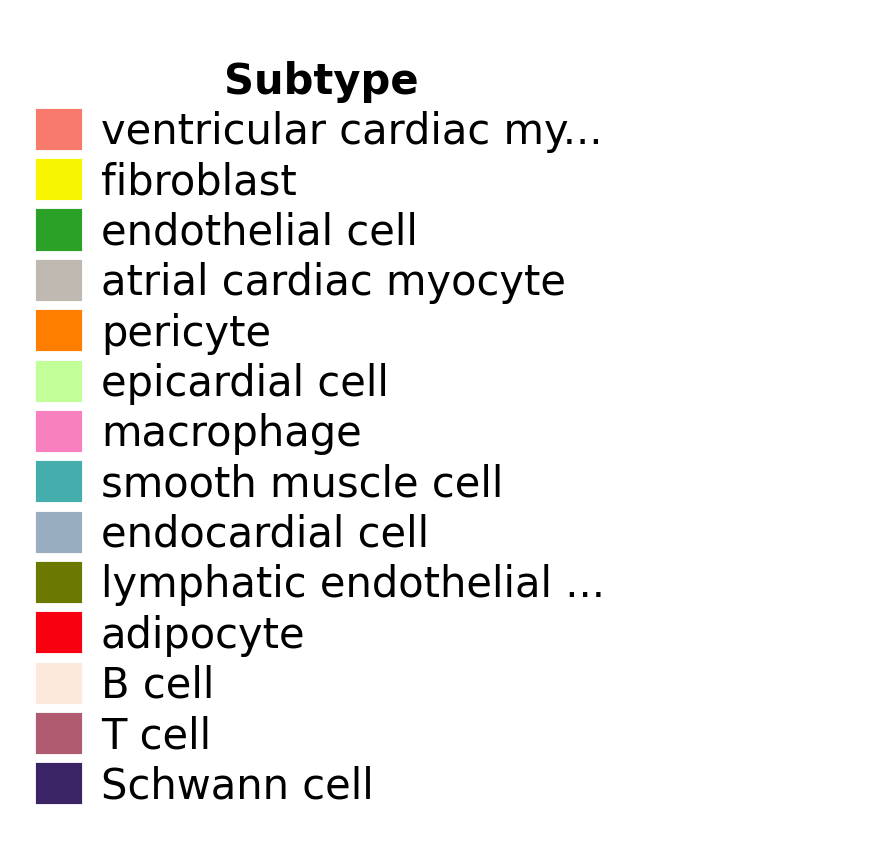

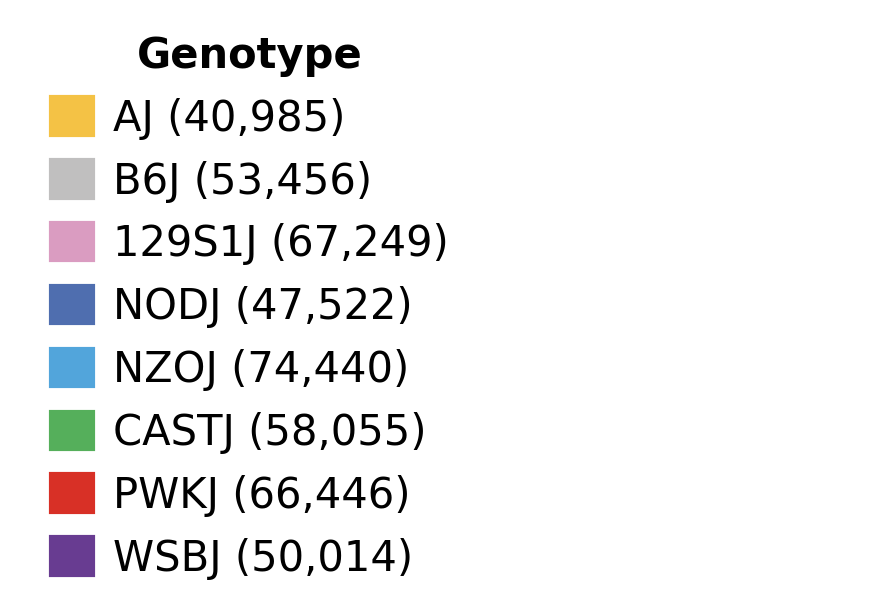

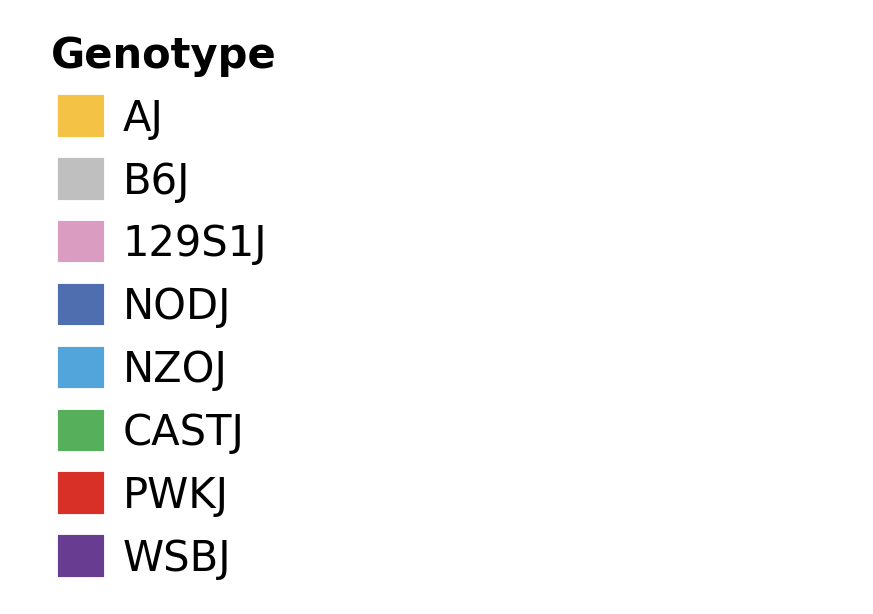

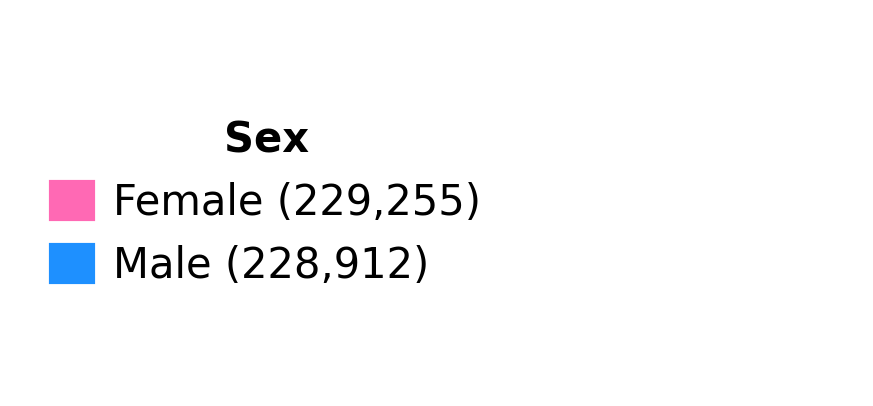

In [127]:
ordered_celltypes = metadata.set_index('leiden').loc[ordered_clusters]['subtype'].values
ordered_celltypes = list(dict.fromkeys(ordered_celltypes))  # remove duplicates, keep order
ordered_celltypes = ordered_celltypes[::-1]  # reverse it

from collections import Counter
celltype_counts = metadata['subtype'].value_counts()

tissue_label_map = {
    "CortexHippocampus": "Cortex/Hippocampus",
    "DiencephalonPituitary": "Diencephalon/Pituitary",
    "GonadsMale": "Male gonads",
    "GonadsFemale": "Female gonads"
}

# Fallback to original if not in map
pretty_tissue = tissue_label_map.get(tissue, tissue)


label = f"{pretty_tissue} subtype (# nuclei)"
fname = f"{tissue}_celltype_legend"

create_standalone_legend(
    color_dict=celltype_palette,
    label=label,
    order=ordered_celltypes,
    counts=celltype_counts,
    ncol=1,
    fname = fname
)


metadata["subtype_abbrev"] = metadata["subtype"].apply(abbreviate)

ordered_celltype_abbrev = [abbreviate(ct) for ct in ordered_celltypes]

celltype_counts = metadata['subtype_abbrev'].value_counts()

label = f"Subtype"
fname = f"{tissue}_simple_celltype_legend"

celltype_palette_abbrev = {
    abbreviate(ct): color for ct, color in celltype_palette.items()
    if abbreviate(ct) in set(ordered_celltype_abbrev)
}

create_standalone_legend_squish(
    color_dict=celltype_palette_abbrev,
    label=label,
    order=ordered_celltype_abbrev,
    ncol=1,
    fname = fname
)


geno_counts = metadata['Genotype'].value_counts()

label = f"Genotype"
fname = f"{tissue}_geno_legend"

create_standalone_legend(
    color_dict=geno_palette,
    label=label,
    order=genotype_order,
    counts=geno_counts,
    ncol=1,
    fname = fname
)


geno_counts = metadata['Genotype'].value_counts()

label = f"Genotype"
fname = f"{tissue}_simple_geno_legend"

create_standalone_legend(
    color_dict=geno_palette,
    label=label,
    order=genotype_order,
    ncol=1,
    fname = fname
)


sex_counts = metadata['Sex'].value_counts()

label = f"Sex"
fname = f"{tissue}_sex_legend"

create_standalone_legend(
    color_dict=sex_palette,
    label=label,
    order=['Female', 'Male'],
    counts=sex_counts,
    ncol=1,
    fname = fname
)

## Proportions of genotypes across celltypes

/tmp/ipykernel_1504450/257901544.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = obs.groupby([cluster_key, var_key]).size().unstack(fill_value=0)


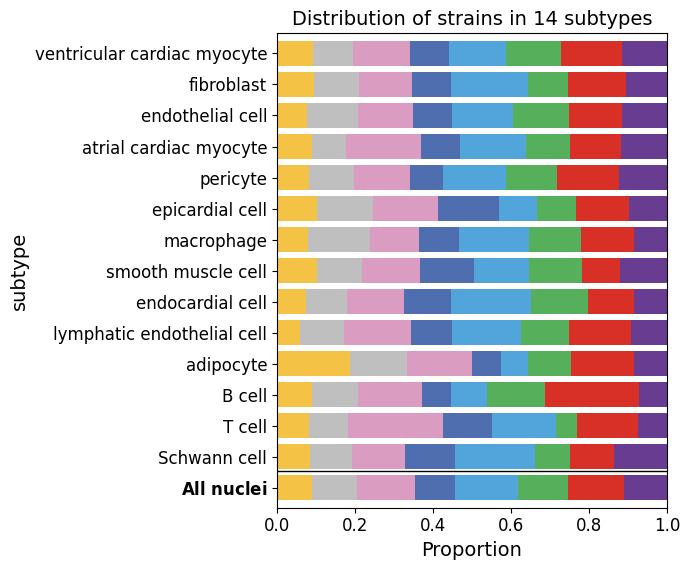

In [128]:
# Copy metadata and append summary row
plot_df = metadata.copy()

# Create a dummy celltype entry for all cells combined
summary_row = plot_df.copy()
summary_row['subtype'] = 'All nuclei'

# Append to the bottom of the dataframe
plot_df = pd.concat([plot_df, summary_row], axis=0)

# Add 'All cells' to the cluster order list (at the end)
ordered_celltypes2 =  ['All nuclei'] + ordered_celltypes[::-1] 

# Now plot!
fig = plt.figure(figsize=(7, 5.8))  # slightly taller
gs = gridspec.GridSpec(1, 1)
ax = fig.add_subplot(gs[0])

stacked_barplot_proportions(
    plot_df,
    cluster_key="subtype",
    var_key="Genotype",
    color_dict=geno_palette,
    cluster_order=ordered_celltypes2,
    annotations=False,
    fsize=None,
    ax=ax
)

ax.axhline(y=0.54, color='black', linestyle='-', linewidth=1)

# Get current y-axis tick labels
yticklabels = [label.get_text() for label in ax.get_yticklabels()]

# Rebuild the list with "All cells" in bold
new_labels = []
for label in yticklabels:
    if label == 'All nuclei':
        new_labels.append(r"$\bf{All\ nuclei}$")  # bold with math text
    else:
        new_labels.append(label)

# Apply new labels
ax.set_yticklabels(new_labels)

n_celltypes = len(ordered_celltypes)
ax.set_title(f"Distribution of strains in {n_celltypes} subtypes", fontsize=14)


plt.tight_layout()

plt.savefig(f"../new_supp/{tissue}_genotype_distribution_across_celltypes_bar.png", dpi=300, bbox_inches='tight', transparent = True)

plt.show()


## Proportion of celltypes across genotypes

/tmp/ipykernel_1504450/257901544.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = obs.groupby([cluster_key, var_key]).size().unstack(fill_value=0)


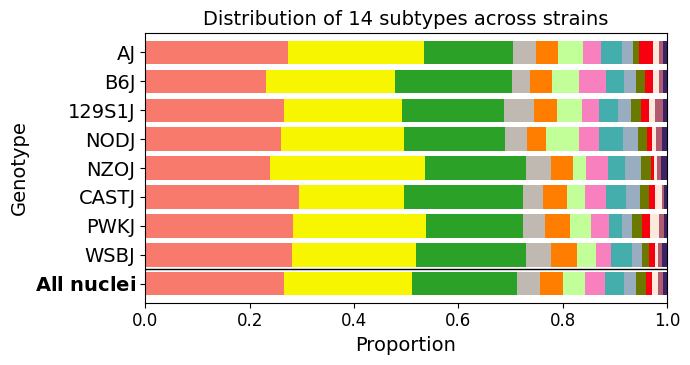

In [129]:
# Copy metadata and append summary row
plot_df = metadata.copy()

# Create a dummy genotype entry for all cells combined
summary_row = plot_df.copy()
summary_row['Genotype'] = 'All nuclei'

# Append to the bottom of the dataframe
plot_df = pd.concat([plot_df, summary_row], axis=0)

# Subtype category setup
plot_df['subtype'] = pd.Categorical(
    plot_df['subtype'],
    categories=ordered_celltypes,
    ordered=True
)

# Genotype category setup, include 'All nuclei' at the end
genotype_order = ["AJ", "B6J", "129S1J", "NODJ", "NZOJ", "CASTJ", "PWKJ", "WSBJ"]
genotype_order_reversed = ['All nuclei'] + genotype_order[::-1]

plot_df['Genotype'] = pd.Categorical(
    plot_df['Genotype'],
    categories=genotype_order_reversed,
    ordered=True
)

# Plot
fig = plt.figure(figsize=(7, 3.75))  # slightly taller
gs = gridspec.GridSpec(1, 1)
ax = fig.add_subplot(gs[0])

stacked_barplot_proportions(
    plot_df,
    cluster_key="Genotype",
    var_key="subtype",
    color_dict=celltype_palette,
    cluster_order=genotype_order_reversed,
    annotations=False,
    fsize=None,
    ax=ax
)

ax.tick_params(axis='y', labelsize=14)

ax.axhline(y=0.52, color='black', linestyle='-', linewidth=1)

# Get current y-axis tick labels
yticklabels = [label.get_text() for label in ax.get_yticklabels()]

# Rebuild the list with "All cells" in bold
new_labels = []
for label in yticklabels:
    if label == 'All nuclei':
        new_labels.append(r"$\bf{All\ nuclei}$")  # bold with math text
    else:
        new_labels.append(label)

# Apply new labels
ax.set_yticklabels(new_labels)


ax.set_title(f"Distribution of {len(ordered_celltypes)} subtypes across strains", fontsize=14)

plt.tight_layout()
plt.savefig(f"../new_supp/{tissue}_celltype_distribution_across_genotypes_bar.png", dpi=300, bbox_inches='tight', transparent = True)
plt.show()


In [130]:
metadata.shape

(458167, 55)

# Adrenal

/tmp/ipykernel_1504450/483911224.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_info.groupby(['leiden_R', 'Genotype']).size().rename('geno_total').reset_index()
/tmp/ipykernel_1504450/257901544.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = obs.groupby([cluster_key, var_key]).size().unstack(fill_value=0)
/tmp/ipykernel_1504450/483911224.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


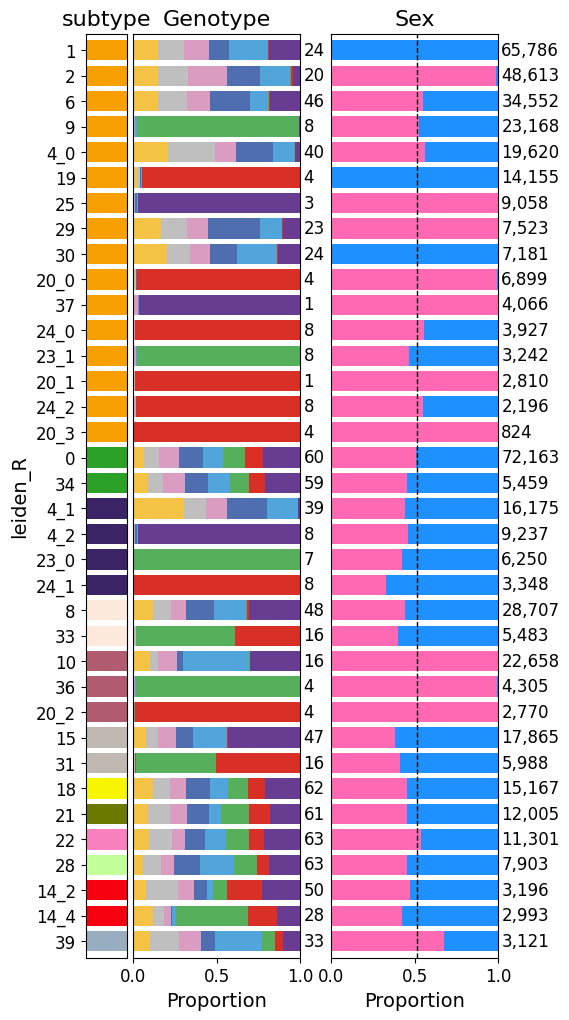

In [170]:
tissue = 'Adrenal'
random.seed(13)

metadata = pd.read_csv(f'/share/crsp/lab/seyedam/share/igvf_pipeline/IGVF_analysis/cellbender_tissues/obs_tables/{tissue}_annotated_metadata.csv')
metadata = metadata[metadata['subtype'] != 'low quality']

metadata['Genotype'] = pd.Categorical(
    metadata['Genotype'],
    categories=genotype_order,
    ordered=True
)

# === Define palettes ===

# Celltype colors
all_celltypes = metadata['subtype'].unique()
default_palette = sc.pl.palettes.default_102

remaining_celltypes = [ct for ct in all_celltypes if ct not in custom_colors]
remaining_colors = default_palette[:len(remaining_celltypes)]
random.shuffle(remaining_colors)

remaining_dict = dict(zip(remaining_celltypes, remaining_colors))
celltype_palette = {**custom_colors, **remaining_dict}

# Sex & genotype palettes
sex_palette = {'Male': 'dodgerblue', 'Female': 'hotpink'}
genotype_palette = dict(zip(metadata['Genotype'].unique(), sns.color_palette("tab20", n_colors=10)))

# === Cluster ordering by subtype then size ===

df = metadata[['leiden_R', 'subtype']]
celltype_sizes = df['subtype'].value_counts()
cluster_sizes = df['leiden_R'].value_counts()
cluster_to_celltype = df.set_index('leiden_R')['subtype'].to_dict()

from collections import defaultdict
celltype_to_clusters = defaultdict(list)
for cluster, celltype in cluster_to_celltype.items():
    celltype_to_clusters[celltype].append(cluster)

ordered_clusters = []
for celltype in celltype_sizes.index:
    clusters = celltype_to_clusters[celltype]
    clusters_sorted = sorted(clusters, key=lambda c: -cluster_sizes[c])
    ordered_clusters.extend(clusters_sorted)
ordered_clusters = ordered_clusters[::-1]

# === Filter for meaningful mouse contribution by genotype ===

cell_info = metadata[['leiden_R', 'lab_sample_id', 'Genotype']].copy()

# Cluster-level totals
cluster_totals = cell_info['leiden_R'].value_counts().rename("cluster_total").reset_index()
cluster_totals.columns = ['leiden_R', 'cluster_total']

# Genotype totals per cluster
geno_cluster_totals = (
    cell_info.groupby(['leiden_R', 'Genotype']).size().rename('geno_total').reset_index()
)
geno_cluster_totals = geno_cluster_totals.merge(cluster_totals, on='leiden_R')
geno_cluster_totals['geno_fraction'] = geno_cluster_totals['geno_total'] / geno_cluster_totals['cluster_total']
significant_genotypes = geno_cluster_totals[geno_cluster_totals['geno_fraction'] >= 0.05]

# Mouse contributions
mouse_counts = (
    cell_info.groupby(['leiden_R', 'lab_sample_id']).size().rename('mouse_count').reset_index()
)
lab_sample_to_geno = cell_info.drop_duplicates('lab_sample_id').set_index('lab_sample_id')['Genotype']
mouse_counts['Genotype'] = mouse_counts['lab_sample_id'].map(lab_sample_to_geno)

# Merge and compute proportion
merged = pd.merge(
    mouse_counts,
    significant_genotypes[['leiden_R', 'Genotype', 'geno_total']],
    on=['leiden_R', 'Genotype'],
    how='inner'
)
merged['proportion'] = merged['mouse_count'] / merged['geno_total']
meaningful = merged[merged['proportion'] >= 0.05]

# Final counts
n_mice_per_cluster = (
    meaningful.groupby('leiden_R')['lab_sample_id']
    .nunique().reindex(ordered_clusters).fillna(0).astype(int)
)
n_nuclei_per_cluster = metadata['leiden_R'].value_counts().reindex(ordered_clusters)

# === Plotting ===

fig = plt.figure(figsize=(5, 12))
gs = gridspec.GridSpec(1, 3, width_ratios=[0.5, 2, 2], wspace=0.05)
axs = [fig.add_subplot(gs[i]) for i in range(3)]

# Panel 1: Celltype identity
stacked_barplot_proportions(
    metadata,
    cluster_key="leiden_R",
    var_key="subtype",
    color_dict=celltype_palette,
    cluster_order=ordered_clusters,
    annotations=False,
    fsize=None,
    ax=axs[0]
)

# Panel 2: Genotype proportions with # mice
stacked_barplot_proportions(
    metadata,
    cluster_key="leiden_R",
    var_key="Genotype",
    color_dict=geno_palette,
    cluster_order=ordered_clusters,
    annotations=True,
    annotate_vals=n_mice_per_cluster,
    fsize=None,
    ax=axs[1]
)

# Panel 3: Sex proportions with # nuclei
stacked_barplot_proportions(
    metadata,
    cluster_key="leiden_R",
    var_key="Sex",
    color_dict=sex_palette,
    cluster_order=ordered_clusters,
    annotations=True,
    annotate_vals=n_nuclei_per_cluster,
    fsize=None,
    ax=axs[2]
)

# === Final formatting ===

axs[0].set_xlabel("")
axs[2].set_position([
    axs[2].get_position().x0 + 0.05,
    axs[2].get_position().y0,
    axs[2].get_position().width,
    axs[2].get_position().height
])
axs[0].tick_params(axis='x', bottom=False, labelbottom=False)
axs[1].tick_params(axis='y', length=0)
axs[2].tick_params(axis='y', length=0)
axs[1].set_yticklabels([])
axs[2].set_yticklabels([])
axs[1].set_ylabel("")
axs[2].set_ylabel("")

for ax in axs:
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

female_fraction = (metadata['Sex'] == 'Female').mean()
axs[2].axvline(female_fraction, linestyle='--', color='black', linewidth=1)

plt.tight_layout()
plt.savefig(f"../new_supp/{tissue}_cluster_annotations_barplots.png", dpi=300, bbox_inches='tight', transparent = True)
plt.show()


## Legends

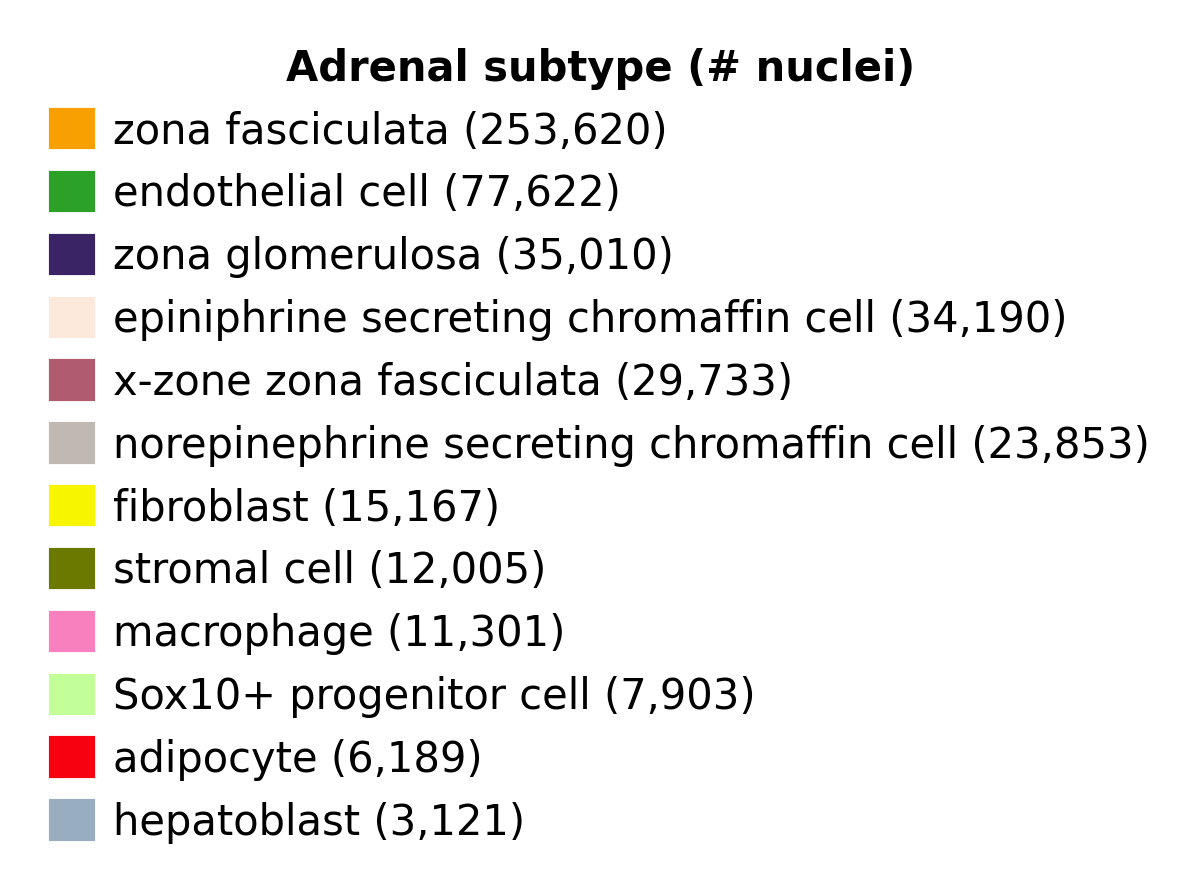

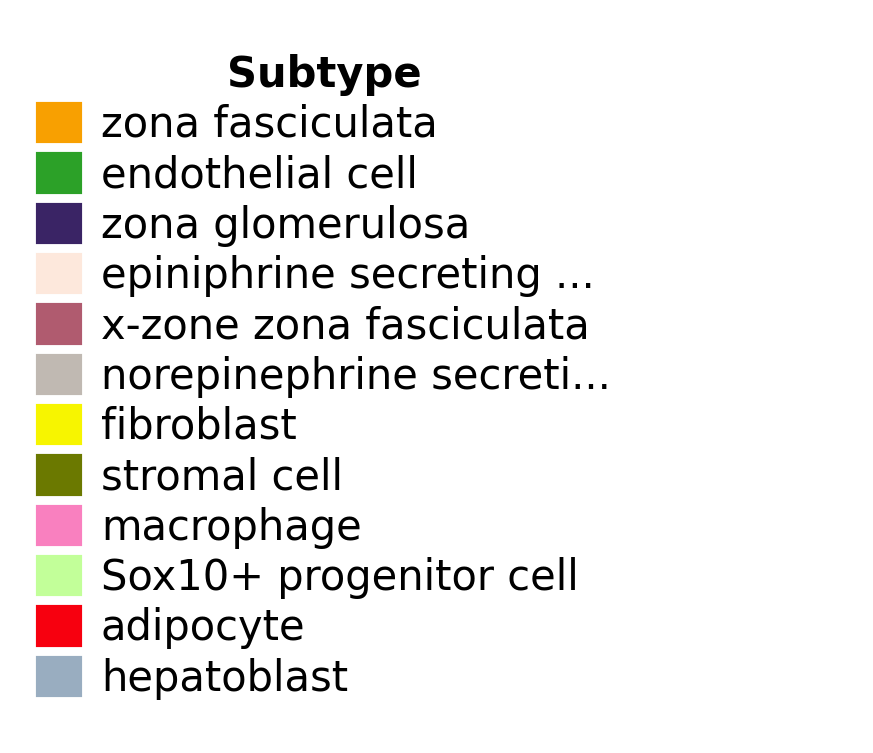

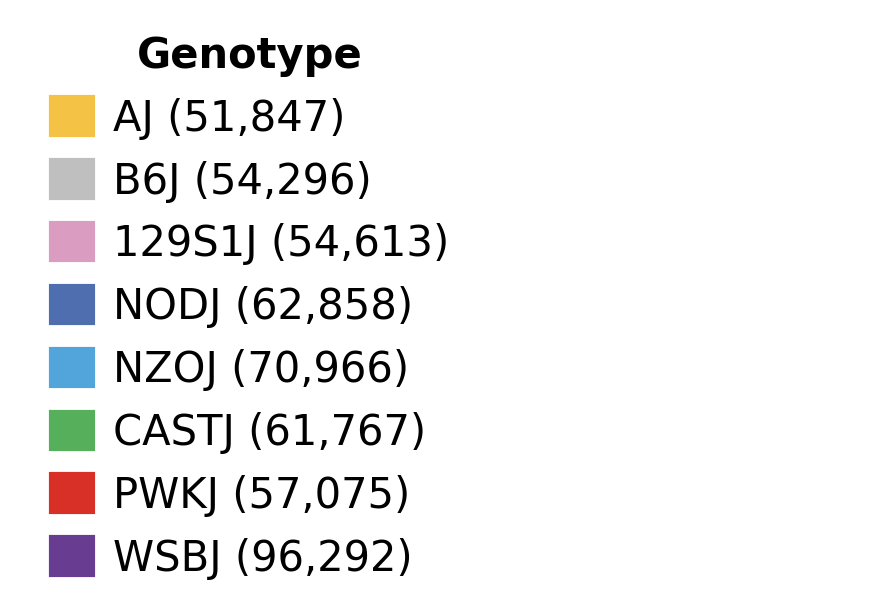

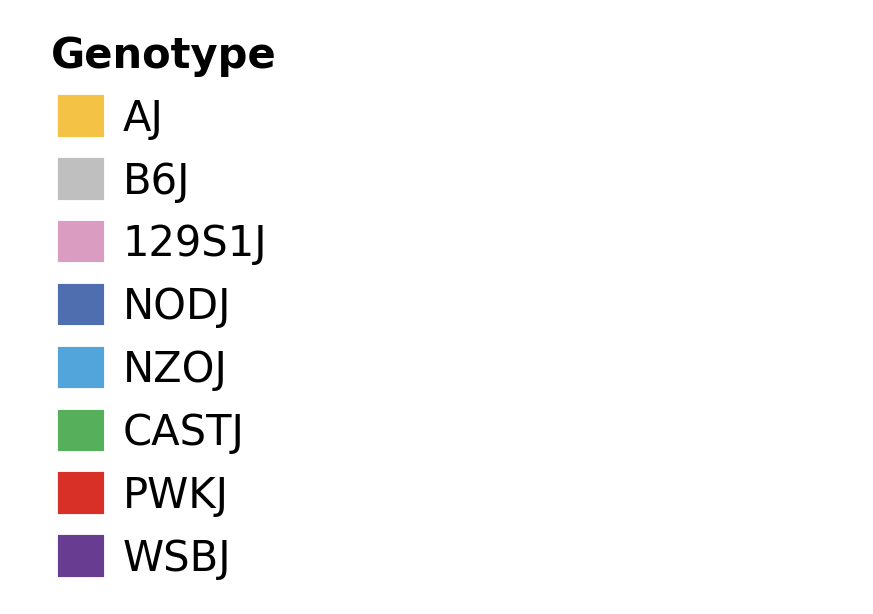

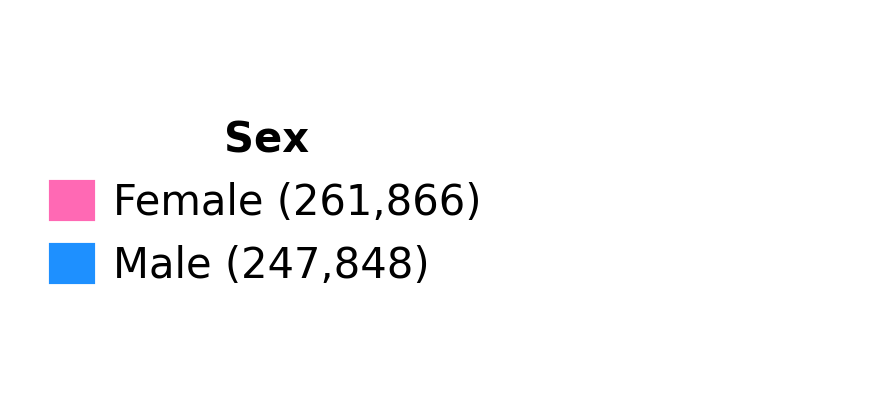

In [171]:
ordered_celltypes = metadata.set_index('leiden_R').loc[ordered_clusters]['subtype'].values
ordered_celltypes = list(dict.fromkeys(ordered_celltypes))  # remove duplicates, keep order
ordered_celltypes = ordered_celltypes[::-1]  # reverse it

from collections import Counter
celltype_counts = metadata['subtype'].value_counts()

tissue_label_map = {
    "CortexHippocampus": "Cortex/Hippocampus",
    "DiencephalonPituitary": "Diencephalon/Pituitary",
    "GonadsMale": "Male gonads",
    "GonadsFemale": "Female gonads"
}

# Fallback to original if not in map
pretty_tissue = tissue_label_map.get(tissue, tissue)


label = f"{pretty_tissue} subtype (# nuclei)"
fname = f"{tissue}_celltype_legend"

create_standalone_legend(
    color_dict=celltype_palette,
    label=label,
    order=ordered_celltypes,
    counts=celltype_counts,
    ncol=1,
    fname = fname
)


metadata["subtype_abbrev"] = metadata["subtype"].apply(abbreviate)

ordered_celltype_abbrev = [abbreviate(ct) for ct in ordered_celltypes]

celltype_counts = metadata['subtype_abbrev'].value_counts()

label = f"Subtype"
fname = f"{tissue}_simple_celltype_legend"

celltype_palette_abbrev = {
    abbreviate(ct): color for ct, color in celltype_palette.items()
    if abbreviate(ct) in set(ordered_celltype_abbrev)
}

create_standalone_legend_squish(
    color_dict=celltype_palette_abbrev,
    label=label,
    order=ordered_celltype_abbrev,
    ncol=1,
    fname = fname
)


geno_counts = metadata['Genotype'].value_counts()

label = f"Genotype"
fname = f"{tissue}_geno_legend"

create_standalone_legend(
    color_dict=geno_palette,
    label=label,
    order=genotype_order,
    counts=geno_counts,
    ncol=1,
    fname = fname
)


geno_counts = metadata['Genotype'].value_counts()

label = f"Genotype"
fname = f"{tissue}_simple_geno_legend"

create_standalone_legend(
    color_dict=geno_palette,
    label=label,
    order=genotype_order,
    ncol=1,
    fname = fname
)


sex_counts = metadata['Sex'].value_counts()

label = f"Sex"
fname = f"{tissue}_sex_legend"

create_standalone_legend(
    color_dict=sex_palette,
    label=label,
    order=['Female', 'Male'],
    counts=sex_counts,
    ncol=1,
    fname = fname
)

## Proportion of genotypes across celltypes

/tmp/ipykernel_1504450/257901544.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = obs.groupby([cluster_key, var_key]).size().unstack(fill_value=0)


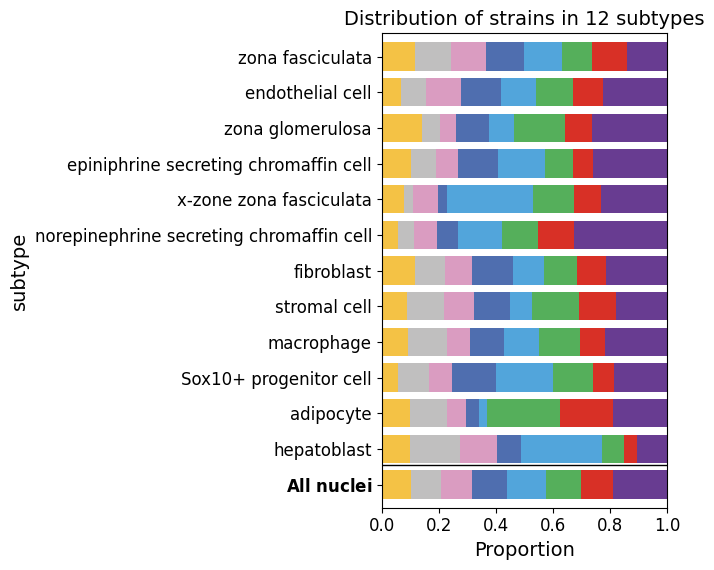

In [172]:
# Copy metadata and append summary row
plot_df = metadata.copy()

# Create a dummy celltype entry for all cells combined
summary_row = plot_df.copy()
summary_row['subtype'] = 'All nuclei'

# Append to the bottom of the dataframe
plot_df = pd.concat([plot_df, summary_row], axis=0)

# Add 'All cells' to the cluster order list (at the end)
ordered_celltypes2 =  ['All nuclei'] + ordered_celltypes[::-1] 

# Now plot!
fig = plt.figure(figsize=(7, 5.8))  # slightly taller
gs = gridspec.GridSpec(1, 1)
ax = fig.add_subplot(gs[0])

stacked_barplot_proportions(
    plot_df,
    cluster_key="subtype",
    var_key="Genotype",
    color_dict=geno_palette,
    cluster_order=ordered_celltypes2,
    annotations=False,
    fsize=None,
    ax=ax
)

ax.axhline(y=0.54, color='black', linestyle='-', linewidth=1)

# Get current y-axis tick labels
yticklabels = [label.get_text() for label in ax.get_yticklabels()]

# Rebuild the list with "All cells" in bold
new_labels = []
for label in yticklabels:
    if label == 'All nuclei':
        new_labels.append(r"$\bf{All\ nuclei}$")  # bold with math text
    else:
        new_labels.append(label)

# Apply new labels
ax.set_yticklabels(new_labels)

n_celltypes = len(ordered_celltypes)
ax.set_title(f"Distribution of strains in {n_celltypes} subtypes", fontsize=14)


plt.tight_layout()

plt.savefig(f"../new_supp/{tissue}_genotype_distribution_across_celltypes_bar.png", dpi=300, bbox_inches='tight', transparent = True)

plt.show()


## Proportion of celltypes across genotypes

/tmp/ipykernel_1504450/257901544.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = obs.groupby([cluster_key, var_key]).size().unstack(fill_value=0)


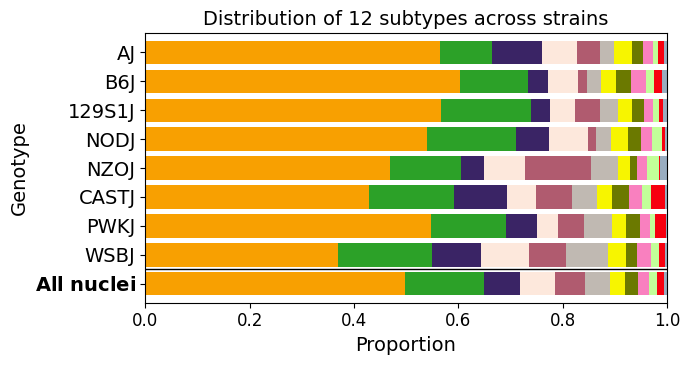

In [173]:
# Copy metadata and append summary row
plot_df = metadata.copy()

# Create a dummy genotype entry for all cells combined
summary_row = plot_df.copy()
summary_row['Genotype'] = 'All nuclei'

# Append to the bottom of the dataframe
plot_df = pd.concat([plot_df, summary_row], axis=0)

# Subtype category setup
plot_df['subtype'] = pd.Categorical(
    plot_df['subtype'],
    categories=ordered_celltypes,
    ordered=True
)

# Genotype category setup, include 'All nuclei' at the end
genotype_order = ["AJ", "B6J", "129S1J", "NODJ", "NZOJ", "CASTJ", "PWKJ", "WSBJ"]
genotype_order_reversed = ['All nuclei'] + genotype_order[::-1]

plot_df['Genotype'] = pd.Categorical(
    plot_df['Genotype'],
    categories=genotype_order_reversed,
    ordered=True
)

# Plot
fig = plt.figure(figsize=(7, 3.75))  # slightly taller
gs = gridspec.GridSpec(1, 1)
ax = fig.add_subplot(gs[0])

stacked_barplot_proportions(
    plot_df,
    cluster_key="Genotype",
    var_key="subtype",
    color_dict=celltype_palette,
    cluster_order=genotype_order_reversed,
    annotations=False,
    fsize=None,
    ax=ax
)

ax.tick_params(axis='y', labelsize=14)

ax.axhline(y=0.52, color='black', linestyle='-', linewidth=1)

# Get current y-axis tick labels
yticklabels = [label.get_text() for label in ax.get_yticklabels()]

# Rebuild the list with "All cells" in bold
new_labels = []
for label in yticklabels:
    if label == 'All nuclei':
        new_labels.append(r"$\bf{All\ nuclei}$")  # bold with math text
    else:
        new_labels.append(label)

# Apply new labels
ax.set_yticklabels(new_labels)


ax.set_title(f"Distribution of {len(ordered_celltypes)} subtypes across strains", fontsize=14)

plt.tight_layout()
plt.savefig(f"../new_supp/{tissue}_celltype_distribution_across_genotypes_bar.png", dpi=300, bbox_inches='tight', transparent = True)
plt.show()


In [174]:
metadata.shape

(509714, 56)

# Male gonads

/tmp/ipykernel_1504450/2435888270.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_info.groupby(['leiden_R', 'Genotype']).size().rename('geno_total').reset_index()
/tmp/ipykernel_1504450/257901544.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = obs.groupby([cluster_key, var_key]).size().unstack(fill_value=0)
/tmp/ipykernel_1504450/2435888270.py:162: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


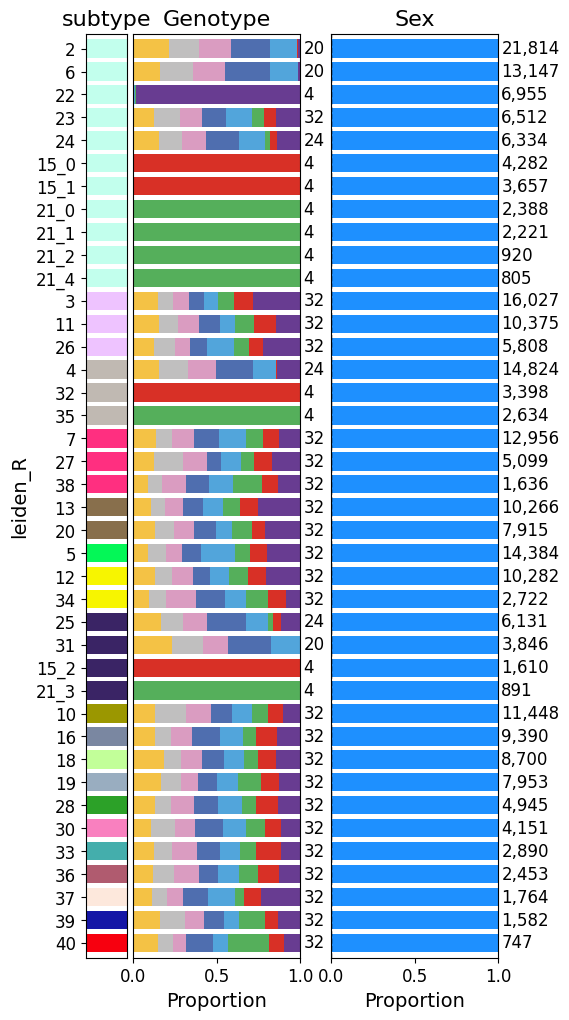

In [259]:
tissue = 'GonadsMale'
random.seed(922) # 300

metadata = pd.read_csv(f'/share/crsp/lab/seyedam/share/igvf_pipeline/IGVF_analysis/cellbender_tissues/obs_tables/{tissue}_annotated_metadata.csv')
metadata = metadata[metadata['subtype'] != 'low quality']

metadata['Genotype'] = pd.Categorical(
    metadata['Genotype'],
    categories=genotype_order,
    ordered=True
)

# === Define palettes ===

# Celltype colors
all_celltypes = metadata['subtype'].unique()
default_palette = sc.pl.palettes.default_102

# Unwanted colors to exclude
excluded_colors = {"#456648", "#549E79", "#6B7900"}
default_palette = [c for c in default_palette if c not in excluded_colors]

remaining_celltypes = [ct for ct in all_celltypes if ct not in custom_colors]
remaining_colors = default_palette[:len(remaining_celltypes)]
random.shuffle(remaining_colors)

remaining_dict = dict(zip(remaining_celltypes, remaining_colors))
celltype_palette = {**custom_colors, **remaining_dict}

# Sex & genotype palettes
sex_palette = {'Male': 'dodgerblue', 'Female': 'hotpink'}
genotype_palette = dict(zip(metadata['Genotype'].unique(), sns.color_palette("tab20", n_colors=10)))

# === Cluster ordering by subtype then size ===

df = metadata[['leiden_R', 'subtype']]
celltype_sizes = df['subtype'].value_counts()
cluster_sizes = df['leiden_R'].value_counts()
cluster_to_celltype = df.set_index('leiden_R')['subtype'].to_dict()

from collections import defaultdict
celltype_to_clusters = defaultdict(list)
for cluster, celltype in cluster_to_celltype.items():
    celltype_to_clusters[celltype].append(cluster)

ordered_clusters = []
for celltype in celltype_sizes.index:
    clusters = celltype_to_clusters[celltype]
    clusters_sorted = sorted(clusters, key=lambda c: -cluster_sizes[c])
    ordered_clusters.extend(clusters_sorted)
ordered_clusters = ordered_clusters[::-1]

# === Filter for meaningful mouse contribution by genotype ===

cell_info = metadata[['leiden_R', 'lab_sample_id', 'Genotype']].copy()

# Cluster-level totals
cluster_totals = cell_info['leiden_R'].value_counts().rename("cluster_total").reset_index()
cluster_totals.columns = ['leiden_R', 'cluster_total']

# Genotype totals per cluster
geno_cluster_totals = (
    cell_info.groupby(['leiden_R', 'Genotype']).size().rename('geno_total').reset_index()
)
geno_cluster_totals = geno_cluster_totals.merge(cluster_totals, on='leiden_R')
geno_cluster_totals['geno_fraction'] = geno_cluster_totals['geno_total'] / geno_cluster_totals['cluster_total']
significant_genotypes = geno_cluster_totals[geno_cluster_totals['geno_fraction'] >= 0.05]

# Mouse contributions
mouse_counts = (
    cell_info.groupby(['leiden_R', 'lab_sample_id']).size().rename('mouse_count').reset_index()
)
lab_sample_to_geno = cell_info.drop_duplicates('lab_sample_id').set_index('lab_sample_id')['Genotype']
mouse_counts['Genotype'] = mouse_counts['lab_sample_id'].map(lab_sample_to_geno)

# Merge and compute proportion
merged = pd.merge(
    mouse_counts,
    significant_genotypes[['leiden_R', 'Genotype', 'geno_total']],
    on=['leiden_R', 'Genotype'],
    how='inner'
)
merged['proportion'] = merged['mouse_count'] / merged['geno_total']
meaningful = merged[merged['proportion'] >= 0.05]

# Final counts
n_mice_per_cluster = (
    meaningful.groupby('leiden_R')['lab_sample_id']
    .nunique().reindex(ordered_clusters).fillna(0).astype(int)
)
n_nuclei_per_cluster = metadata['leiden_R'].value_counts().reindex(ordered_clusters)

# === Plotting ===

fig = plt.figure(figsize=(5, 12))
gs = gridspec.GridSpec(1, 3, width_ratios=[0.5, 2, 2], wspace=0.05)
axs = [fig.add_subplot(gs[i]) for i in range(3)]

# Panel 1: Celltype identity
stacked_barplot_proportions(
    metadata,
    cluster_key="leiden_R",
    var_key="subtype",
    color_dict=celltype_palette,
    cluster_order=ordered_clusters,
    annotations=False,
    fsize=None,
    ax=axs[0]
)

# Panel 2: Genotype proportions with # mice
stacked_barplot_proportions(
    metadata,
    cluster_key="leiden_R",
    var_key="Genotype",
    color_dict=geno_palette,
    cluster_order=ordered_clusters,
    annotations=True,
    annotate_vals=n_mice_per_cluster,
    fsize=None,
    ax=axs[1]
)

# Panel 3: Sex proportions with # nuclei
stacked_barplot_proportions(
    metadata,
    cluster_key="leiden_R",
    var_key="Sex",
    color_dict=sex_palette,
    cluster_order=ordered_clusters,
    annotations=True,
    annotate_vals=n_nuclei_per_cluster,
    fsize=None,
    ax=axs[2]
)

# === Final formatting ===

axs[0].set_xlabel("")
axs[2].set_position([
    axs[2].get_position().x0 + 0.05,
    axs[2].get_position().y0,
    axs[2].get_position().width,
    axs[2].get_position().height
])
axs[0].tick_params(axis='x', bottom=False, labelbottom=False)
axs[1].tick_params(axis='y', length=0)
axs[2].tick_params(axis='y', length=0)
axs[1].set_yticklabels([])
axs[2].set_yticklabels([])
axs[1].set_ylabel("")
axs[2].set_ylabel("")

for ax in axs:
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

female_fraction = (metadata['Sex'] == 'Female').mean()
axs[2].axvline(female_fraction, linestyle='--', color='black', linewidth=1)

plt.tight_layout()
plt.savefig(f"../new_supp/{tissue}_cluster_annotations_barplots.png", dpi=300, bbox_inches='tight', transparent = True)
plt.show()


In [260]:
metadata.shape

(255862, 57)

## Legends

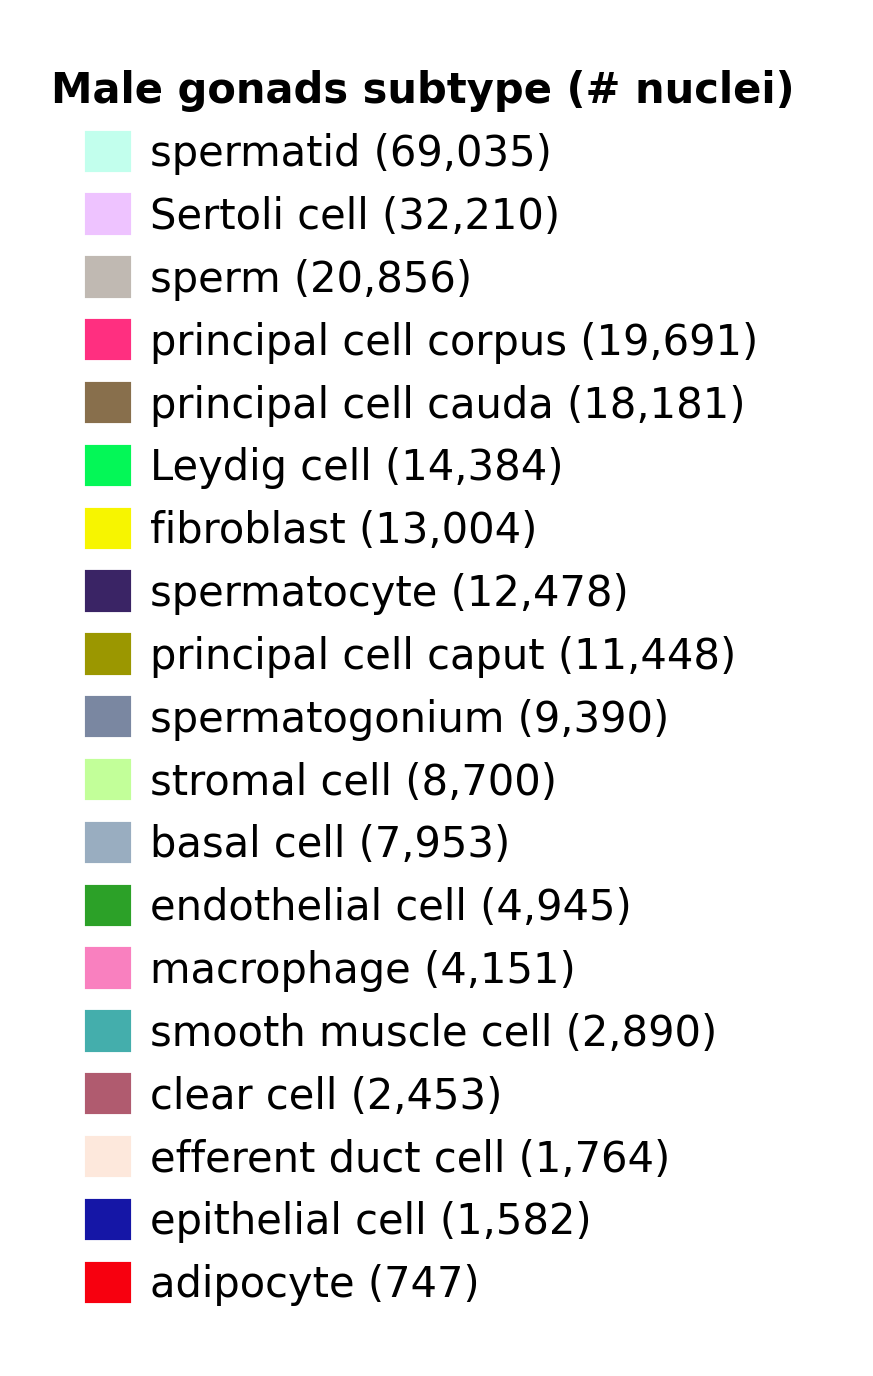

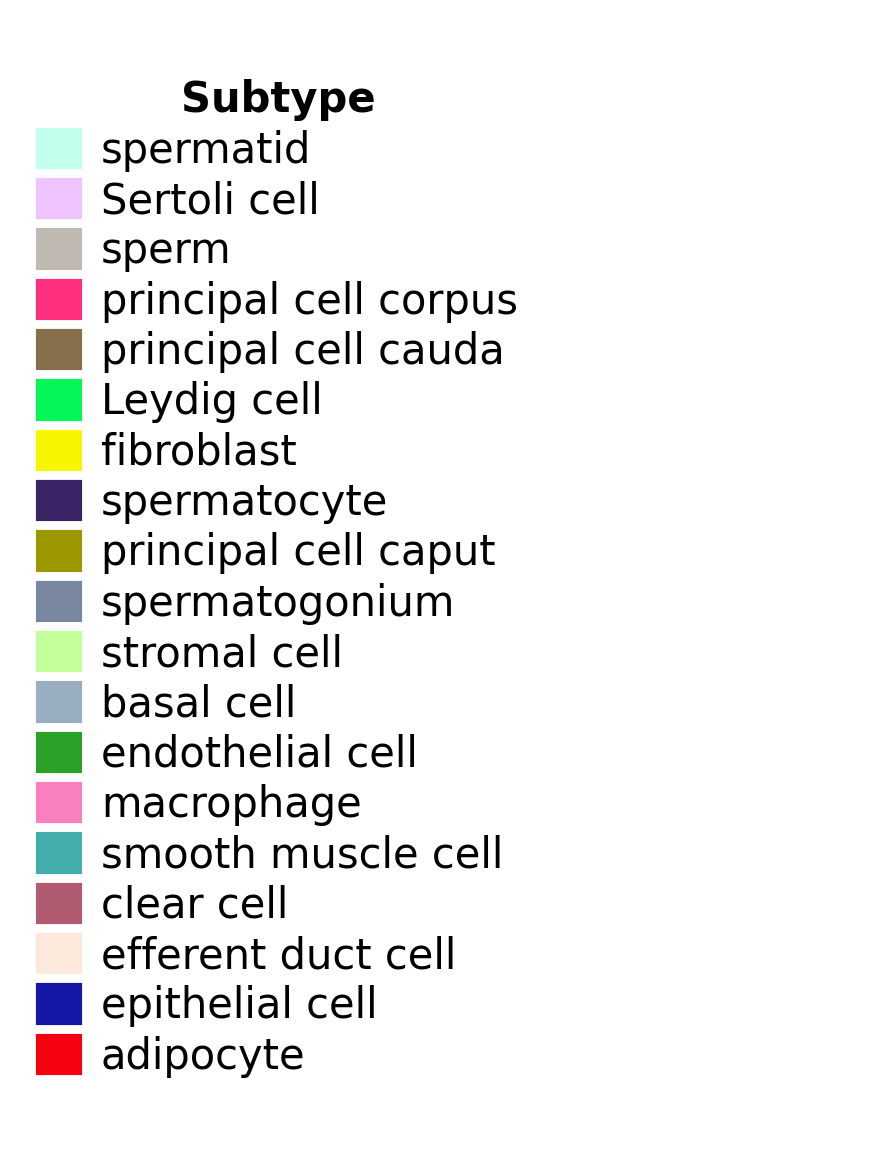

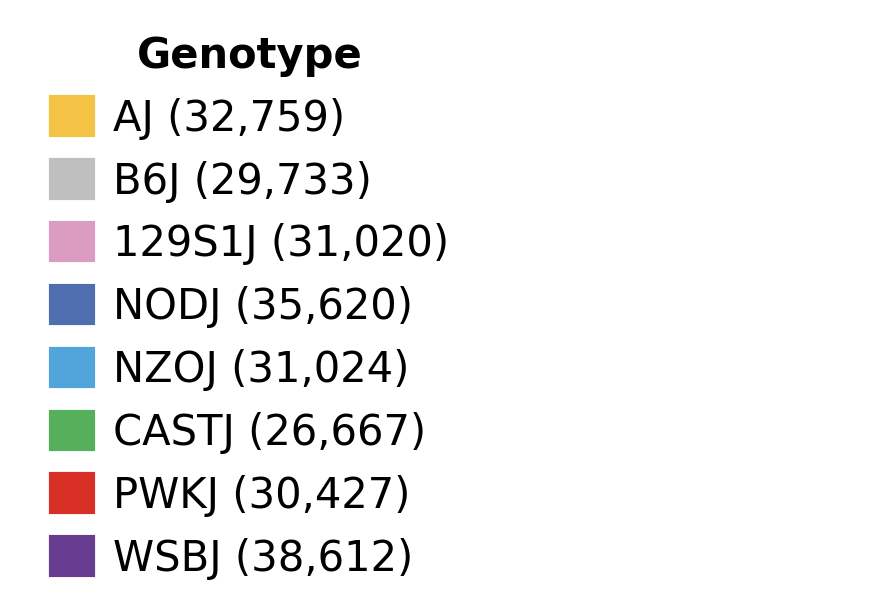

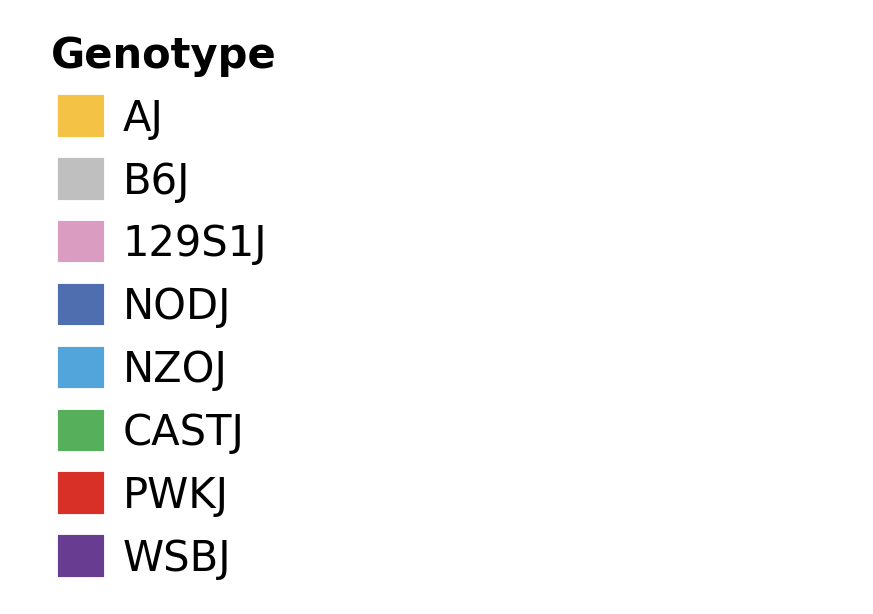

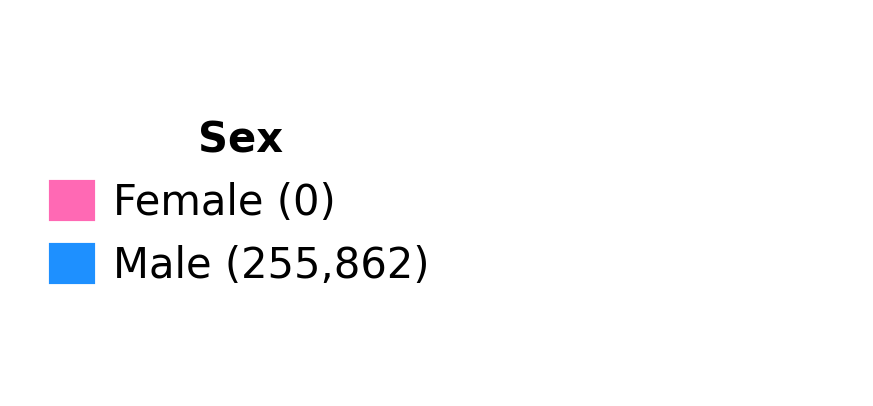

In [216]:
ordered_celltypes = metadata.set_index('leiden_R').loc[ordered_clusters]['subtype'].values
ordered_celltypes = list(dict.fromkeys(ordered_celltypes))  # remove duplicates, keep order
ordered_celltypes = ordered_celltypes[::-1]  # reverse it

from collections import Counter
celltype_counts = metadata['subtype'].value_counts()

tissue_label_map = {
    "CortexHippocampus": "Cortex/Hippocampus",
    "DiencephalonPituitary": "Diencephalon/Pituitary",
    "GonadsMale": "Male gonads",
    "GonadsFemale": "Female gonads"
}

# Fallback to original if not in map
pretty_tissue = tissue_label_map.get(tissue, tissue)


label = f"{pretty_tissue} subtype (# nuclei)"
fname = f"{tissue}_celltype_legend"

create_standalone_legend(
    color_dict=celltype_palette,
    label=label,
    order=ordered_celltypes,
    counts=celltype_counts,
    ncol=1,
    fname = fname
)


metadata["subtype_abbrev"] = metadata["subtype"].apply(abbreviate)

ordered_celltype_abbrev = [abbreviate(ct) for ct in ordered_celltypes]

celltype_counts = metadata['subtype_abbrev'].value_counts()

label = f"Subtype"
fname = f"{tissue}_simple_celltype_legend"

celltype_palette_abbrev = {
    abbreviate(ct): color for ct, color in celltype_palette.items()
    if abbreviate(ct) in set(ordered_celltype_abbrev)
}

create_standalone_legend_squish(
    color_dict=celltype_palette_abbrev,
    label=label,
    order=ordered_celltype_abbrev,
    ncol=1,
    fname = fname
)


geno_counts = metadata['Genotype'].value_counts()

label = f"Genotype"
fname = f"{tissue}_geno_legend"

create_standalone_legend(
    color_dict=geno_palette,
    label=label,
    order=genotype_order,
    counts=geno_counts,
    ncol=1,
    fname = fname
)


geno_counts = metadata['Genotype'].value_counts()

label = f"Genotype"
fname = f"{tissue}_simple_geno_legend"

create_standalone_legend(
    color_dict=geno_palette,
    label=label,
    order=genotype_order,
    ncol=1,
    fname = fname
)


sex_counts = metadata['Sex'].value_counts()

label = f"Sex"
fname = f"{tissue}_sex_legend"

create_standalone_legend(
    color_dict=sex_palette,
    label=label,
    order=['Female', 'Male'],
    counts=sex_counts,
    ncol=1,
    fname = fname
)

## Proportion of genotypes across celltypes

/tmp/ipykernel_1504450/257901544.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = obs.groupby([cluster_key, var_key]).size().unstack(fill_value=0)


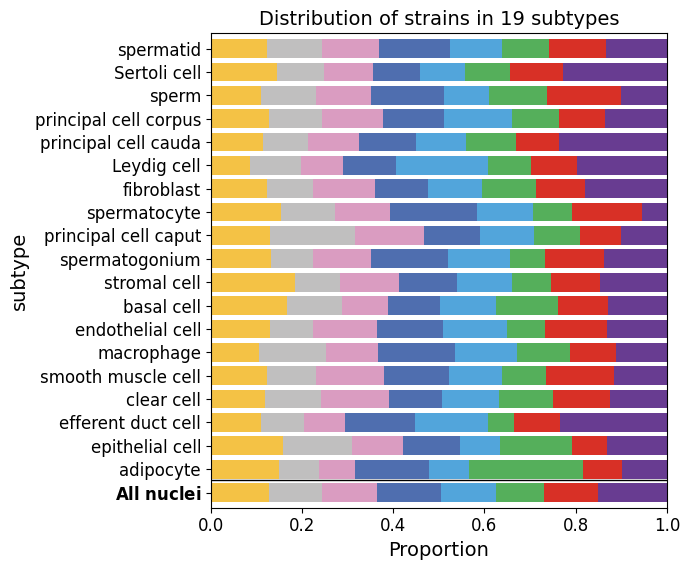

In [217]:
# Copy metadata and append summary row
plot_df = metadata.copy()

# Create a dummy celltype entry for all cells combined
summary_row = plot_df.copy()
summary_row['subtype'] = 'All nuclei'

# Append to the bottom of the dataframe
plot_df = pd.concat([plot_df, summary_row], axis=0)

# Add 'All cells' to the cluster order list (at the end)
ordered_celltypes2 =  ['All nuclei'] + ordered_celltypes[::-1] 

# Now plot!
fig = plt.figure(figsize=(7, 5.8))  # slightly taller
gs = gridspec.GridSpec(1, 1)
ax = fig.add_subplot(gs[0])

stacked_barplot_proportions(
    plot_df,
    cluster_key="subtype",
    var_key="Genotype",
    color_dict=geno_palette,
    cluster_order=ordered_celltypes2,
    annotations=False,
    fsize=None,
    ax=ax
)

ax.axhline(y=0.54, color='black', linestyle='-', linewidth=1)

# Get current y-axis tick labels
yticklabels = [label.get_text() for label in ax.get_yticklabels()]

# Rebuild the list with "All cells" in bold
new_labels = []
for label in yticklabels:
    if label == 'All nuclei':
        new_labels.append(r"$\bf{All\ nuclei}$")  # bold with math text
    else:
        new_labels.append(label)

# Apply new labels
ax.set_yticklabels(new_labels)

n_celltypes = len(ordered_celltypes)
ax.set_title(f"Distribution of strains in {n_celltypes} subtypes", fontsize=14)


plt.tight_layout()

plt.savefig(f"../new_supp/{tissue}_genotype_distribution_across_celltypes_bar.png", dpi=300, bbox_inches='tight', transparent = True)

plt.show()


## Proportion of celltypes across genotypes

/tmp/ipykernel_1504450/257901544.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = obs.groupby([cluster_key, var_key]).size().unstack(fill_value=0)


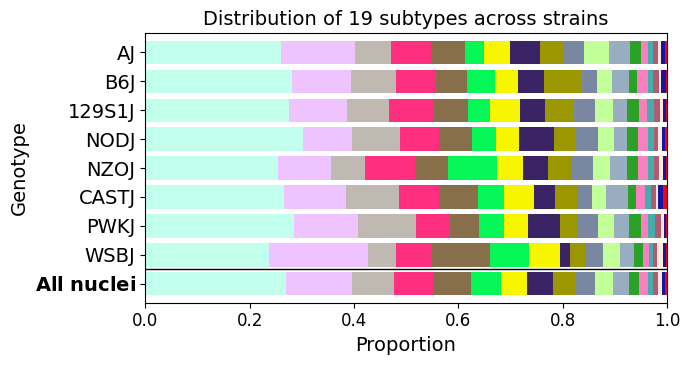

In [218]:
# Copy metadata and append summary row
plot_df = metadata.copy()

# Create a dummy genotype entry for all cells combined
summary_row = plot_df.copy()
summary_row['Genotype'] = 'All nuclei'

# Append to the bottom of the dataframe
plot_df = pd.concat([plot_df, summary_row], axis=0)

# Subtype category setup
plot_df['subtype'] = pd.Categorical(
    plot_df['subtype'],
    categories=ordered_celltypes,
    ordered=True
)

# Genotype category setup, include 'All nuclei' at the end
genotype_order = ["AJ", "B6J", "129S1J", "NODJ", "NZOJ", "CASTJ", "PWKJ", "WSBJ"]
genotype_order_reversed = ['All nuclei'] + genotype_order[::-1]

plot_df['Genotype'] = pd.Categorical(
    plot_df['Genotype'],
    categories=genotype_order_reversed,
    ordered=True
)

# Plot
fig = plt.figure(figsize=(7, 3.75))  # slightly taller
gs = gridspec.GridSpec(1, 1)
ax = fig.add_subplot(gs[0])

stacked_barplot_proportions(
    plot_df,
    cluster_key="Genotype",
    var_key="subtype",
    color_dict=celltype_palette,
    cluster_order=genotype_order_reversed,
    annotations=False,
    fsize=None,
    ax=ax
)

ax.tick_params(axis='y', labelsize=14)

ax.axhline(y=0.52, color='black', linestyle='-', linewidth=1)

# Get current y-axis tick labels
yticklabels = [label.get_text() for label in ax.get_yticklabels()]

# Rebuild the list with "All cells" in bold
new_labels = []
for label in yticklabels:
    if label == 'All nuclei':
        new_labels.append(r"$\bf{All\ nuclei}$")  # bold with math text
    else:
        new_labels.append(label)

# Apply new labels
ax.set_yticklabels(new_labels)


ax.set_title(f"Distribution of {len(ordered_celltypes)} subtypes across strains", fontsize=14)

plt.tight_layout()
plt.savefig(f"../new_supp/{tissue}_celltype_distribution_across_genotypes_bar.png", dpi=300, bbox_inches='tight', transparent = True)
plt.show()


# Liver

/tmp/ipykernel_1504450/9466023.py:4: DtypeWarning: Columns (24,25,35) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata = pd.read_csv(f'/share/crsp/lab/seyedam/share/igvf_pipeline/IGVF_analysis/cellbender_tissues/obs_tables/{tissue}_annotated_metadata.csv')
/tmp/ipykernel_1504450/9466023.py:65: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_info.groupby(['leiden', 'Genotype']).size().rename('geno_total').reset_index()
/tmp/ipykernel_1504450/257901544.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = obs.groupby([cluster_key, var_key]).size().unstack(fill

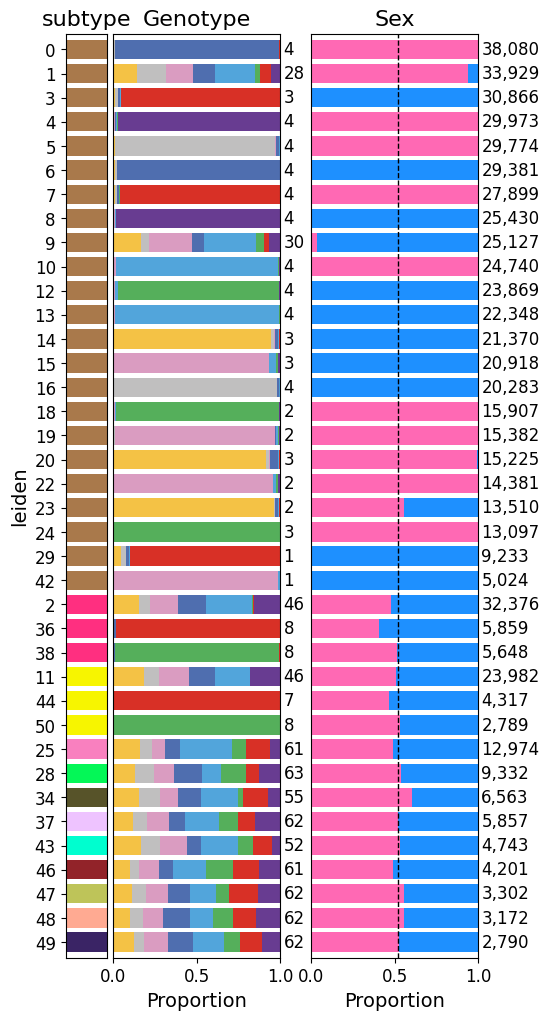

In [413]:
tissue = 'Liver'
random.seed(98) # 19

metadata = pd.read_csv(f'/share/crsp/lab/seyedam/share/igvf_pipeline/IGVF_analysis/cellbender_tissues/obs_tables/{tissue}_annotated_metadata.csv')
metadata = metadata[metadata['subtype'] != 'low quality']

metadata['Genotype'] = pd.Categorical(
    metadata['Genotype'],
    categories=genotype_order,
    ordered=True
)

# === Define palettes ===

# Celltype colors
all_celltypes = metadata['subtype'].unique()
default_palette = sc.pl.palettes.default_102

# Unwanted colors to exclude
excluded_colors = {"#456648", "#549E79", "#6B7900",
                   "#9B9700" ,"#B05B6F","#886F4C",
                  "#7A87A1","#C0B9B2","#99ADC0","#FDE8DC","#C2FFED","#C2FF99"}
default_palette = [c for c in default_palette if c not in excluded_colors]

remaining_celltypes = [ct for ct in all_celltypes if ct not in custom_colors]
remaining_colors = default_palette[:len(remaining_celltypes)]
random.shuffle(remaining_colors)

remaining_dict = dict(zip(remaining_celltypes, remaining_colors))
celltype_palette = {**custom_colors, **remaining_dict}

# Sex & genotype palettes
sex_palette = {'Male': 'dodgerblue', 'Female': 'hotpink'}
genotype_palette = dict(zip(metadata['Genotype'].unique(), sns.color_palette("tab20", n_colors=10)))

# === Cluster ordering by subtype then size ===

df = metadata[['leiden', 'subtype']]
celltype_sizes = df['subtype'].value_counts()
cluster_sizes = df['leiden'].value_counts()
cluster_to_celltype = df.set_index('leiden')['subtype'].to_dict()

from collections import defaultdict
celltype_to_clusters = defaultdict(list)
for cluster, celltype in cluster_to_celltype.items():
    celltype_to_clusters[celltype].append(cluster)

ordered_clusters = []
for celltype in celltype_sizes.index:
    clusters = celltype_to_clusters[celltype]
    clusters_sorted = sorted(clusters, key=lambda c: -cluster_sizes[c])
    ordered_clusters.extend(clusters_sorted)
ordered_clusters = ordered_clusters[::-1]

# === Filter for meaningful mouse contribution by genotype ===

cell_info = metadata[['leiden', 'lab_sample_id', 'Genotype']].copy()

# Cluster-level totals
cluster_totals = cell_info['leiden'].value_counts().rename("cluster_total").reset_index()
cluster_totals.columns = ['leiden', 'cluster_total']

# Genotype totals per cluster
geno_cluster_totals = (
    cell_info.groupby(['leiden', 'Genotype']).size().rename('geno_total').reset_index()
)
geno_cluster_totals = geno_cluster_totals.merge(cluster_totals, on='leiden')
geno_cluster_totals['geno_fraction'] = geno_cluster_totals['geno_total'] / geno_cluster_totals['cluster_total']
significant_genotypes = geno_cluster_totals[geno_cluster_totals['geno_fraction'] >= 0.05]

# Mouse contributions
mouse_counts = (
    cell_info.groupby(['leiden', 'lab_sample_id']).size().rename('mouse_count').reset_index()
)
lab_sample_to_geno = cell_info.drop_duplicates('lab_sample_id').set_index('lab_sample_id')['Genotype']
mouse_counts['Genotype'] = mouse_counts['lab_sample_id'].map(lab_sample_to_geno)

# Merge and compute proportion
merged = pd.merge(
    mouse_counts,
    significant_genotypes[['leiden', 'Genotype', 'geno_total']],
    on=['leiden', 'Genotype'],
    how='inner'
)
merged['proportion'] = merged['mouse_count'] / merged['geno_total']
meaningful = merged[merged['proportion'] >= 0.05]

# Final counts
n_mice_per_cluster = (
    meaningful.groupby('leiden')['lab_sample_id']
    .nunique().reindex(ordered_clusters).fillna(0).astype(int)
)
n_nuclei_per_cluster = metadata['leiden'].value_counts().reindex(ordered_clusters)

# === Plotting ===

fig = plt.figure(figsize=(5, 12))
gs = gridspec.GridSpec(1, 3, width_ratios=[0.5, 2, 2], wspace=0.05)
axs = [fig.add_subplot(gs[i]) for i in range(3)]

# Panel 1: Celltype identity
stacked_barplot_proportions(
    metadata,
    cluster_key="leiden",
    var_key="subtype",
    color_dict=celltype_palette,
    cluster_order=ordered_clusters,
    annotations=False,
    fsize=None,
    ax=axs[0]
)

# Panel 2: Genotype proportions with # mice
stacked_barplot_proportions(
    metadata,
    cluster_key="leiden",
    var_key="Genotype",
    color_dict=geno_palette,
    cluster_order=ordered_clusters,
    annotations=True,
    annotate_vals=n_mice_per_cluster,
    fsize=None,
    ax=axs[1]
)

# Panel 3: Sex proportions with # nuclei
stacked_barplot_proportions(
    metadata,
    cluster_key="leiden",
    var_key="Sex",
    color_dict=sex_palette,
    cluster_order=ordered_clusters,
    annotations=True,
    annotate_vals=n_nuclei_per_cluster,
    fsize=None,
    ax=axs[2]
)

# === Final formatting ===

axs[0].set_xlabel("")
axs[2].set_position([
    axs[2].get_position().x0 + 0.05,
    axs[2].get_position().y0,
    axs[2].get_position().width,
    axs[2].get_position().height
])
axs[0].tick_params(axis='x', bottom=False, labelbottom=False)
axs[1].tick_params(axis='y', length=0)
axs[2].tick_params(axis='y', length=0)
axs[1].set_yticklabels([])
axs[2].set_yticklabels([])
axs[1].set_ylabel("")
axs[2].set_ylabel("")

for ax in axs:
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

female_fraction = (metadata['Sex'] == 'Female').mean()
axs[2].axvline(female_fraction, linestyle='--', color='black', linewidth=1)

plt.tight_layout()
plt.savefig(f"../new_supp/{tissue}_cluster_annotations_barplots.png", dpi=300, bbox_inches='tight')
plt.show()


## Legends

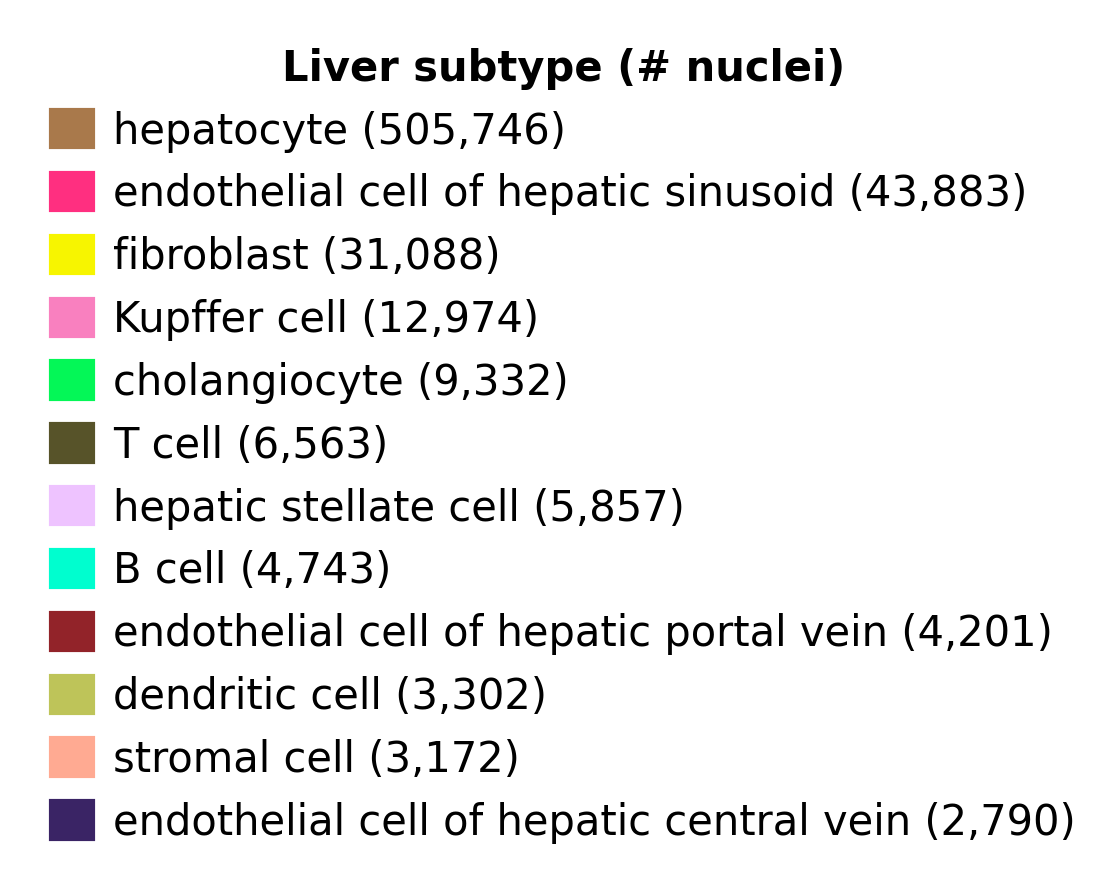

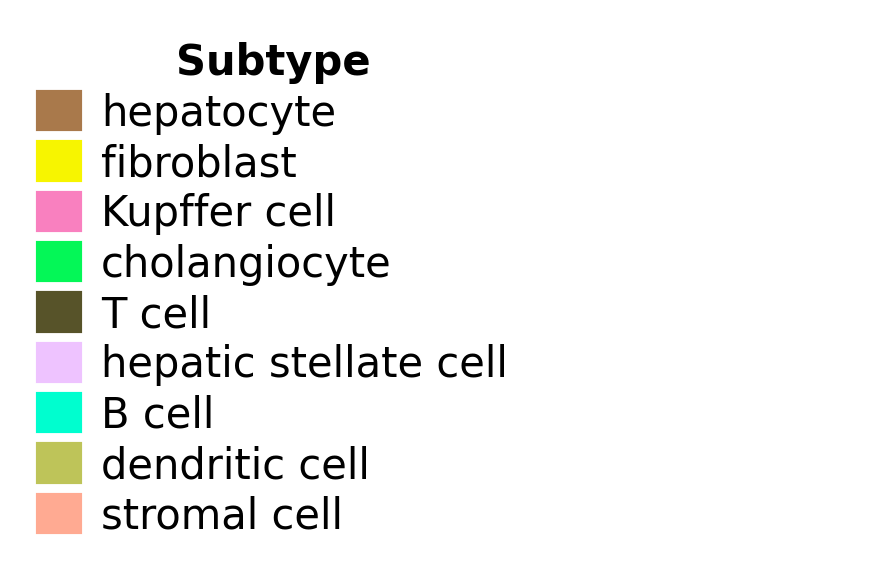

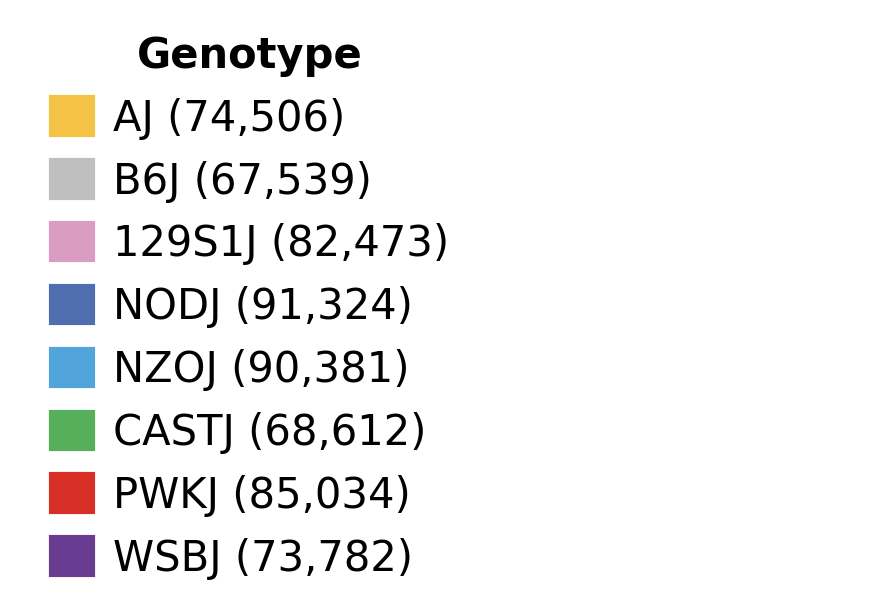

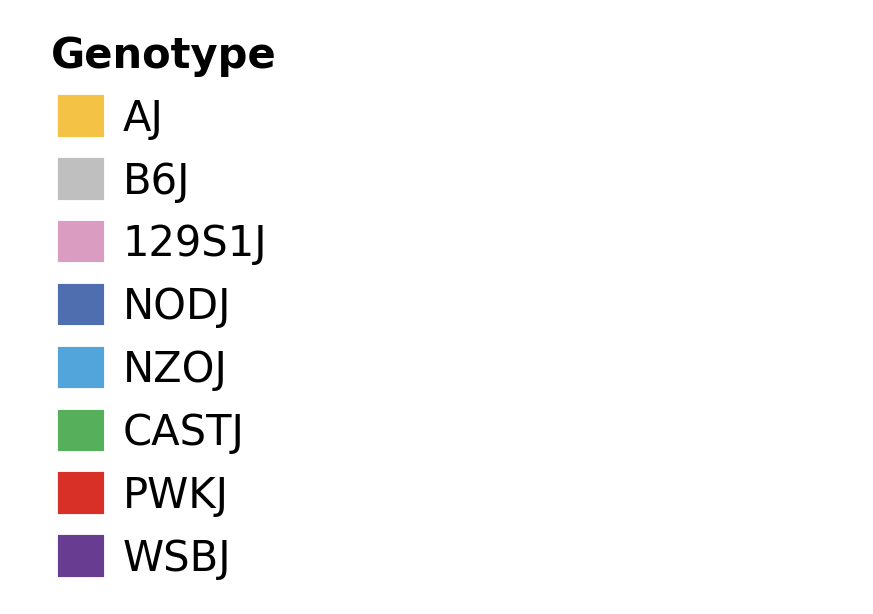

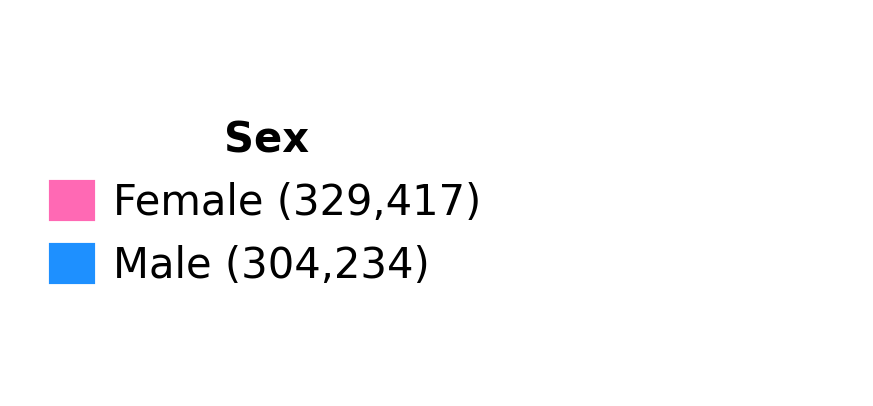

In [415]:
def abbreviate_liver(name, maxlen=35):
    return name if len(name) <= maxlen else name[:maxlen - 3] + "..."


ordered_celltypes = metadata.set_index('leiden').loc[ordered_clusters]['subtype'].values
ordered_celltypes = list(dict.fromkeys(ordered_celltypes))  # remove duplicates, keep order
ordered_celltypes = ordered_celltypes[::-1]  # reverse it

from collections import Counter
celltype_counts = metadata['subtype'].value_counts()

tissue_label_map = {
    "CortexHippocampus": "Cortex/Hippocampus",
    "DiencephalonPituitary": "Diencephalon/Pituitary",
    "GonadsMale": "Male gonads",
    "GonadsFemale": "Female gonads"
}

# Fallback to original if not in map
pretty_tissue = tissue_label_map.get(tissue, tissue)


label = f"{pretty_tissue} subtype (# nuclei)"
fname = f"{tissue}_celltype_legend"

create_standalone_legend(
    color_dict=celltype_palette,
    label=label,
    order=ordered_celltypes,
    counts=celltype_counts,
    ncol=1,
    fname = fname
)


metadata["subtype_abbrev"] = metadata["subtype"].apply(abbreviate_liver)

ordered_celltype_abbrev = [abbreviate_liver(ct) for ct in ordered_celltypes]

celltype_counts = metadata['subtype_abbrev'].value_counts()

label = f"Subtype"
fname = f"{tissue}_simple_celltype_legend"

celltype_palette_abbrev = {
    abbreviate(ct): color for ct, color in celltype_palette.items()
    if abbreviate(ct) in set(ordered_celltype_abbrev)
}

create_standalone_legend_squish(
    color_dict=celltype_palette_abbrev,
    label=label,
    order=ordered_celltype_abbrev,
    ncol=1,
    fname = fname
)


geno_counts = metadata['Genotype'].value_counts()

label = f"Genotype"
fname = f"{tissue}_geno_legend"

create_standalone_legend(
    color_dict=geno_palette,
    label=label,
    order=genotype_order,
    counts=geno_counts,
    ncol=1,
    fname = fname
)


geno_counts = metadata['Genotype'].value_counts()

label = f"Genotype"
fname = f"{tissue}_simple_geno_legend"

create_standalone_legend(
    color_dict=geno_palette,
    label=label,
    order=genotype_order,
    ncol=1,
    fname = fname
)


sex_counts = metadata['Sex'].value_counts()

label = f"Sex"
fname = f"{tissue}_sex_legend"

create_standalone_legend(
    color_dict=sex_palette,
    label=label,
    order=['Female', 'Male'],
    counts=sex_counts,
    ncol=1,
    fname = fname
)

## Proportion of genotypes across celltypes

/tmp/ipykernel_1504450/257901544.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = obs.groupby([cluster_key, var_key]).size().unstack(fill_value=0)


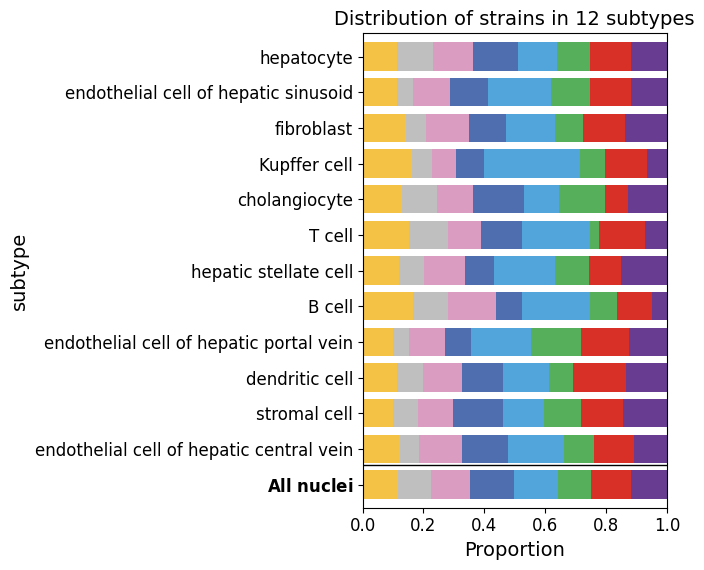

In [410]:
# Copy metadata and append summary row
plot_df = metadata.copy()

# Create a dummy celltype entry for all cells combined
summary_row = plot_df.copy()
summary_row['subtype'] = 'All nuclei'

# Append to the bottom of the dataframe
plot_df = pd.concat([plot_df, summary_row], axis=0)

# Add 'All cells' to the cluster order list (at the end)
ordered_celltypes2 =  ['All nuclei'] + ordered_celltypes[::-1] 

# Now plot!
fig = plt.figure(figsize=(7, 5.8))  # slightly taller
gs = gridspec.GridSpec(1, 1)
ax = fig.add_subplot(gs[0])

stacked_barplot_proportions(
    plot_df,
    cluster_key="subtype",
    var_key="Genotype",
    color_dict=geno_palette,
    cluster_order=ordered_celltypes2,
    annotations=False,
    fsize=None,
    ax=ax
)

ax.axhline(y=0.54, color='black', linestyle='-', linewidth=1)

# Get current y-axis tick labels
yticklabels = [label.get_text() for label in ax.get_yticklabels()]

# Rebuild the list with "All cells" in bold
new_labels = []
for label in yticklabels:
    if label == 'All nuclei':
        new_labels.append(r"$\bf{All\ nuclei}$")  # bold with math text
    else:
        new_labels.append(label)

# Apply new labels
ax.set_yticklabels(new_labels)

n_celltypes = len(ordered_celltypes)
ax.set_title(f"Distribution of strains in {n_celltypes} subtypes", fontsize=14)


plt.tight_layout()

plt.savefig(f"../new_supp/{tissue}_genotype_distribution_across_celltypes_bar.png", dpi=300, bbox_inches='tight', transparent = True)

plt.show()


## Proportion of celltypes across genotypes

/tmp/ipykernel_1504450/257901544.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = obs.groupby([cluster_key, var_key]).size().unstack(fill_value=0)


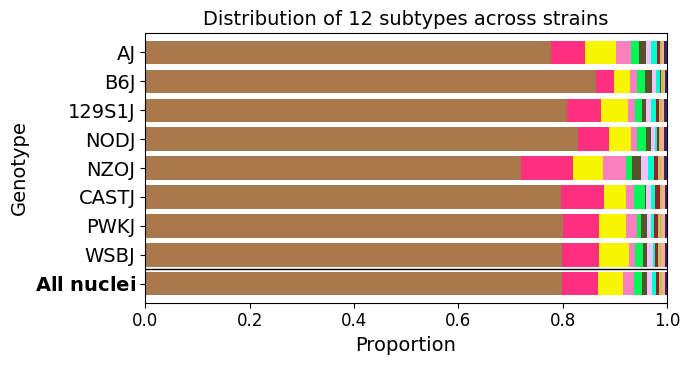

In [411]:
# Copy metadata and append summary row
plot_df = metadata.copy()

# Create a dummy genotype entry for all cells combined
summary_row = plot_df.copy()
summary_row['Genotype'] = 'All nuclei'

# Append to the bottom of the dataframe
plot_df = pd.concat([plot_df, summary_row], axis=0)

# Subtype category setup
plot_df['subtype'] = pd.Categorical(
    plot_df['subtype'],
    categories=ordered_celltypes,
    ordered=True
)

# Genotype category setup, include 'All nuclei' at the end
genotype_order = ["AJ", "B6J", "129S1J", "NODJ", "NZOJ", "CASTJ", "PWKJ", "WSBJ"]
genotype_order_reversed = ['All nuclei'] + genotype_order[::-1]

plot_df['Genotype'] = pd.Categorical(
    plot_df['Genotype'],
    categories=genotype_order_reversed,
    ordered=True
)

# Plot
fig = plt.figure(figsize=(7, 3.75))  # slightly taller
gs = gridspec.GridSpec(1, 1)
ax = fig.add_subplot(gs[0])

stacked_barplot_proportions(
    plot_df,
    cluster_key="Genotype",
    var_key="subtype",
    color_dict=celltype_palette,
    cluster_order=genotype_order_reversed,
    annotations=False,
    fsize=None,
    ax=ax
)

ax.tick_params(axis='y', labelsize=14)

ax.axhline(y=0.52, color='black', linestyle='-', linewidth=1)

# Get current y-axis tick labels
yticklabels = [label.get_text() for label in ax.get_yticklabels()]

# Rebuild the list with "All cells" in bold
new_labels = []
for label in yticklabels:
    if label == 'All nuclei':
        new_labels.append(r"$\bf{All\ nuclei}$")  # bold with math text
    else:
        new_labels.append(label)

# Apply new labels
ax.set_yticklabels(new_labels)


ax.set_title(f"Distribution of {len(ordered_celltypes)} subtypes across strains", fontsize=14)

plt.tight_layout()
plt.savefig(f"../new_supp/{tissue}_celltype_distribution_across_genotypes_bar.png", dpi=300, bbox_inches='tight', transparent = True)
plt.show()


In [412]:
metadata.shape

(633651, 57)

# Female gonads

/tmp/ipykernel_215718/2442451378.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_info.groupby(['leiden_R', 'Genotype']).size().rename('geno_total').reset_index()
/tmp/ipykernel_215718/257901544.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = obs.groupby([cluster_key, var_key]).size().unstack(fill_value=0)
/tmp/ipykernel_215718/257901544.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grou

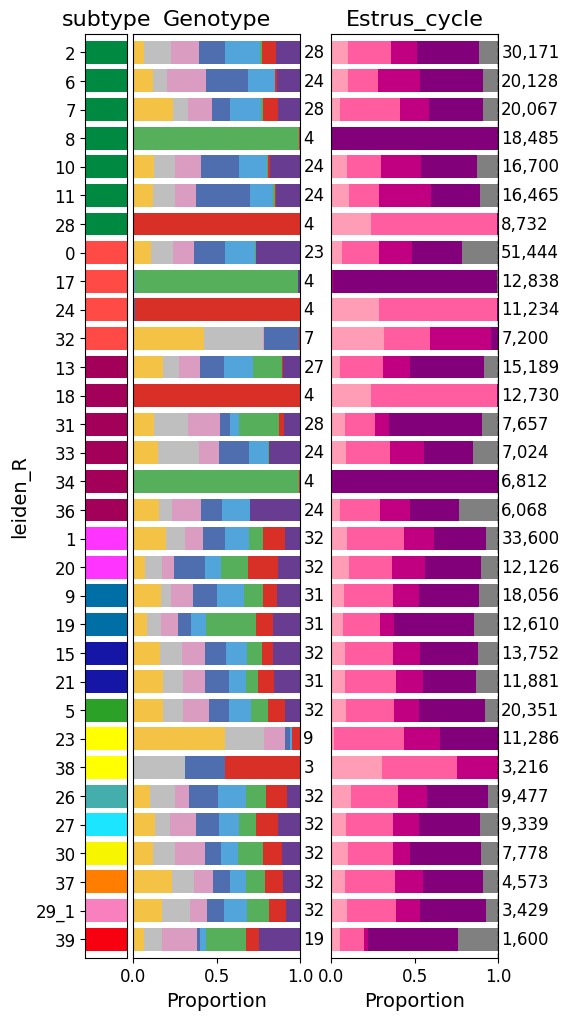

In [18]:
tissue = 'GonadsFemale'
random.seed(114) # 300

metadata = pd.read_csv(f'/share/crsp/lab/seyedam/share/igvf_pipeline/IGVF_analysis/cellbender_tissues/obs_tables/{tissue}_annotated_metadata.csv')
metadata = metadata[metadata['subtype'] != 'low quality']

# Replace NaN with 'NA', then re-categorize
metadata['Estrus_cycle'] = metadata['Estrus_cycle'].astype(str).replace('nan', 'NA')
metadata['Estrus_cycle'] = pd.Categorical(
    metadata['Estrus_cycle'],
    categories=['Proestrus', 'Estrus', 'Metestrus', 'Diestrus', 'NA'],
    ordered=True
)

metadata['Genotype'] = pd.Categorical(
    metadata['Genotype'],
    categories=genotype_order,
    ordered=True
)

# === Define palettes ===

# Celltype colors
all_celltypes = metadata['subtype'].unique()
default_palette = sc.pl.palettes.default_102

# Unwanted colors to exclude
excluded_colors = {"#456648", "#549E79", "#6B7900","#99ADC0","#C2FF99"}
default_palette = [c for c in default_palette if c not in excluded_colors]

remaining_celltypes = [ct for ct in all_celltypes if ct not in custom_colors]
remaining_colors = default_palette[:len(remaining_celltypes)]
random.shuffle(remaining_colors)

remaining_dict = dict(zip(remaining_celltypes, remaining_colors))
celltype_palette = {**custom_colors, **remaining_dict}

# Sex & genotype palettes
sex_palette = {'Male': 'dodgerblue', 'Female': 'hotpink'}
genotype_palette = dict(zip(metadata['Genotype'].unique(), sns.color_palette("tab20", n_colors=10)))

# === Cluster ordering by subtype then size ===

df = metadata[['leiden_R', 'subtype']]
celltype_sizes = df['subtype'].value_counts()
cluster_sizes = df['leiden_R'].value_counts()
cluster_to_celltype = df.set_index('leiden_R')['subtype'].to_dict()

from collections import defaultdict
celltype_to_clusters = defaultdict(list)
for cluster, celltype in cluster_to_celltype.items():
    celltype_to_clusters[celltype].append(cluster)

ordered_clusters = []
for celltype in celltype_sizes.index:
    clusters = celltype_to_clusters[celltype]
    clusters_sorted = sorted(clusters, key=lambda c: -cluster_sizes[c])
    ordered_clusters.extend(clusters_sorted)
ordered_clusters = ordered_clusters[::-1]

# === Filter for meaningful mouse contribution by genotype ===

cell_info = metadata[['leiden_R', 'lab_sample_id', 'Genotype']].copy()

# Cluster-level totals
cluster_totals = cell_info['leiden_R'].value_counts().rename("cluster_total").reset_index()
cluster_totals.columns = ['leiden_R', 'cluster_total']

# Genotype totals per cluster
geno_cluster_totals = (
    cell_info.groupby(['leiden_R', 'Genotype']).size().rename('geno_total').reset_index()
)
geno_cluster_totals = geno_cluster_totals.merge(cluster_totals, on='leiden_R')
geno_cluster_totals['geno_fraction'] = geno_cluster_totals['geno_total'] / geno_cluster_totals['cluster_total']
significant_genotypes = geno_cluster_totals[geno_cluster_totals['geno_fraction'] >= 0.05]

# Mouse contributions
mouse_counts = (
    cell_info.groupby(['leiden_R', 'lab_sample_id']).size().rename('mouse_count').reset_index()
)
lab_sample_to_geno = cell_info.drop_duplicates('lab_sample_id').set_index('lab_sample_id')['Genotype']
mouse_counts['Genotype'] = mouse_counts['lab_sample_id'].map(lab_sample_to_geno)

# Merge and compute proportion
merged = pd.merge(
    mouse_counts,
    significant_genotypes[['leiden_R', 'Genotype', 'geno_total']],
    on=['leiden_R', 'Genotype'],
    how='inner'
)
merged['proportion'] = merged['mouse_count'] / merged['geno_total']
meaningful = merged[merged['proportion'] >= 0.05]

# Final counts
n_mice_per_cluster = (
    meaningful.groupby('leiden_R')['lab_sample_id']
    .nunique().reindex(ordered_clusters).fillna(0).astype(int)
)
n_nuclei_per_cluster = metadata['leiden_R'].value_counts().reindex(ordered_clusters)

# === Plotting ===

fig = plt.figure(figsize=(5, 12))
gs = gridspec.GridSpec(1, 3, width_ratios=[0.5, 2, 2], wspace=0.05)
axs = [fig.add_subplot(gs[i]) for i in range(3)]

# Panel 1: Celltype identity
stacked_barplot_proportions(
    metadata,
    cluster_key="leiden_R",
    var_key="subtype",
    color_dict=celltype_palette,
    cluster_order=ordered_clusters,
    annotations=False,
    fsize=None,
    ax=axs[0]
)

# Panel 2: Genotype proportions with # mice
stacked_barplot_proportions(
    metadata,
    cluster_key="leiden_R",
    var_key="Genotype",
    color_dict=geno_palette,
    cluster_order=ordered_clusters,
    annotations=True,
    annotate_vals=n_mice_per_cluster,
    fsize=None,
    ax=axs[1]
)

# Panel 3: Sex proportions with # nuclei
stacked_barplot_proportions(
    metadata,
    cluster_key="leiden_R",
    var_key="Estrus_cycle",
    color_dict=estrus_palette,
    cluster_order=ordered_clusters,
    annotations=True,
    annotate_vals=n_nuclei_per_cluster,
    fsize=None,
    ax=axs[2]
)

# === Final formatting ===

axs[0].set_xlabel("")
axs[2].set_position([
    axs[2].get_position().x0 + 0.05,
    axs[2].get_position().y0,
    axs[2].get_position().width,
    axs[2].get_position().height
])
axs[0].tick_params(axis='x', bottom=False, labelbottom=False)
axs[1].tick_params(axis='y', length=0)
axs[2].tick_params(axis='y', length=0)
axs[1].set_yticklabels([])
axs[2].set_yticklabels([])
axs[1].set_ylabel("")
axs[2].set_ylabel("")

for ax in axs:
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

female_fraction = (metadata['Sex'] == 'Female').mean()
axs[2].axvline(female_fraction, linestyle='--', color='black', linewidth=1)

plt.tight_layout()
plt.savefig(f"../new_supp/{tissue}_cluster_annotations_barplots.png", dpi=300, bbox_inches='tight', transparent = True)
plt.show()


## Legends

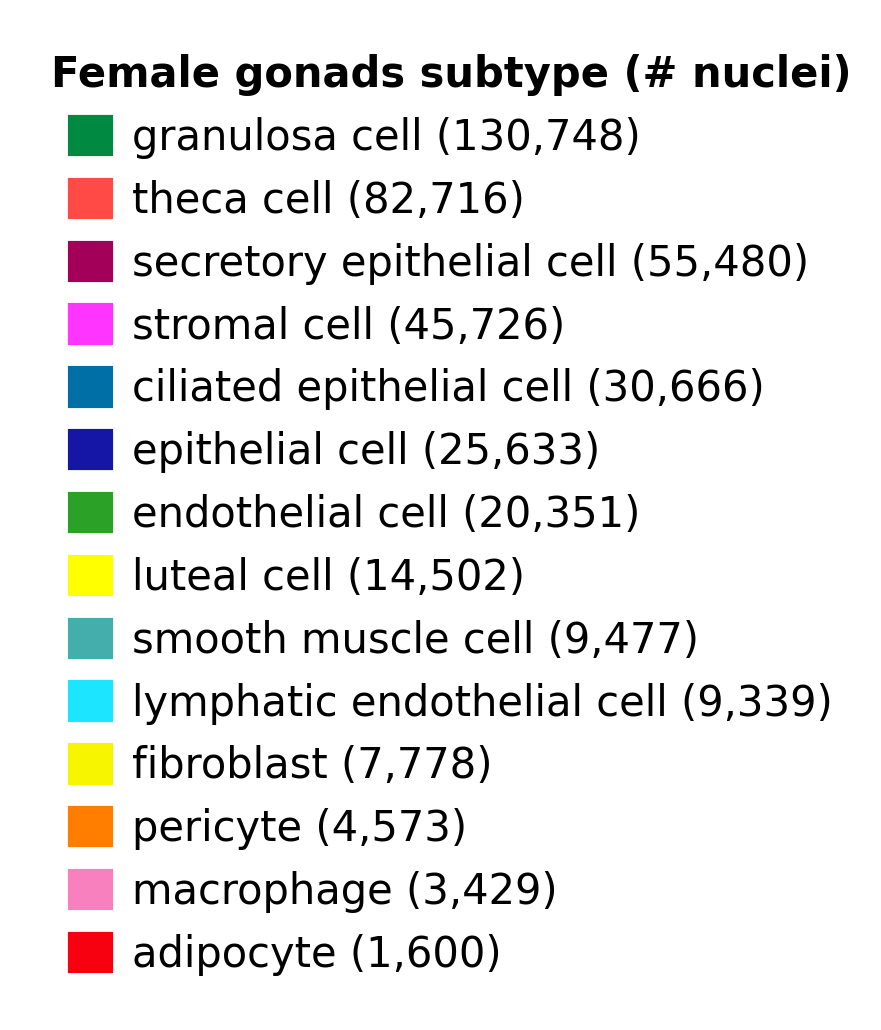

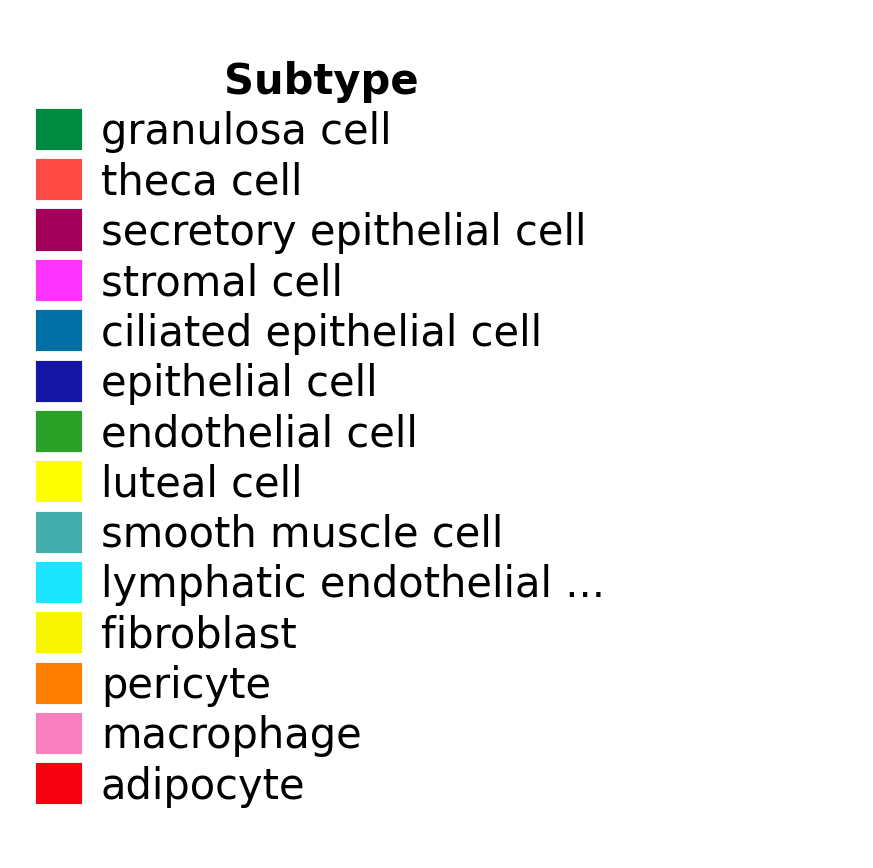

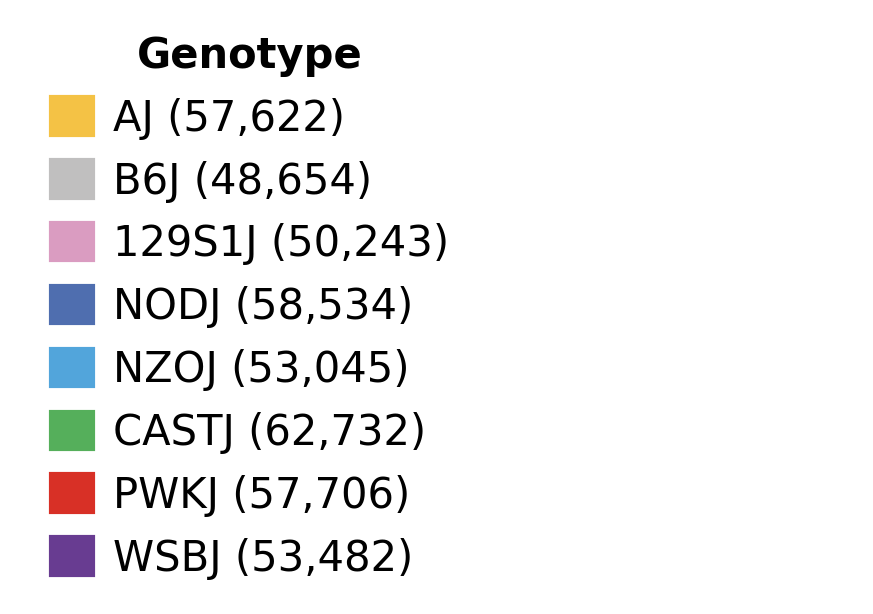

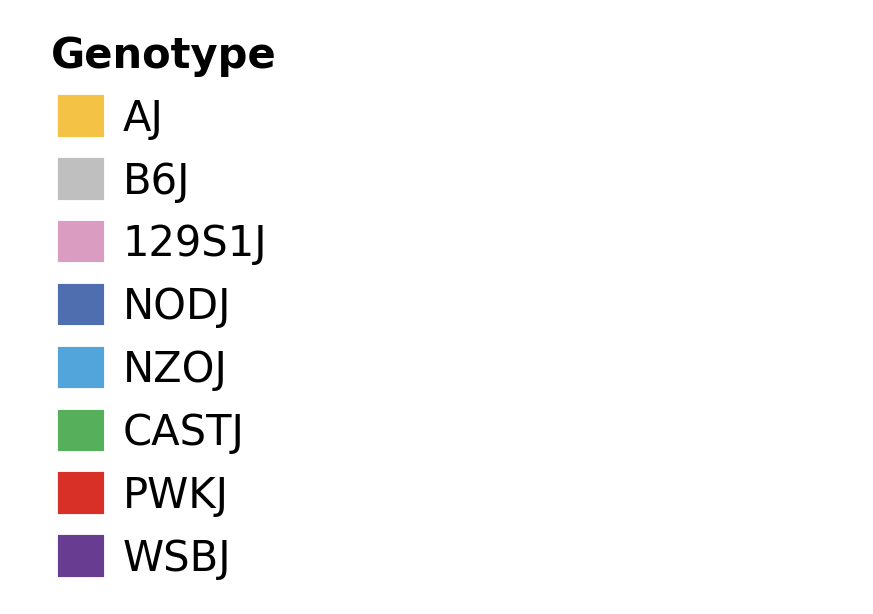

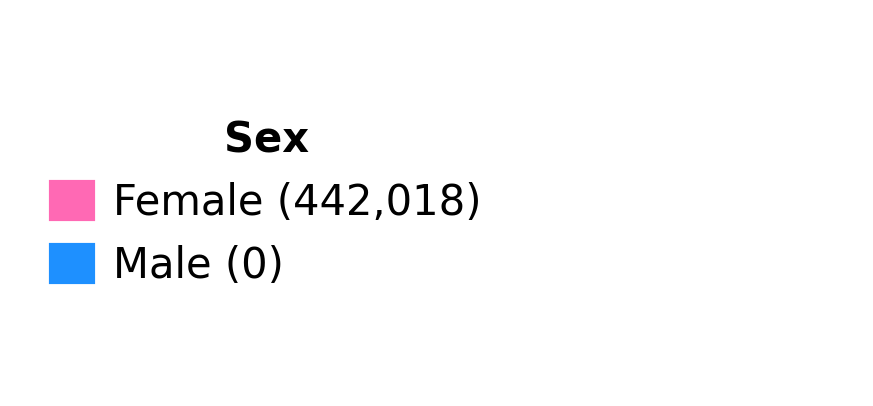

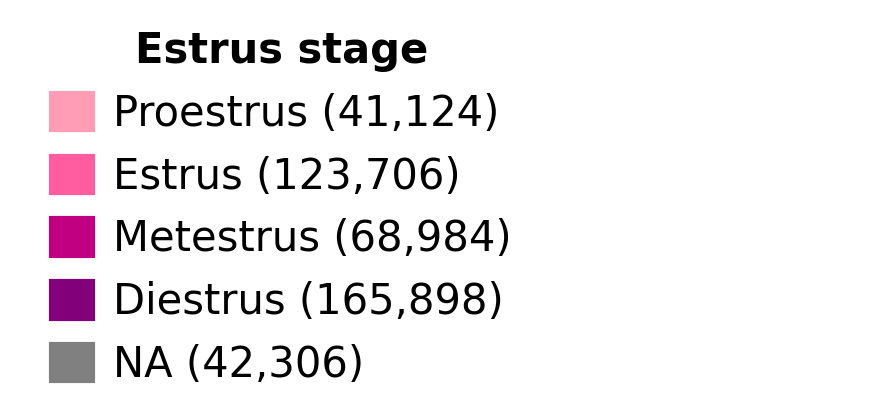

In [19]:
ordered_celltypes = metadata.set_index('leiden_R').loc[ordered_clusters]['subtype'].values
ordered_celltypes = list(dict.fromkeys(ordered_celltypes))  # remove duplicates, keep order
ordered_celltypes = ordered_celltypes[::-1]  # reverse it

from collections import Counter
celltype_counts = metadata['subtype'].value_counts()

tissue_label_map = {
    "CortexHippocampus": "Cortex/Hippocampus",
    "DiencephalonPituitary": "Diencephalon/Pituitary",
    "GonadsMale": "Male gonads",
    "GonadsFemale": "Female gonads"
}

# Fallback to original if not in map
pretty_tissue = tissue_label_map.get(tissue, tissue)


label = f"{pretty_tissue} subtype (# nuclei)"
fname = f"{tissue}_celltype_legend"

create_standalone_legend(
    color_dict=celltype_palette,
    label=label,
    order=ordered_celltypes,
    counts=celltype_counts,
    ncol=1,
    fname = fname
)


metadata["subtype_abbrev"] = metadata["subtype"].apply(abbreviate)

ordered_celltype_abbrev = [abbreviate(ct) for ct in ordered_celltypes]

celltype_counts = metadata['subtype_abbrev'].value_counts()

label = f"Subtype"
fname = f"{tissue}_simple_celltype_legend"

celltype_palette_abbrev = {
    abbreviate(ct): color for ct, color in celltype_palette.items()
    if abbreviate(ct) in set(ordered_celltype_abbrev)
}

create_standalone_legend_squish(
    color_dict=celltype_palette_abbrev,
    label=label,
    order=ordered_celltype_abbrev,
    ncol=1,
    fname = fname
)


geno_counts = metadata['Genotype'].value_counts()

label = f"Genotype"
fname = f"{tissue}_geno_legend"

create_standalone_legend(
    color_dict=geno_palette,
    label=label,
    order=genotype_order,
    counts=geno_counts,
    ncol=1,
    fname = fname
)


geno_counts = metadata['Genotype'].value_counts()

label = f"Genotype"
fname = f"{tissue}_simple_geno_legend"

create_standalone_legend(
    color_dict=geno_palette,
    label=label,
    order=genotype_order,
    ncol=1,
    fname = fname
)


sex_counts = metadata['Sex'].value_counts()

label = f"Sex"
fname = f"{tissue}_sex_legend"

create_standalone_legend(
    color_dict=sex_palette,
    label=label,
    order=['Female', 'Male'],
    counts=sex_counts,
    ncol=1,
    fname = fname
)



estrus_counts = metadata['Estrus_cycle'].value_counts()

label = f"Estrus stage"
fname = f"{tissue}_estrus_legend"

create_standalone_legend(
    color_dict=estrus_palette,
    label=label,
    order=['Proestrus', 'Estrus', 'Metestrus', 'Diestrus', 'NA'],
    counts=estrus_counts,
    ncol=1,
    fname = fname
)

In [14]:
estrus_palette

{'NA': 'grey',
 'Diestrus': '#83007b',
 'Estrus': '#ff5d9f',
 'Metestrus': '#c00081',
 'Proestrus': '#ff9db6'}

## Proportion of genotypes across celltypes

/tmp/ipykernel_215718/257901544.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = obs.groupby([cluster_key, var_key]).size().unstack(fill_value=0)


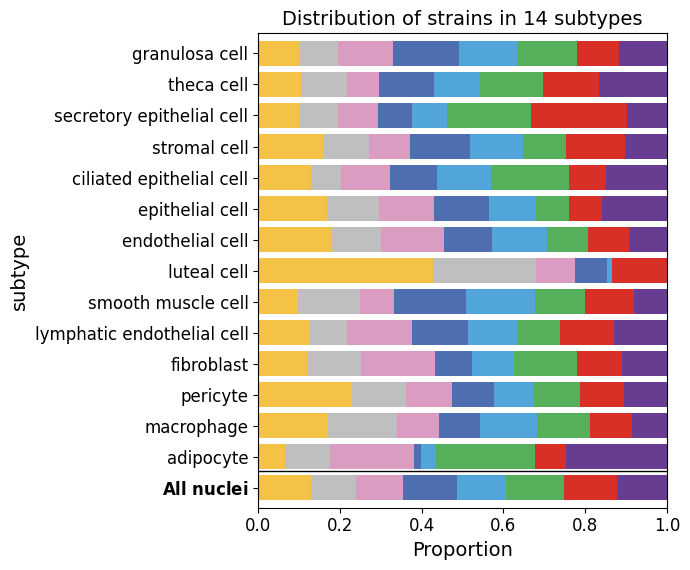

In [15]:
# Copy metadata and append summary row
plot_df = metadata.copy()

# Create a dummy celltype entry for all cells combined
summary_row = plot_df.copy()
summary_row['subtype'] = 'All nuclei'

# Append to the bottom of the dataframe
plot_df = pd.concat([plot_df, summary_row], axis=0)

# Add 'All cells' to the cluster order list (at the end)
ordered_celltypes2 =  ['All nuclei'] + ordered_celltypes[::-1] 

# Now plot!
fig = plt.figure(figsize=(7, 5.8))  # slightly taller
gs = gridspec.GridSpec(1, 1)
ax = fig.add_subplot(gs[0])

stacked_barplot_proportions(
    plot_df,
    cluster_key="subtype",
    var_key="Genotype",
    color_dict=geno_palette,
    cluster_order=ordered_celltypes2,
    annotations=False,
    fsize=None,
    ax=ax
)

ax.axhline(y=0.54, color='black', linestyle='-', linewidth=1)

# Get current y-axis tick labels
yticklabels = [label.get_text() for label in ax.get_yticklabels()]

# Rebuild the list with "All cells" in bold
new_labels = []
for label in yticklabels:
    if label == 'All nuclei':
        new_labels.append(r"$\bf{All\ nuclei}$")  # bold with math text
    else:
        new_labels.append(label)

# Apply new labels
ax.set_yticklabels(new_labels)

n_celltypes = len(ordered_celltypes)
ax.set_title(f"Distribution of strains in {n_celltypes} subtypes", fontsize=14)


plt.tight_layout()

plt.savefig(f"../new_supp/{tissue}_genotype_distribution_across_celltypes_bar.png", dpi=300, bbox_inches='tight', transparent = True)

plt.show()


## Proportion of celltypes across genotypes

/tmp/ipykernel_215718/257901544.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = obs.groupby([cluster_key, var_key]).size().unstack(fill_value=0)


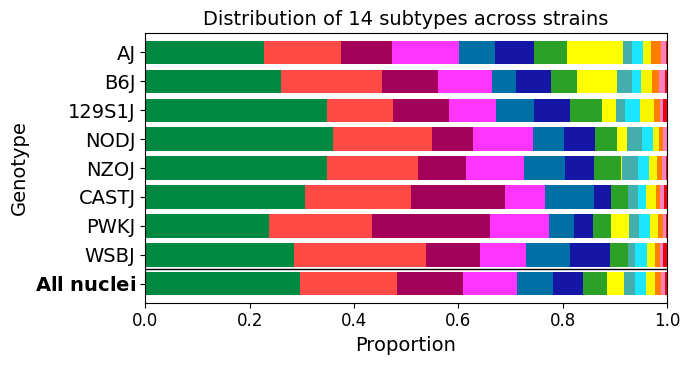

In [16]:
# Copy metadata and append summary row
plot_df = metadata.copy()

# Create a dummy genotype entry for all cells combined
summary_row = plot_df.copy()
summary_row['Genotype'] = 'All nuclei'

# Append to the bottom of the dataframe
plot_df = pd.concat([plot_df, summary_row], axis=0)

# Subtype category setup
plot_df['subtype'] = pd.Categorical(
    plot_df['subtype'],
    categories=ordered_celltypes,
    ordered=True
)

# Genotype category setup, include 'All nuclei' at the end
genotype_order = ["AJ", "B6J", "129S1J", "NODJ", "NZOJ", "CASTJ", "PWKJ", "WSBJ"]
genotype_order_reversed = ['All nuclei'] + genotype_order[::-1]

plot_df['Genotype'] = pd.Categorical(
    plot_df['Genotype'],
    categories=genotype_order_reversed,
    ordered=True
)

# Plot
fig = plt.figure(figsize=(7, 3.75))  # slightly taller
gs = gridspec.GridSpec(1, 1)
ax = fig.add_subplot(gs[0])

stacked_barplot_proportions(
    plot_df,
    cluster_key="Genotype",
    var_key="subtype",
    color_dict=celltype_palette,
    cluster_order=genotype_order_reversed,
    annotations=False,
    fsize=None,
    ax=ax
)

ax.tick_params(axis='y', labelsize=14)

ax.axhline(y=0.52, color='black', linestyle='-', linewidth=1)

# Get current y-axis tick labels
yticklabels = [label.get_text() for label in ax.get_yticklabels()]

# Rebuild the list with "All cells" in bold
new_labels = []
for label in yticklabels:
    if label == 'All nuclei':
        new_labels.append(r"$\bf{All\ nuclei}$")  # bold with math text
    else:
        new_labels.append(label)

# Apply new labels
ax.set_yticklabels(new_labels)


ax.set_title(f"Distribution of {len(ordered_celltypes)} subtypes across strains", fontsize=14)

plt.tight_layout()
plt.savefig(f"../new_supp/{tissue}_celltype_distribution_across_genotypes_bar.png", dpi=300, bbox_inches='tight', transparent = True)
plt.show()


In [17]:
metadata.shape

(442018, 58)

# Gastrocnemius

/tmp/ipykernel_656/3520916744.py:4: DtypeWarning: Columns (49) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata = pd.read_csv(f'/share/crsp/lab/seyedam/share/igvf_pipeline/IGVF_analysis/cellbender_tissues/obs_tables/{tissue}_annotated_metadata.csv')


{'astrocyte': '#16ffce', 'GABAergic interneuron': '#954b03', 'Pvalb+ GABAergic cortical interneuron': '#e5bc9c', 'Sst+ GABAergic cortical interneuron': '#603004', 'Vip+ GABAergic cortical interneuron': '#bd997a', 'Lamp5+ GABAergic cortical interneuron': '#3e1c01', 'medium spiny neuron': '#3282fd', 'neuroblast': '#fdb363', 'glutamatergic neuron': '#a777f1', 'hippocampal CA1-3 neuron': '#846a88', 'oligodendrocyte precursor cell': '#f1f79c', 'mature oligodendrocyte': '#e9bc00', 'committed oligodendrocyte precursor': '#f2d77c', 'microglial cell': '#f980bf', 'macrophage': '#f980bf', 'Kupffer cell': '#f980bf', 'endothelial cell': '#2ca128', 'smooth muscle cell': '#44aeac', 'pericyte': '#ff7e00', 'vascular leptomeningeal cell': '#e41b1d', 'barrier cell': '#ed6357', 'epithelial cell': '#1516a6', 'ependymal cell': '#b10da1', 'zona fasciculata': '#f8a001', 'ventricular cardiac myocyte': '#f87a6c', 'fibroblast': '#f7f500', 'adipocyte': '#f7000f', 'hepatocyte': '#a9794b', 'type IIb myonucleus': '#

/tmp/ipykernel_656/3520916744.py:68: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_info.groupby(['leiden_R', 'Genotype']).size().rename('geno_total').reset_index()
/tmp/ipykernel_656/257901544.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = obs.groupby([cluster_key, var_key]).size().unstack(fill_value=0)
/tmp/ipykernel_656/3520916744.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


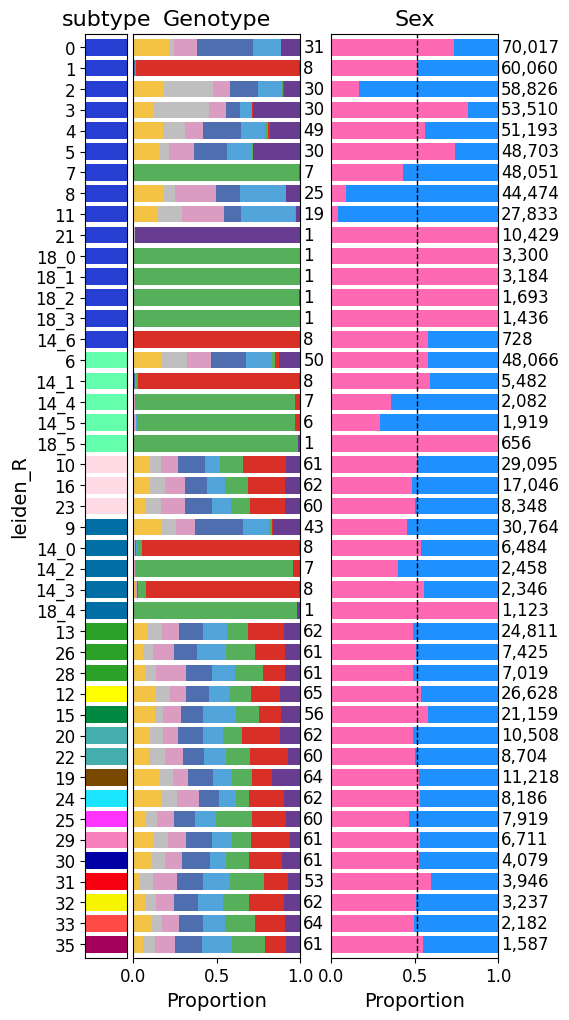

In [4]:
tissue = 'Gastrocnemius'
random.seed(24)

metadata = pd.read_csv(f'/share/crsp/lab/seyedam/share/igvf_pipeline/IGVF_analysis/cellbender_tissues/obs_tables/{tissue}_annotated_metadata.csv')
metadata = metadata[metadata['subtype'] != 'low quality']
metadata['leiden_R'] = metadata['leiden_R'].astype(str)

metadata['Genotype'] = pd.Categorical(
    metadata['Genotype'],
    categories=genotype_order,
    ordered=True
)

# === Define palettes ===

# Celltype colors
all_celltypes = metadata['subtype'].unique()
default_palette = sc.pl.palettes.default_102

# Unwanted colors to exclude
excluded_colors = {"#456648", "#549E79", "#6B7900","#575329","#BEC459"
                   "#9B9700" ,"#B05B6F","#886F4C",
                  "#7A87A1","#C0B9B2","#99ADC0","#FDE8DC","#C2FFED","#C2FF99"}

default_palette = [c for c in default_palette if c not in excluded_colors]

remaining_celltypes = [ct for ct in all_celltypes if ct not in custom_colors]
remaining_colors = default_palette[:len(remaining_celltypes)]
random.shuffle(remaining_colors)

remaining_dict = dict(zip(remaining_celltypes, remaining_colors))
celltype_palette = {**custom_colors, **remaining_dict}
print(celltype_palette)

# Sex & genotype palettes
sex_palette = {'Male': 'dodgerblue', 'Female': 'hotpink'}
genotype_palette = dict(zip(metadata['Genotype'].unique(), sns.color_palette("tab20", n_colors=10)))

# === Cluster ordering by subtype then size ===

df = metadata[['leiden_R', 'subtype']]
celltype_sizes = df['subtype'].value_counts()
cluster_sizes = df['leiden_R'].value_counts()
cluster_to_celltype = df.set_index('leiden_R')['subtype'].to_dict()

from collections import defaultdict
celltype_to_clusters = defaultdict(list)
for cluster, celltype in cluster_to_celltype.items():
    celltype_to_clusters[celltype].append(cluster)

ordered_clusters = []
for celltype in celltype_sizes.index:
    clusters = celltype_to_clusters[celltype]
    clusters_sorted = sorted(clusters, key=lambda c: -cluster_sizes[c])
    ordered_clusters.extend(clusters_sorted)
ordered_clusters = ordered_clusters[::-1]

# === Filter for meaningful mouse contribution by genotype ===

cell_info = metadata[['leiden_R', 'lab_sample_id', 'Genotype']].copy()

# Cluster-level totals
cluster_totals = cell_info['leiden_R'].value_counts().rename("cluster_total").reset_index()
cluster_totals.columns = ['leiden_R', 'cluster_total']

# Genotype totals per cluster
geno_cluster_totals = (
    cell_info.groupby(['leiden_R', 'Genotype']).size().rename('geno_total').reset_index()
)
geno_cluster_totals = geno_cluster_totals.merge(cluster_totals, on='leiden_R')
geno_cluster_totals['geno_fraction'] = geno_cluster_totals['geno_total'] / geno_cluster_totals['cluster_total']
significant_genotypes = geno_cluster_totals[geno_cluster_totals['geno_fraction'] >= 0.05]

# Mouse contributions
mouse_counts = (
    cell_info.groupby(['leiden_R', 'lab_sample_id']).size().rename('mouse_count').reset_index()
)
lab_sample_to_geno = cell_info.drop_duplicates('lab_sample_id').set_index('lab_sample_id')['Genotype']
mouse_counts['Genotype'] = mouse_counts['lab_sample_id'].map(lab_sample_to_geno)

# Merge and compute proportion
merged = pd.merge(
    mouse_counts,
    significant_genotypes[['leiden_R', 'Genotype', 'geno_total']],
    on=['leiden_R', 'Genotype'],
    how='inner'
)
merged['proportion'] = merged['mouse_count'] / merged['geno_total']
meaningful = merged[merged['proportion'] >= 0.05]

# Final counts
n_mice_per_cluster = (
    meaningful.groupby('leiden_R')['lab_sample_id']
    .nunique().reindex(ordered_clusters).fillna(0).astype(int)
)
n_nuclei_per_cluster = metadata['leiden_R'].value_counts().reindex(ordered_clusters)

# === Plotting ===

fig = plt.figure(figsize=(5, 12))
gs = gridspec.GridSpec(1, 3, width_ratios=[0.5, 2, 2], wspace=0.05)
axs = [fig.add_subplot(gs[i]) for i in range(3)]

# Panel 1: Celltype identity
stacked_barplot_proportions(
    metadata,
    cluster_key="leiden_R",
    var_key="subtype",
    color_dict=celltype_palette,
    cluster_order=ordered_clusters,
    annotations=False,
    fsize=None,
    ax=axs[0]
)

# Panel 2: Genotype proportions with # mice
stacked_barplot_proportions(
    metadata,
    cluster_key="leiden_R",
    var_key="Genotype",
    color_dict=geno_palette,
    cluster_order=ordered_clusters,
    annotations=True,
    annotate_vals=n_mice_per_cluster,
    fsize=None,
    ax=axs[1]
)

# Panel 3: Sex proportions with # nuclei
stacked_barplot_proportions(
    metadata,
    cluster_key="leiden_R",
    var_key="Sex",
    color_dict=sex_palette,
    cluster_order=ordered_clusters,
    annotations=True,
    annotate_vals=n_nuclei_per_cluster,
    fsize=None,
    ax=axs[2]
)

# === Final formatting ===

axs[0].set_xlabel("")
axs[2].set_position([
    axs[2].get_position().x0 + 0.05,
    axs[2].get_position().y0,
    axs[2].get_position().width,
    axs[2].get_position().height
])
axs[0].tick_params(axis='x', bottom=False, labelbottom=False)
axs[1].tick_params(axis='y', length=0)
axs[2].tick_params(axis='y', length=0)
axs[1].set_yticklabels([])
axs[2].set_yticklabels([])
axs[1].set_ylabel("")
axs[2].set_ylabel("")

for ax in axs:
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

female_fraction = (metadata['Sex'] == 'Female').mean()
axs[2].axvline(female_fraction, linestyle='--', color='black', linewidth=1)

plt.tight_layout()
plt.savefig(f"../new_supp/{tissue}_cluster_annotations_barplots.png", dpi=300, bbox_inches='tight', transparent = True)
plt.show()


In [429]:
metadata.shape

(794625, 55)

## Legends

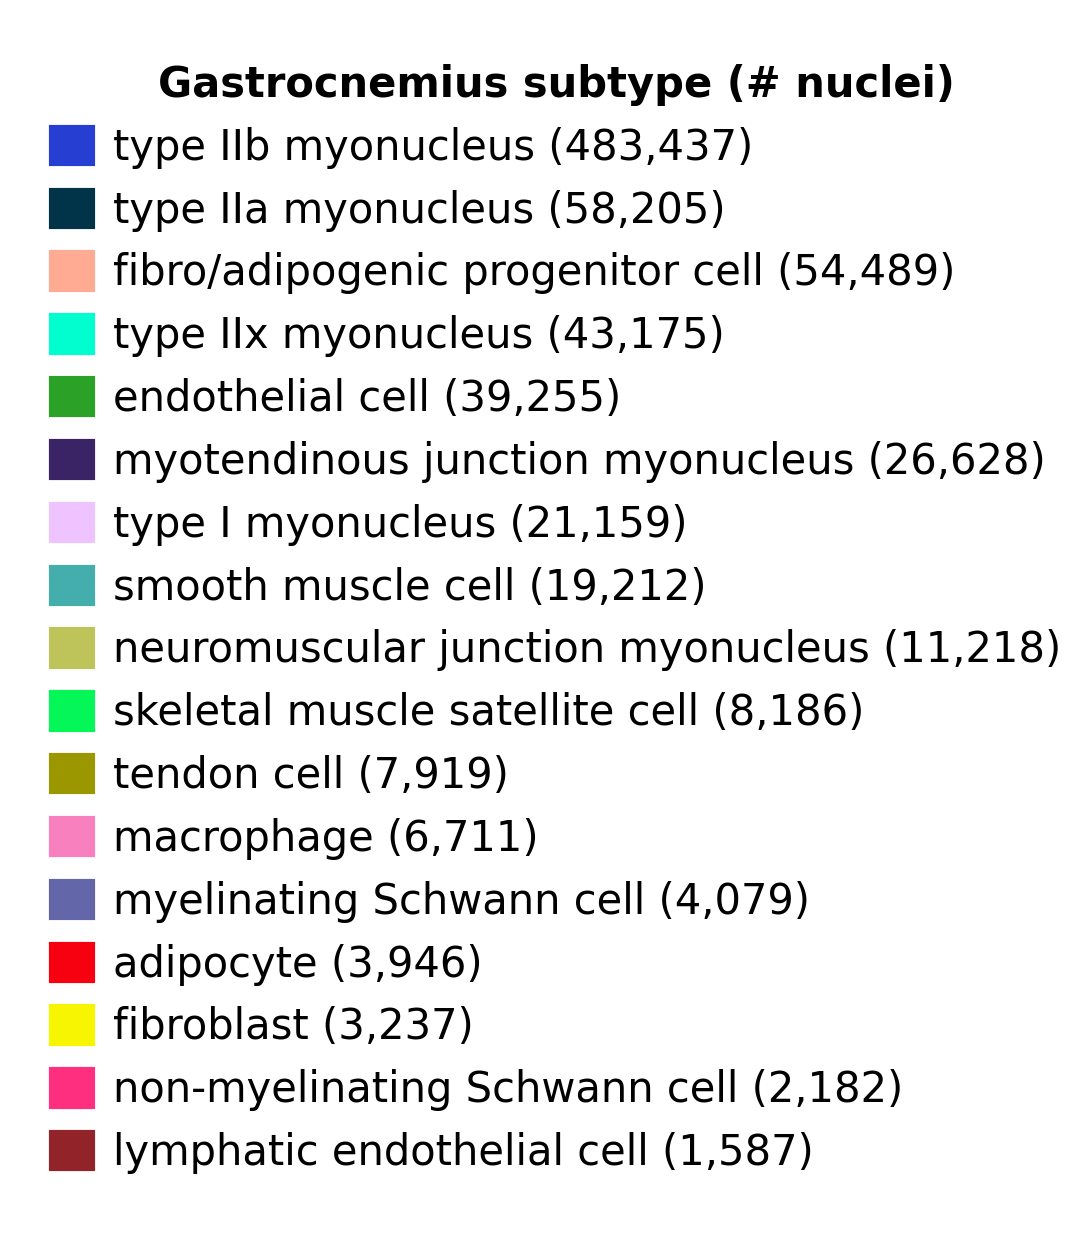

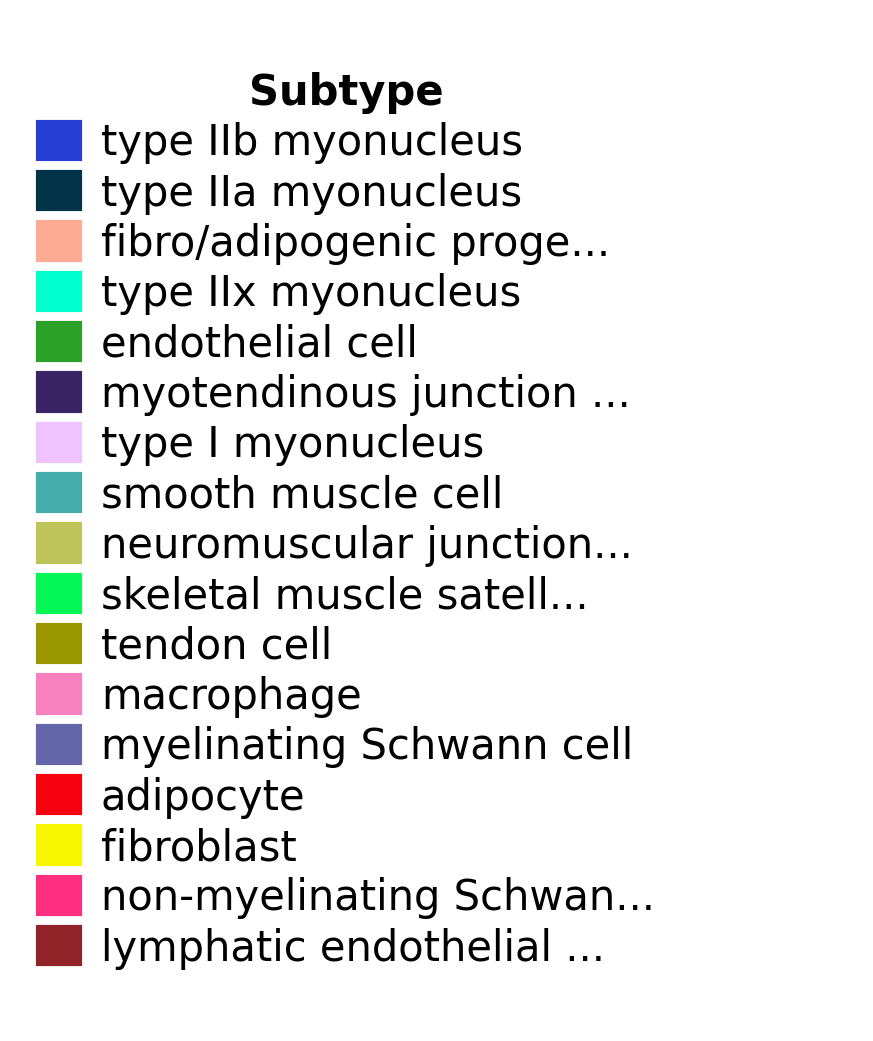

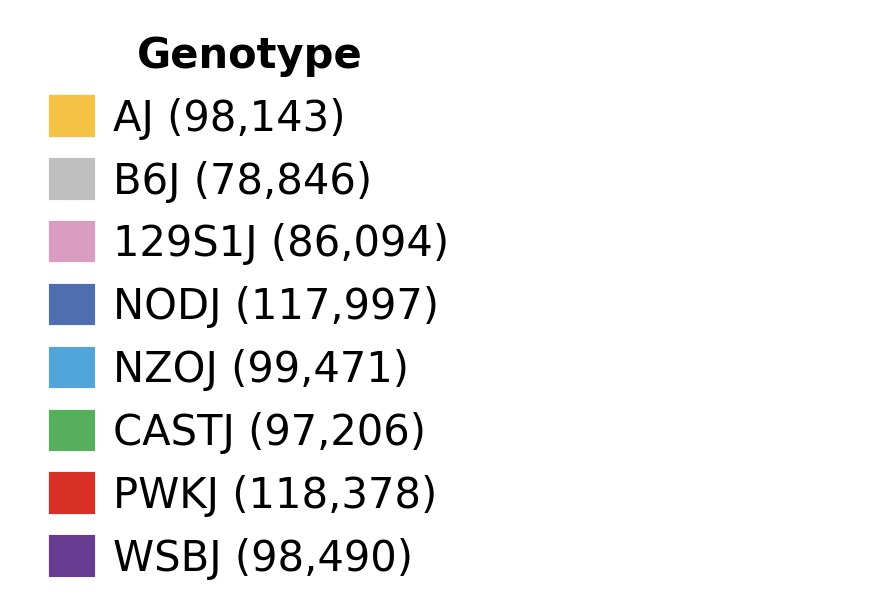

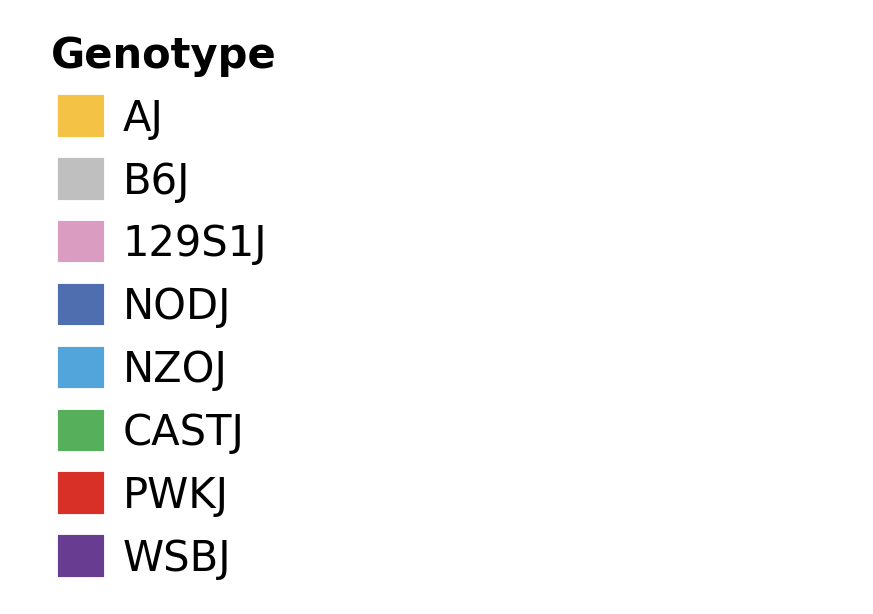

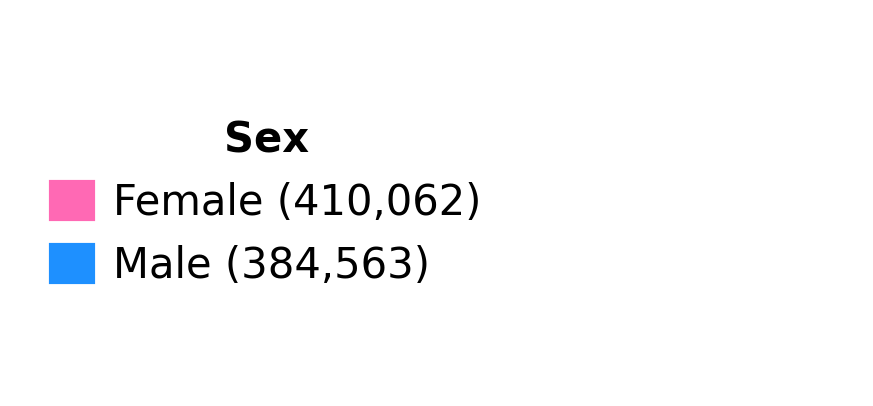

In [430]:
ordered_celltypes = metadata.set_index('leiden_R').loc[ordered_clusters]['subtype'].values
ordered_celltypes = list(dict.fromkeys(ordered_celltypes))  # remove duplicates, keep order
ordered_celltypes = ordered_celltypes[::-1]  # reverse it

from collections import Counter
celltype_counts = metadata['subtype'].value_counts()

tissue_label_map = {
    "CortexHippocampus": "Cortex/Hippocampus",
    "DiencephalonPituitary": "Diencephalon/Pituitary",
    "GonadsMale": "Male gonads",
    "GonadsFemale": "Female gonads"
}

# Fallback to original if not in map
pretty_tissue = tissue_label_map.get(tissue, tissue)


label = f"{pretty_tissue} subtype (# nuclei)"
fname = f"{tissue}_celltype_legend"

create_standalone_legend(
    color_dict=celltype_palette,
    label=label,
    order=ordered_celltypes,
    counts=celltype_counts,
    ncol=1,
    fname = fname
)


metadata["subtype_abbrev"] = metadata["subtype"].apply(abbreviate)

ordered_celltype_abbrev = [abbreviate(ct) for ct in ordered_celltypes]

celltype_counts = metadata['subtype_abbrev'].value_counts()

label = f"Subtype"
fname = f"{tissue}_simple_celltype_legend"

celltype_palette_abbrev = {
    abbreviate(ct): color for ct, color in celltype_palette.items()
    if abbreviate(ct) in set(ordered_celltype_abbrev)
}

create_standalone_legend_squish(
    color_dict=celltype_palette_abbrev,
    label=label,
    order=ordered_celltype_abbrev,
    ncol=1,
    fname = fname
)


geno_counts = metadata['Genotype'].value_counts()

label = f"Genotype"
fname = f"{tissue}_geno_legend"

create_standalone_legend(
    color_dict=geno_palette,
    label=label,
    order=genotype_order,
    counts=geno_counts,
    ncol=1,
    fname = fname
)


geno_counts = metadata['Genotype'].value_counts()

label = f"Genotype"
fname = f"{tissue}_simple_geno_legend"

create_standalone_legend(
    color_dict=geno_palette,
    label=label,
    order=genotype_order,
    ncol=1,
    fname = fname
)


sex_counts = metadata['Sex'].value_counts()

label = f"Sex"
fname = f"{tissue}_sex_legend"

create_standalone_legend(
    color_dict=sex_palette,
    label=label,
    order=['Female', 'Male'],
    counts=sex_counts,
    ncol=1,
    fname = fname
)

## Proportion of genotypes across celltypes

/tmp/ipykernel_1504450/257901544.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = obs.groupby([cluster_key, var_key]).size().unstack(fill_value=0)


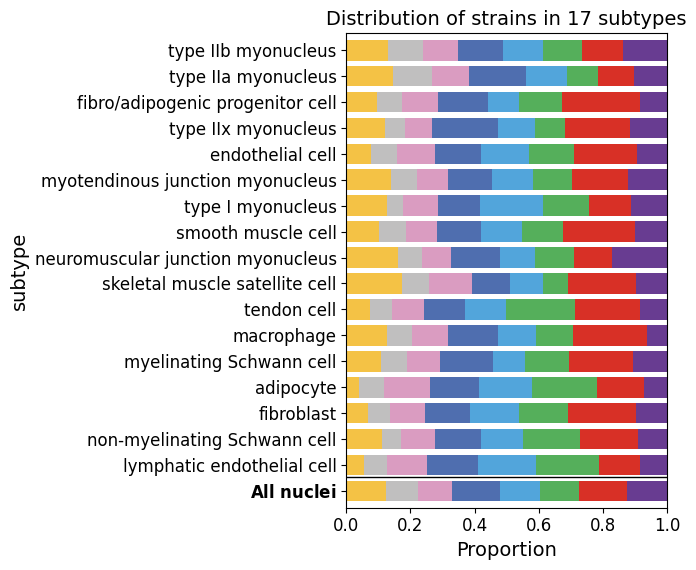

In [431]:
# Copy metadata and append summary row
plot_df = metadata.copy()

# Create a dummy celltype entry for all cells combined
summary_row = plot_df.copy()
summary_row['subtype'] = 'All nuclei'

# Append to the bottom of the dataframe
plot_df = pd.concat([plot_df, summary_row], axis=0)

# Add 'All cells' to the cluster order list (at the end)
ordered_celltypes2 =  ['All nuclei'] + ordered_celltypes[::-1] 

# Now plot!
fig = plt.figure(figsize=(7, 5.8))  # slightly taller
gs = gridspec.GridSpec(1, 1)
ax = fig.add_subplot(gs[0])

stacked_barplot_proportions(
    plot_df,
    cluster_key="subtype",
    var_key="Genotype",
    color_dict=geno_palette,
    cluster_order=ordered_celltypes2,
    annotations=False,
    fsize=None,
    ax=ax
)

ax.axhline(y=0.54, color='black', linestyle='-', linewidth=1)

# Get current y-axis tick labels
yticklabels = [label.get_text() for label in ax.get_yticklabels()]

# Rebuild the list with "All cells" in bold
new_labels = []
for label in yticklabels:
    if label == 'All nuclei':
        new_labels.append(r"$\bf{All\ nuclei}$")  # bold with math text
    else:
        new_labels.append(label)

# Apply new labels
ax.set_yticklabels(new_labels)

n_celltypes = len(ordered_celltypes)
ax.set_title(f"Distribution of strains in {n_celltypes} subtypes", fontsize=14)


plt.tight_layout()

plt.savefig(f"../new_supp/{tissue}_genotype_distribution_across_celltypes_bar.png", dpi=300, bbox_inches='tight', transparent = True)

plt.show()


## Proportion of celltypes across genotypes

/tmp/ipykernel_1504450/257901544.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = obs.groupby([cluster_key, var_key]).size().unstack(fill_value=0)


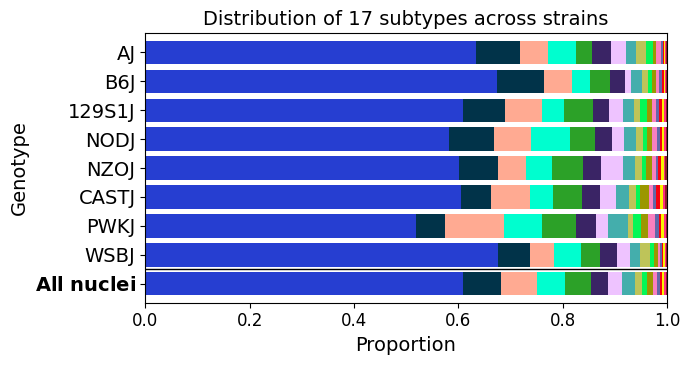

In [432]:
# Copy metadata and append summary row
plot_df = metadata.copy()

# Create a dummy genotype entry for all cells combined
summary_row = plot_df.copy()
summary_row['Genotype'] = 'All nuclei'

# Append to the bottom of the dataframe
plot_df = pd.concat([plot_df, summary_row], axis=0)

# Subtype category setup
plot_df['subtype'] = pd.Categorical(
    plot_df['subtype'],
    categories=ordered_celltypes,
    ordered=True
)

# Genotype category setup, include 'All nuclei' at the end
genotype_order = ["AJ", "B6J", "129S1J", "NODJ", "NZOJ", "CASTJ", "PWKJ", "WSBJ"]
genotype_order_reversed = ['All nuclei'] + genotype_order[::-1]

plot_df['Genotype'] = pd.Categorical(
    plot_df['Genotype'],
    categories=genotype_order_reversed,
    ordered=True
)

# Plot
fig = plt.figure(figsize=(7, 3.75))  # slightly taller
gs = gridspec.GridSpec(1, 1)
ax = fig.add_subplot(gs[0])

stacked_barplot_proportions(
    plot_df,
    cluster_key="Genotype",
    var_key="subtype",
    color_dict=celltype_palette,
    cluster_order=genotype_order_reversed,
    annotations=False,
    fsize=None,
    ax=ax
)

ax.tick_params(axis='y', labelsize=14)

ax.axhline(y=0.52, color='black', linestyle='-', linewidth=1)

# Get current y-axis tick labels
yticklabels = [label.get_text() for label in ax.get_yticklabels()]

# Rebuild the list with "All cells" in bold
new_labels = []
for label in yticklabels:
    if label == 'All nuclei':
        new_labels.append(r"$\bf{All\ nuclei}$")  # bold with math text
    else:
        new_labels.append(label)

# Apply new labels
ax.set_yticklabels(new_labels)


ax.set_title(f"Distribution of {len(ordered_celltypes)} subtypes across strains", fontsize=14)

plt.tight_layout()
plt.savefig(f"../new_supp/{tissue}_celltype_distribution_across_genotypes_bar.png", dpi=300, bbox_inches='tight', transparent = True)
plt.show()


# DiencephalonPituitary

/tmp/ipykernel_1504450/2642613038.py:6: DtypeWarning: Columns (24,27,28,29,30,33) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata = pd.read_csv(f'/share/crsp/lab/seyedam/share/igvf_pipeline/IGVF_analysis/cellbender_tissues/obs_tables/{tissue}_annotated_metadata.csv')
/tmp/ipykernel_1504450/2642613038.py:107: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_info.groupby(['leiden_R', 'Genotype']).size().rename('geno_total').reset_index()
/tmp/ipykernel_1504450/257901544.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = obs.groupby([cluster_key, var_key]).s

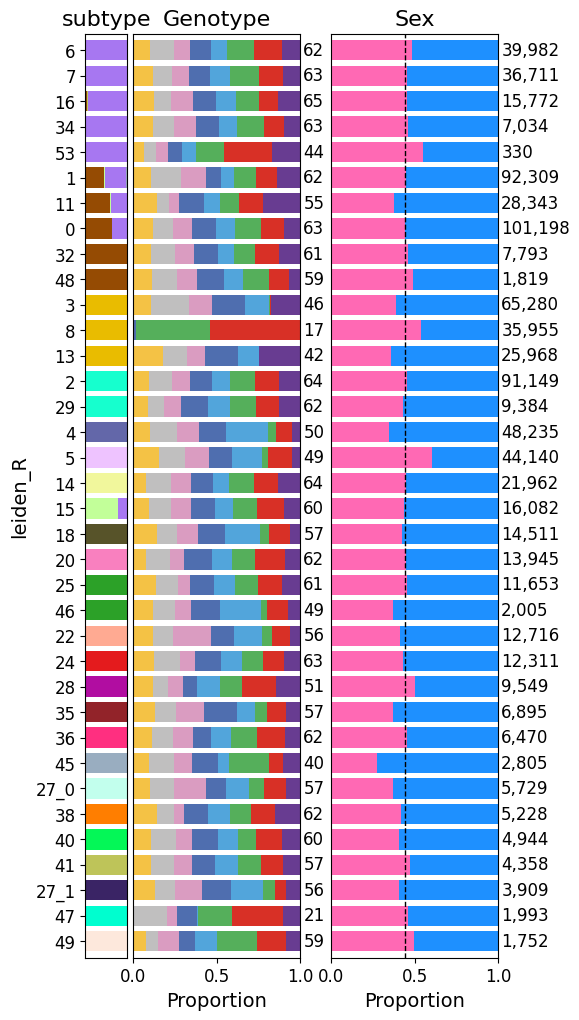

In [455]:
tissue = 'DiencephalonPituitary'
random.seed(333)



metadata = pd.read_csv(f'/share/crsp/lab/seyedam/share/igvf_pipeline/IGVF_analysis/cellbender_tissues/obs_tables/{tissue}_annotated_metadata.csv')
metadata = metadata[metadata['subtype'] != 'low quality']
metadata['leiden_R'] = metadata['leiden_R'].astype(str)

metadata['Genotype'] = pd.Categorical(
    metadata['Genotype'],
    categories=genotype_order,
    ordered=True
)

# === Define palettes ===

# Celltype colors
all_celltypes = metadata['subtype'].unique()
default_palette = sc.pl.palettes.default_102

# Unwanted colors to exclude
excluded_colors = {"#456648", "#549E79", "#6B7900",
                   "#9B9700" ,"#B05B6F","#886F4C",
                  "#7A87A1","#C0B9B2",}

default_palette = [c for c in default_palette if c not in excluded_colors]

remaining_celltypes = [ct for ct in all_celltypes if ct not in custom_colors]
remaining_colors = default_palette[:len(remaining_celltypes)]
random.shuffle(remaining_colors)

remaining_dict = dict(zip(remaining_celltypes, remaining_colors))
celltype_palette = {**custom_colors, **remaining_dict}

# Sex & genotype palettes
sex_palette = {'Male': 'dodgerblue', 'Female': 'hotpink'}
genotype_palette = dict(zip(metadata['Genotype'].unique(), sns.color_palette("tab20", n_colors=10)))

# === Cluster ordering by subtype then size ===

df = metadata[['leiden_R', 'subtype']]
celltype_sizes = df['subtype'].value_counts()
cluster_sizes = df['leiden_R'].value_counts()
cluster_to_celltype = df.set_index('leiden_R')['subtype'].to_dict()

from collections import defaultdict
celltype_to_clusters = defaultdict(list)
for cluster, celltype in cluster_to_celltype.items():
    celltype_to_clusters[celltype].append(cluster)

ordered_clusters = []
for celltype in celltype_sizes.index:
    clusters = celltype_to_clusters[celltype]
    clusters_sorted = sorted(clusters, key=lambda c: -cluster_sizes[c])
    ordered_clusters.extend(clusters_sorted)
ordered_clusters = ordered_clusters[::-1]


ordered_clusters = ['49',
 '47',
 '27_1',
 '41',
 '40',
 '38',
 '27_0',
 '45',
 '36',
 '35',
 '28',
 '24',
 '22',
 '46',
 '25',
 '20',
 '18',
 '15',
 '14',
 '5',
 '4',
 '29',
 '2',
 '13',
 '8',
 '3',
 '48',
 '32',
 '0',
 '11',
 '1',
 '53',
 '34',
 '16',
 '7',
 '6']

# === Filter for meaningful mouse contribution by genotype ===

cell_info = metadata[['leiden_R', 'lab_sample_id', 'Genotype']].copy()

# Cluster-level totals
cluster_totals = cell_info['leiden_R'].value_counts().rename("cluster_total").reset_index()
cluster_totals.columns = ['leiden_R', 'cluster_total']

# Genotype totals per cluster
geno_cluster_totals = (
    cell_info.groupby(['leiden_R', 'Genotype']).size().rename('geno_total').reset_index()
)
geno_cluster_totals = geno_cluster_totals.merge(cluster_totals, on='leiden_R')
geno_cluster_totals['geno_fraction'] = geno_cluster_totals['geno_total'] / geno_cluster_totals['cluster_total']
significant_genotypes = geno_cluster_totals[geno_cluster_totals['geno_fraction'] >= 0.05]

# Mouse contributions
mouse_counts = (
    cell_info.groupby(['leiden_R', 'lab_sample_id']).size().rename('mouse_count').reset_index()
)
lab_sample_to_geno = cell_info.drop_duplicates('lab_sample_id').set_index('lab_sample_id')['Genotype']
mouse_counts['Genotype'] = mouse_counts['lab_sample_id'].map(lab_sample_to_geno)

# Merge and compute proportion
merged = pd.merge(
    mouse_counts,
    significant_genotypes[['leiden_R', 'Genotype', 'geno_total']],
    on=['leiden_R', 'Genotype'],
    how='inner'
)
merged['proportion'] = merged['mouse_count'] / merged['geno_total']
meaningful = merged[merged['proportion'] >= 0.05]

# Final counts
n_mice_per_cluster = (
    meaningful.groupby('leiden_R')['lab_sample_id']
    .nunique().reindex(ordered_clusters).fillna(0).astype(int)
)
n_nuclei_per_cluster = metadata['leiden_R'].value_counts().reindex(ordered_clusters)

# === Plotting ===

fig = plt.figure(figsize=(5, 12))
gs = gridspec.GridSpec(1, 3, width_ratios=[0.5, 2, 2], wspace=0.05)
axs = [fig.add_subplot(gs[i]) for i in range(3)]

# Panel 1: Celltype identity
stacked_barplot_proportions(
    metadata,
    cluster_key="leiden_R",
    var_key="subtype",
    color_dict=celltype_palette,
    cluster_order=ordered_clusters,
    annotations=False,
    fsize=None,
    ax=axs[0]
)

# Panel 2: Genotype proportions with # mice
stacked_barplot_proportions(
    metadata,
    cluster_key="leiden_R",
    var_key="Genotype",
    color_dict=geno_palette,
    cluster_order=ordered_clusters,
    annotations=True,
    annotate_vals=n_mice_per_cluster,
    fsize=None,
    ax=axs[1]
)

# Panel 3: Sex proportions with # nuclei
stacked_barplot_proportions(
    metadata,
    cluster_key="leiden_R",
    var_key="Sex",
    color_dict=sex_palette,
    cluster_order=ordered_clusters,
    annotations=True,
    annotate_vals=n_nuclei_per_cluster,
    fsize=None,
    ax=axs[2]
)

# === Final formatting ===

axs[0].set_xlabel("")
axs[2].set_position([
    axs[2].get_position().x0 + 0.05,
    axs[2].get_position().y0,
    axs[2].get_position().width,
    axs[2].get_position().height
])
axs[0].tick_params(axis='x', bottom=False, labelbottom=False)
axs[1].tick_params(axis='y', length=0)
axs[2].tick_params(axis='y', length=0)
axs[1].set_yticklabels([])
axs[2].set_yticklabels([])
axs[1].set_ylabel("")
axs[2].set_ylabel("")

for ax in axs:
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

female_fraction = (metadata['Sex'] == 'Female').mean()
axs[2].axvline(female_fraction, linestyle='--', color='black', linewidth=1)

plt.tight_layout()
plt.savefig(f"../new_supp/{tissue}_cluster_annotations_barplots.png", dpi=300, bbox_inches='tight', transparent = True)
plt.show()


## Legends

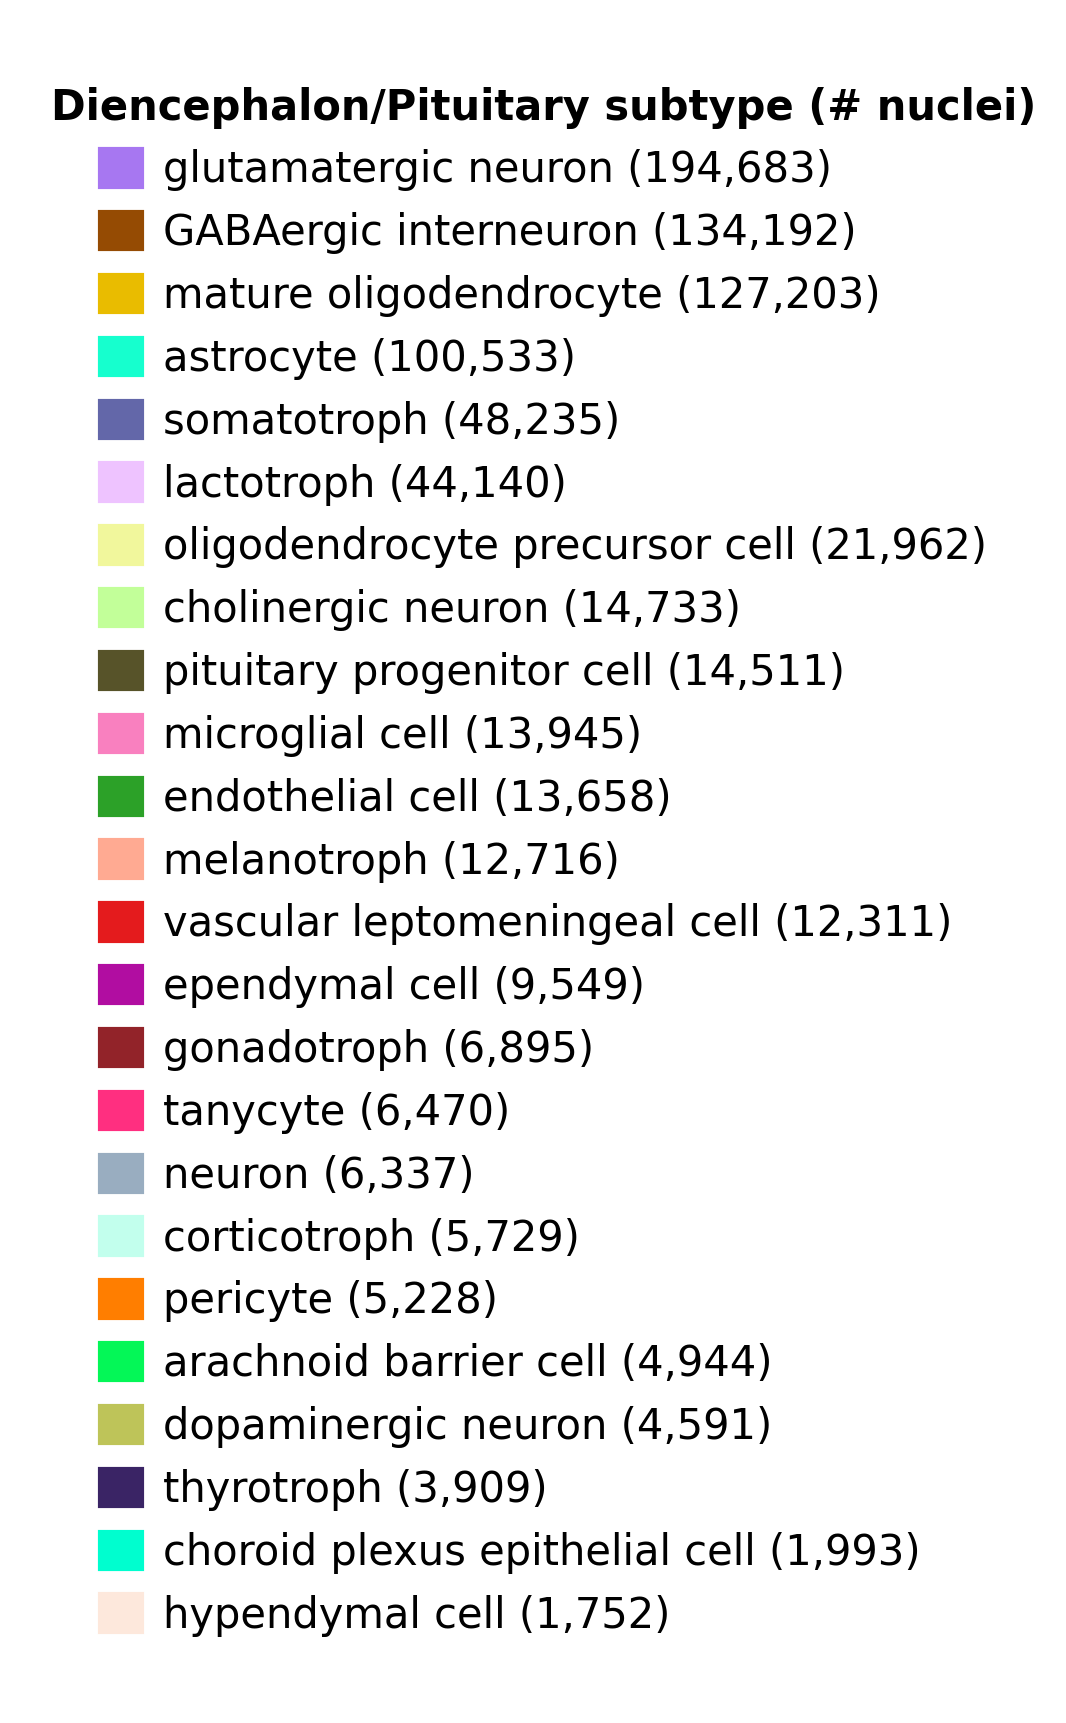

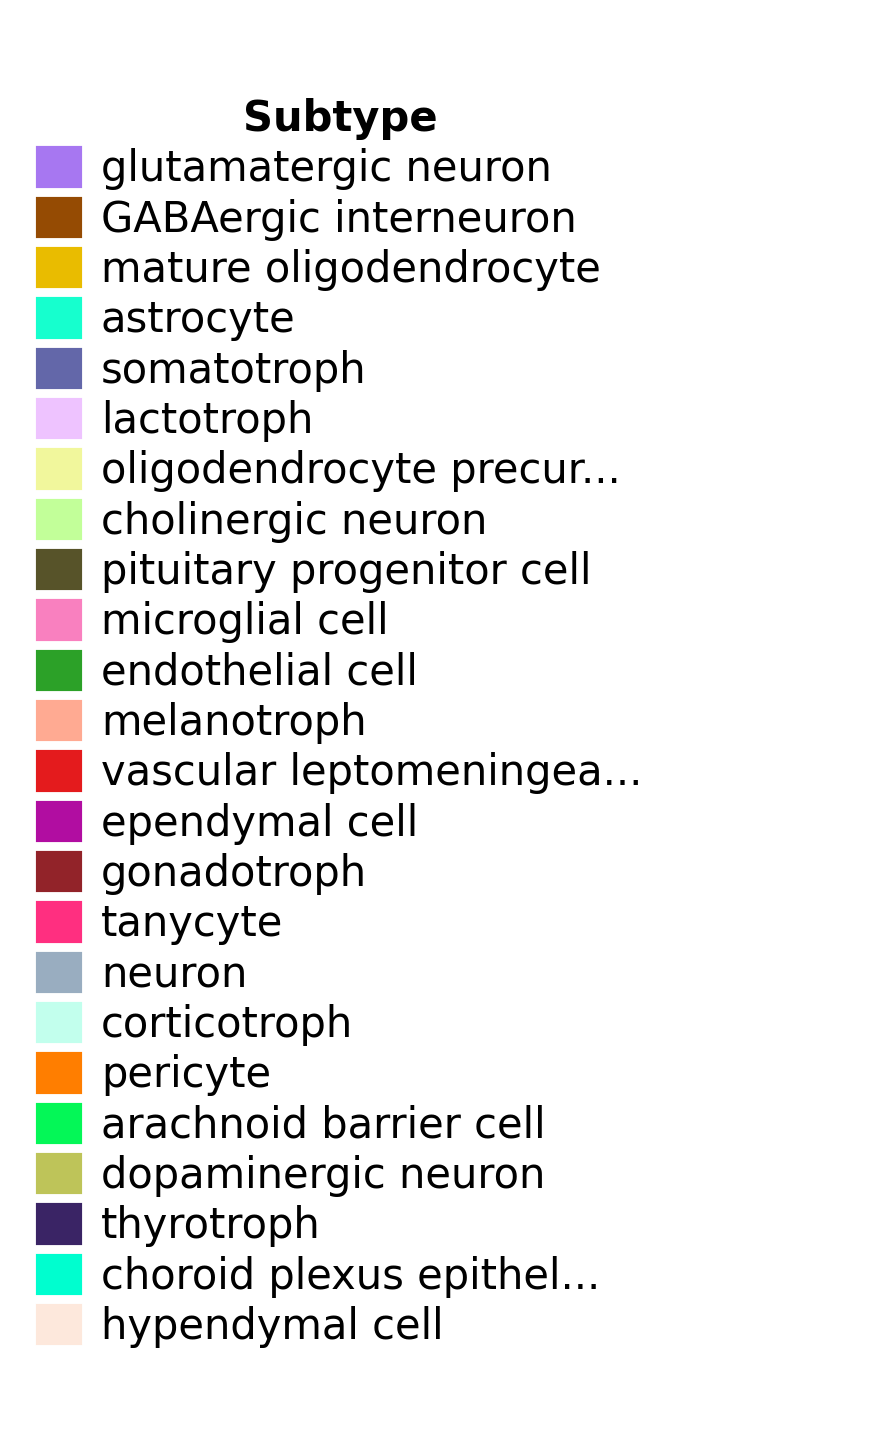

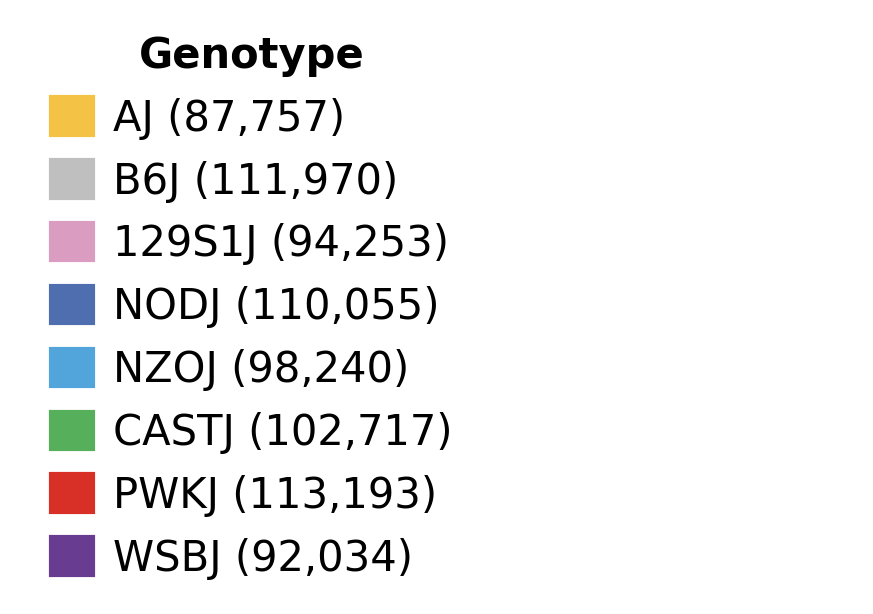

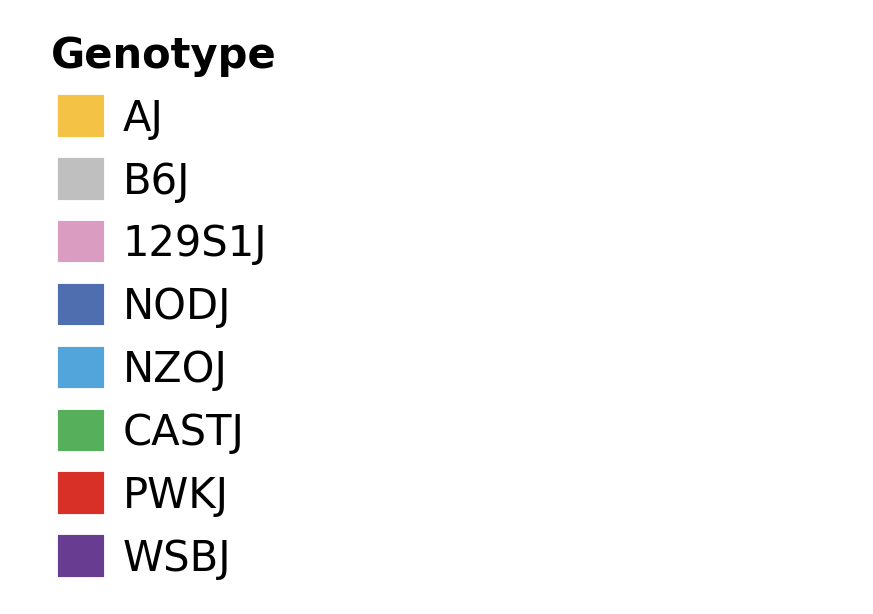

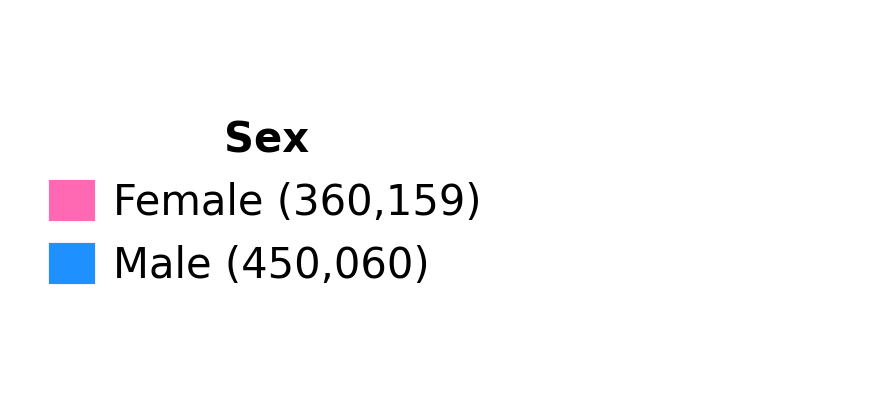

In [467]:
ordered_celltypes = metadata.set_index('leiden_R').loc[ordered_clusters]['subtype'].values
ordered_celltypes = list(dict.fromkeys(ordered_celltypes))  # remove duplicates, keep order
ordered_celltypes = ordered_celltypes[::-1]  # reverse it

ordered_celltypes = [
    'glutamatergic neuron',
    'GABAergic interneuron',
    'mature oligodendrocyte',
    'astrocyte',
    'somatotroph',
    'lactotroph',
    'oligodendrocyte precursor cell',
    'cholinergic neuron',
    'pituitary progenitor cell',
    'microglial cell',
    'endothelial cell',
    'melanotroph',
    'vascular leptomeningeal cell',
    'ependymal cell',
    'gonadotroph',
    'tanycyte',
    'neuron',
    'corticotroph',
    'pericyte',
    'arachnoid barrier cell',
    'dopaminergic neuron',
    'thyrotroph',
    'choroid plexus epithelial cell',
    'hypendymal cell'
]

from collections import Counter
celltype_counts = metadata['subtype'].value_counts()

tissue_label_map = {
    "CortexHippocampus": "Cortex/Hippocampus",
    "DiencephalonPituitary": "Diencephalon/Pituitary",
    "GonadsMale": "Male gonads",
    "GonadsFemale": "Female gonads"
}

# Fallback to original if not in map
pretty_tissue = tissue_label_map.get(tissue, tissue)


label = f"{pretty_tissue} subtype (# nuclei)"
fname = f"{tissue}_celltype_legend"

create_standalone_legend(
    color_dict=celltype_palette,
    label=label,
    order=ordered_celltypes,
    counts=celltype_counts,
    ncol=1,
    fname = fname
)


metadata["subtype_abbrev"] = metadata["subtype"].apply(abbreviate)

ordered_celltype_abbrev = [abbreviate(ct) for ct in ordered_celltypes]

celltype_counts = metadata['subtype_abbrev'].value_counts()

label = f"Subtype"
fname = f"{tissue}_simple_celltype_legend"

celltype_palette_abbrev = {
    abbreviate(ct): color for ct, color in celltype_palette.items()
    if abbreviate(ct) in set(ordered_celltype_abbrev)
}

create_standalone_legend_squish(
    color_dict=celltype_palette_abbrev,
    label=label,
    order=ordered_celltype_abbrev,
    ncol=1,
    fname = fname
)


geno_counts = metadata['Genotype'].value_counts()

label = f"Genotype"
fname = f"{tissue}_geno_legend"

create_standalone_legend(
    color_dict=geno_palette,
    label=label,
    order=genotype_order,
    counts=geno_counts,
    ncol=1,
    fname = fname
)


geno_counts = metadata['Genotype'].value_counts()

label = f"Genotype"
fname = f"{tissue}_simple_geno_legend"

create_standalone_legend(
    color_dict=geno_palette,
    label=label,
    order=genotype_order,
    ncol=1,
    fname = fname
)


sex_counts = metadata['Sex'].value_counts()

label = f"Sex"
fname = f"{tissue}_sex_legend"

create_standalone_legend(
    color_dict=sex_palette,
    label=label,
    order=['Female', 'Male'],
    counts=sex_counts,
    ncol=1,
    fname = fname
)

In [468]:
metadata.shape

(810219, 57)

## Proportion of genotypes across celltypes

/tmp/ipykernel_1504450/257901544.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = obs.groupby([cluster_key, var_key]).size().unstack(fill_value=0)


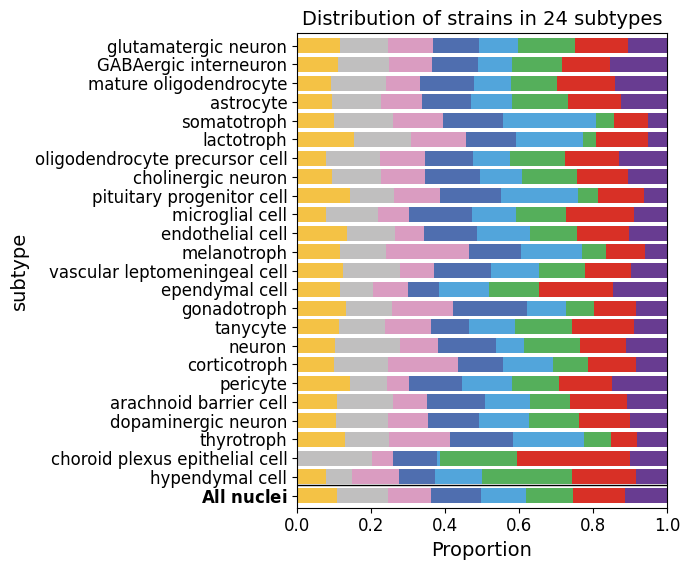

In [469]:
# Copy metadata and append summary row
plot_df = metadata.copy()

# Create a dummy celltype entry for all cells combined
summary_row = plot_df.copy()
summary_row['subtype'] = 'All nuclei'

# Append to the bottom of the dataframe
plot_df = pd.concat([plot_df, summary_row], axis=0)

# Add 'All cells' to the cluster order list (at the end)
ordered_celltypes2 =  ['All nuclei'] + ordered_celltypes[::-1] 

# Now plot!
fig = plt.figure(figsize=(7, 5.8))  # slightly taller
gs = gridspec.GridSpec(1, 1)
ax = fig.add_subplot(gs[0])

stacked_barplot_proportions(
    plot_df,
    cluster_key="subtype",
    var_key="Genotype",
    color_dict=geno_palette,
    cluster_order=ordered_celltypes2,
    annotations=False,
    fsize=None,
    ax=ax
)

ax.axhline(y=0.54, color='black', linestyle='-', linewidth=1)

# Get current y-axis tick labels
yticklabels = [label.get_text() for label in ax.get_yticklabels()]

# Rebuild the list with "All cells" in bold
new_labels = []
for label in yticklabels:
    if label == 'All nuclei':
        new_labels.append(r"$\bf{All\ nuclei}$")  # bold with math text
    else:
        new_labels.append(label)

# Apply new labels
ax.set_yticklabels(new_labels)

n_celltypes = len(ordered_celltypes)
ax.set_title(f"Distribution of strains in {n_celltypes} subtypes", fontsize=14)


plt.tight_layout()

plt.savefig(f"../new_supp/{tissue}_genotype_distribution_across_celltypes_bar.png", dpi=300, bbox_inches='tight', transparent = True)

plt.show()


## Proportion of celltypes across genotypes

/tmp/ipykernel_1504450/257901544.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = obs.groupby([cluster_key, var_key]).size().unstack(fill_value=0)


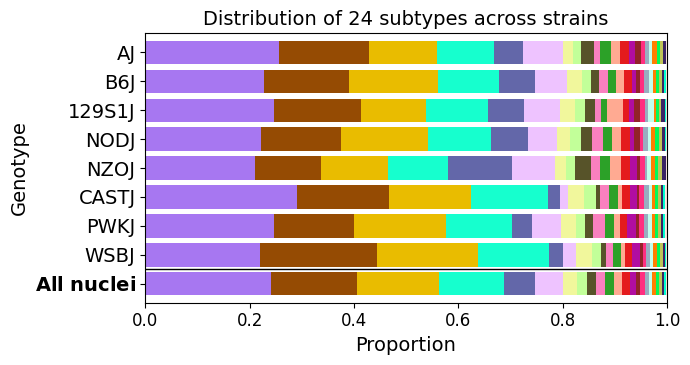

In [470]:
# Copy metadata and append summary row
plot_df = metadata.copy()

# Create a dummy genotype entry for all cells combined
summary_row = plot_df.copy()
summary_row['Genotype'] = 'All nuclei'

# Append to the bottom of the dataframe
plot_df = pd.concat([plot_df, summary_row], axis=0)

# Subtype category setup
plot_df['subtype'] = pd.Categorical(
    plot_df['subtype'],
    categories=ordered_celltypes,
    ordered=True
)

# Genotype category setup, include 'All nuclei' at the end
genotype_order = ["AJ", "B6J", "129S1J", "NODJ", "NZOJ", "CASTJ", "PWKJ", "WSBJ"]
genotype_order_reversed = ['All nuclei'] + genotype_order[::-1]

plot_df['Genotype'] = pd.Categorical(
    plot_df['Genotype'],
    categories=genotype_order_reversed,
    ordered=True
)

# Plot
fig = plt.figure(figsize=(7, 3.75))  # slightly taller
gs = gridspec.GridSpec(1, 1)
ax = fig.add_subplot(gs[0])

stacked_barplot_proportions(
    plot_df,
    cluster_key="Genotype",
    var_key="subtype",
    color_dict=celltype_palette,
    cluster_order=genotype_order_reversed,
    annotations=False,
    fsize=None,
    ax=ax
)

ax.tick_params(axis='y', labelsize=14)

ax.axhline(y=0.52, color='black', linestyle='-', linewidth=1)

# Get current y-axis tick labels
yticklabels = [label.get_text() for label in ax.get_yticklabels()]

# Rebuild the list with "All cells" in bold
new_labels = []
for label in yticklabels:
    if label == 'All nuclei':
        new_labels.append(r"$\bf{All\ nuclei}$")  # bold with math text
    else:
        new_labels.append(label)

# Apply new labels
ax.set_yticklabels(new_labels)


ax.set_title(f"Distribution of {len(ordered_celltypes)} subtypes across strains", fontsize=14)

plt.tight_layout()
plt.savefig(f"../new_supp/{tissue}_celltype_distribution_across_genotypes_bar.png", dpi=300, bbox_inches='tight', transparent = True)
plt.show()


# Marker gene dotplots

Using python script new_marker_dotplot.py to make dotplot figure (read in full object in highmem session..)

E.g. `python new_marker_dotplot.py CortexHippocampus`